# Librairies à utiliser

In [3]:
library(ggplot2)
library(tidyverse)
library(gridExtra)
library(GGally)
library(plotly)
library(corrplot)
library(reshape2)
library(FactoMineR) 
library(factoextra)
library(glmnet) 
library(ggfortify)
library(pROC)
library(ROCR)
library(dplyr)
options(warn = -1)

# 1. Récupération du jeu de données

In [4]:
data<-read.csv("healthcare_synthetic_data.csv")
summary(data)
head(data)

  Patient_ID             Age            Gender         Height_cm    
 Length:15000       Min.   :25.00   Min.   :0.0000   Min.   :138.5  
 Class :character   1st Qu.:46.00   1st Qu.:0.0000   1st Qu.:158.5  
 Mode  :character   Median :55.00   Median :0.0000   Median :164.7  
                    Mean   :54.54   Mean   :0.4919   Mean   :165.3  
                    3rd Qu.:63.00   3rd Qu.:1.0000   3rd Qu.:172.0  
                    Max.   :85.00   Max.   :1.0000   Max.   :198.1  
   Weight_kg           BMI         Systolic_BP     Diastolic_BP   
 Min.   : 33.70   Min.   :14.50   Min.   : 90.0   Min.   : 60.00  
 1st Qu.: 65.20   1st Qu.:24.50   1st Qu.:127.0   1st Qu.: 85.00  
 Median : 73.90   Median :27.20   Median :135.0   Median : 91.00  
 Mean   : 75.25   Mean   :27.45   Mean   :135.1   Mean   : 90.54  
 3rd Qu.: 83.90   3rd Qu.:30.00   3rd Qu.:143.0   3rd Qu.: 96.00  
 Max.   :150.10   Max.   :46.10   Max.   :182.0   Max.   :120.00  
 Cholesterol_Total Cholesterol_LDL Cholesterol_H

,Patient_ID,Age,Gender,Height_cm,Weight_kg,BMI,Systolic_BP,Diastolic_BP,Cholesterol_Total,Cholesterol_LDL,Cholesterol_HDL,Fasting_Blood_Sugar,Smoking_Status,Alcohol_Consumption,Physical_Activity_Level,Family_History,Stress_Level,Sleep_Hours,Heart_Disease_Risk
,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,PID-00001,60,0,146.9,51.3,23.8,140,89,217,151,52,83,0,1,3,0,1,8,0
2,PID-00002,53,0,161.8,76.6,29.3,128,81,203,119,38,116,0,0,1,0,7,9,0
3,PID-00003,62,1,174.7,92.4,30.3,141,100,173,124,45,90,0,0,0,0,1,7,1
4,PID-00004,73,1,173.3,68.9,22.9,136,96,193,117,45,81,0,0,1,0,2,7,1
5,PID-00005,52,1,178.6,79.8,25.0,122,80,236,153,41,79,0,1,2,0,2,6,0
6,PID-00006,52,0,159.6,60.3,23.7,134,92,225,155,48,103,0,0,1,1,4,8,0


Nous avons décidé de supprimer la variable Patient_ID car étant unique pour chaque patient, elle ne donne pas d'information exploitable.

Nous convertissons les variables qualitatives en "facteurs" ('Gender','Smoking_Status', 'Family_History', 'Alcohol_Consumption', 'Physical_Activity_Level','Heart_Disease_Risk').

Nous choisissons aussi de traiter 'Stress_Level' et 'Sleep_Hours' comme des variables qualitatives au vu de leur petit nombre de valeurs distinctes.

In [5]:
paste("Le nombre de valeurs distinctes que prend la variable Stress_Level est :",n_distinct(data[,"Stress_Level"]))
paste("Le nombre de valeurs distinctes que prend la variable Sleep_Hours est :",n_distinct(data[,"Sleep_Hours"]))

[1] "Le nombre de valeurs distinctes que prend la variable Stress_Level est : 10"

[1] "Le nombre de valeurs distinctes que prend la variable Sleep_Hours est : 7"

In [6]:
# Suppression de la variable Patient_ID
data=data %>% select(-Patient_ID)

data[, "Gender"] <- as.factor(data[, "Gender"])
data$Gender <- factor(data$Gender, 
                      levels = c(0, 1), 
                      labels = c("Female", "Male"))
data[,"Smoking_Status"]= as.factor(data[,"Smoking_Status"])
data[, "Family_History"] <- as.factor(data[, "Family_History"])
data[, "Alcohol_Consumption"] <- as.factor(data[, "Alcohol_Consumption"])
data[, "Physical_Activity_Level"] <- as.factor(data[, "Physical_Activity_Level"])
data[,"Stress_Level"]= as.factor(data[,"Stress_Level"])
data[, "Heart_Disease_Risk"] <- as.factor(data[, "Heart_Disease_Risk"])
data[,"Sleep_Hours"]= as.factor(data[,"Sleep_Hours"])
summary(data)

      Age           Gender       Height_cm       Weight_kg           BMI       
 Min.   :25.00   Female:7622   Min.   :138.5   Min.   : 33.70   Min.   :14.50  
 1st Qu.:46.00   Male  :7378   1st Qu.:158.5   1st Qu.: 65.20   1st Qu.:24.50  
 Median :55.00                 Median :164.7   Median : 73.90   Median :27.20  
 Mean   :54.54                 Mean   :165.3   Mean   : 75.25   Mean   :27.45  
 3rd Qu.:63.00                 3rd Qu.:172.0   3rd Qu.: 83.90   3rd Qu.:30.00  
 Max.   :85.00                 Max.   :198.1   Max.   :150.10   Max.   :46.10  
                                                                               
  Systolic_BP     Diastolic_BP    Cholesterol_Total Cholesterol_LDL
 Min.   : 90.0   Min.   : 60.00   Min.   :127.0     Min.   : 70.0  
 1st Qu.:127.0   1st Qu.: 85.00   1st Qu.:201.0     1st Qu.:128.0  
 Median :135.0   Median : 91.00   Median :216.0     Median :140.0  
 Mean   :135.1   Mean   : 90.54   Mean   :216.2     Mean   :140.4  
 3rd Qu.:143.0   3rd

Au final :

Les variables **quantitatives** sont : Age, Height_cm, Weight_kg, BMI, Systolic_BP, Diastolic_BP, Cholesterol_Total, Cholesterol_LDL, Cholesterol_HDL, Fasting_Blood_Sugar.


Les variables **qualitatives** sont : Gender, Smoking_Status, Alcohol_Consumption, Physical_Activity_Level, Heart_Disease_Risk, Family_History, Stress_Level, Sleep_Hours.

# 2. Analyse exploratoire des données

## 2.1 Analyse unidimentionnelle

### Variables quantitatives

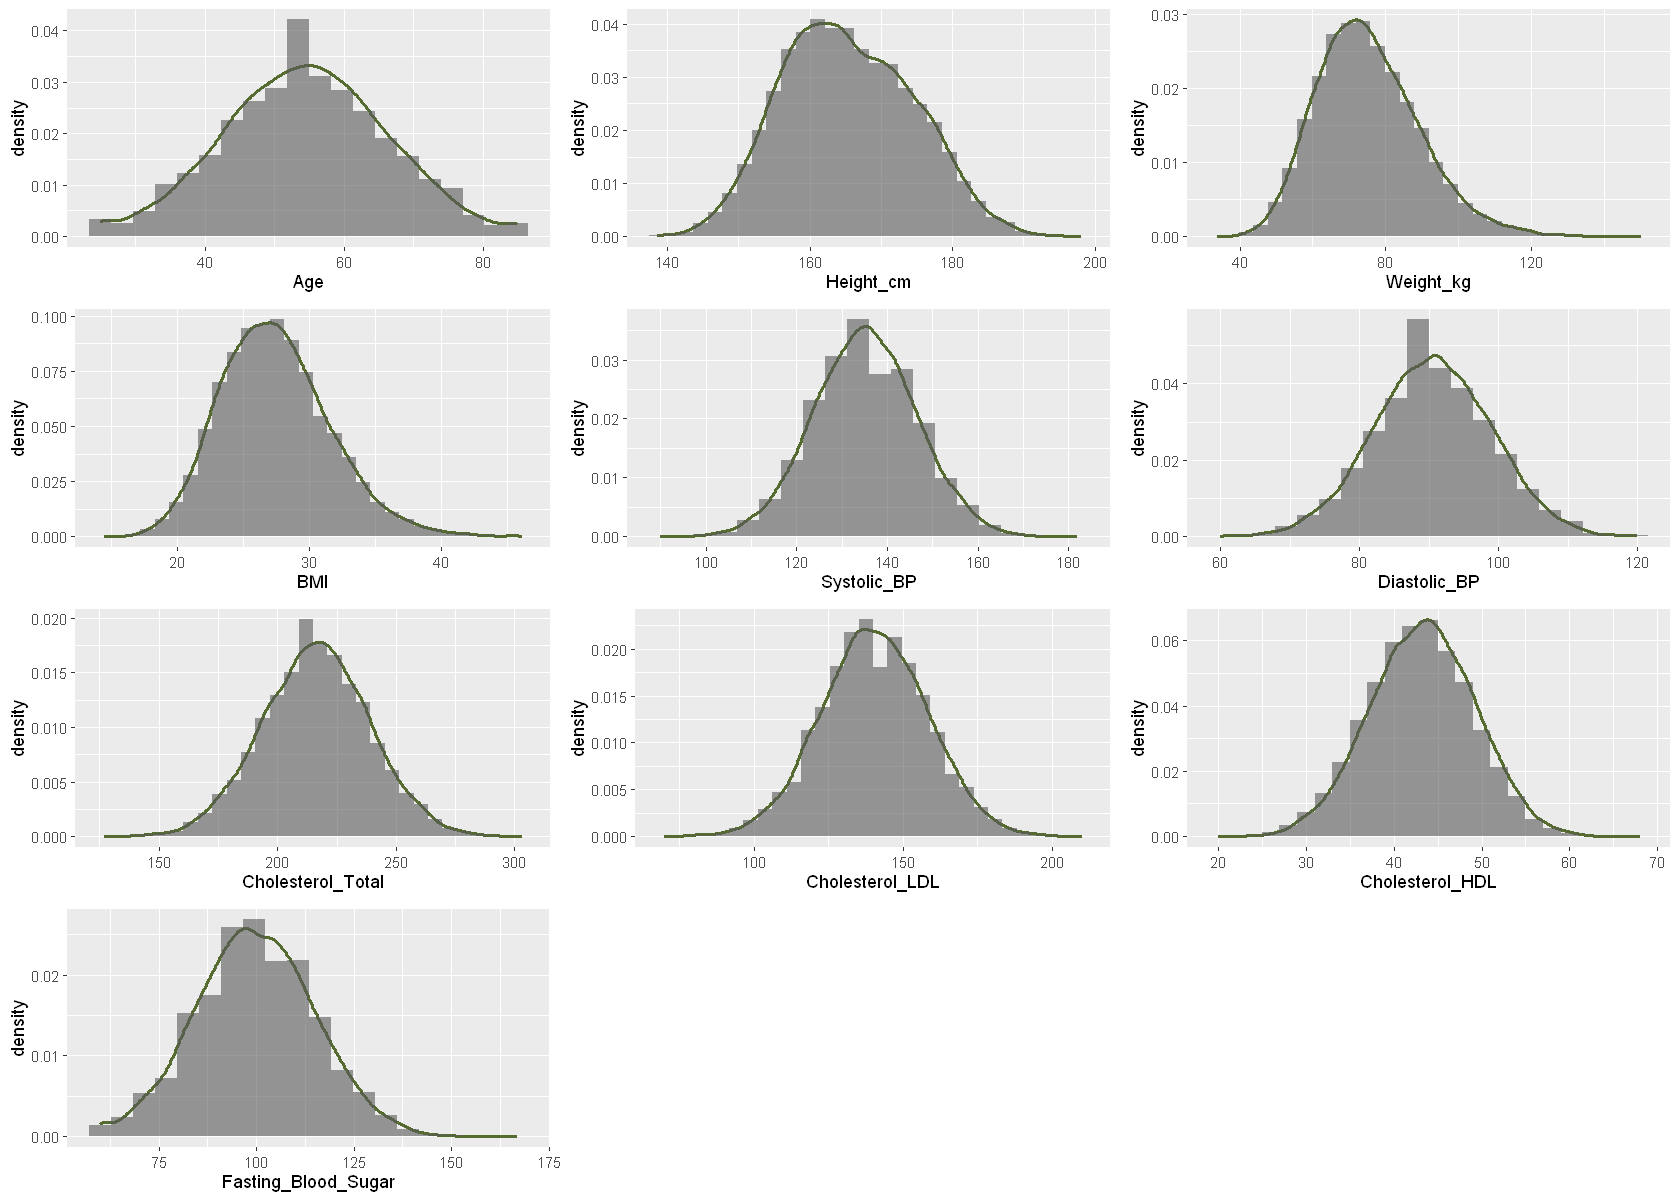

In [7]:
# Etude densité des variables quantitatives
g1=ggplot(data,aes(x=Age)) + geom_density(linewidth=1,col="darkolivegreen") + geom_histogram(alpha=0.6,aes(y=after_stat(density)),bins=20)
g2=ggplot(data,aes(x=Height_cm)) + geom_density(linewidth=1,col="darkolivegreen") + geom_histogram(alpha=0.6,aes(y=after_stat(density)),bins=30)
g3=ggplot(data,aes(x=Weight_kg)) + geom_density(linewidth=1,col="darkolivegreen") + geom_histogram(alpha=0.6,aes(y=after_stat(density)),bins=30)
g4=ggplot(data,aes(x=BMI)) + geom_density(linewidth=1,col="darkolivegreen") + geom_histogram(alpha=0.6,aes(y=after_stat(density)),bins=30)
g5=ggplot(data,aes(x=Systolic_BP)) + geom_density(linewidth=1,col="darkolivegreen") + geom_histogram(alpha=0.6,aes(y=after_stat(density)),bins=20)
g6=ggplot(data,aes(x=Diastolic_BP)) + geom_density(linewidth=1,col="darkolivegreen") + geom_histogram(alpha=0.6,aes(y=after_stat(density)),bins=20)
g7=ggplot(data,aes(x=Cholesterol_Total)) + geom_density(linewidth=1,col="darkolivegreen") + geom_histogram(alpha=0.6,aes(y=after_stat(density)),bins=30)
g8=ggplot(data,aes(x=Cholesterol_LDL)) + geom_density(linewidth=1,col="darkolivegreen") + geom_histogram(alpha=0.6,aes(y=after_stat(density)),bins=30)
g9=ggplot(data,aes(x=Cholesterol_HDL)) + geom_density(linewidth=1,col="darkolivegreen") + geom_histogram(alpha=0.6,aes(y=after_stat(density)),bins=25)
g10=ggplot(data,aes(x=Fasting_Blood_Sugar)) + geom_density(linewidth=1,col="darkolivegreen") + geom_histogram(alpha=0.6,aes(y=after_stat(density)),bins=20)

options(repr.plot.width = 14, repr.plot.height = 10)
grid.arrange(g1,g2,g3,g4,g5,g6,g7,g8,g9,g10,ncol=3)

Fasting_Blood_Sugar, Height_cm et BMI semblent légèrement asymétriques à droite, on leur a donc appliquer une racine carré pour les rendre plus symétriques. On a aussi choisi de modifier Height_cm en lui appliquant un logarithme.

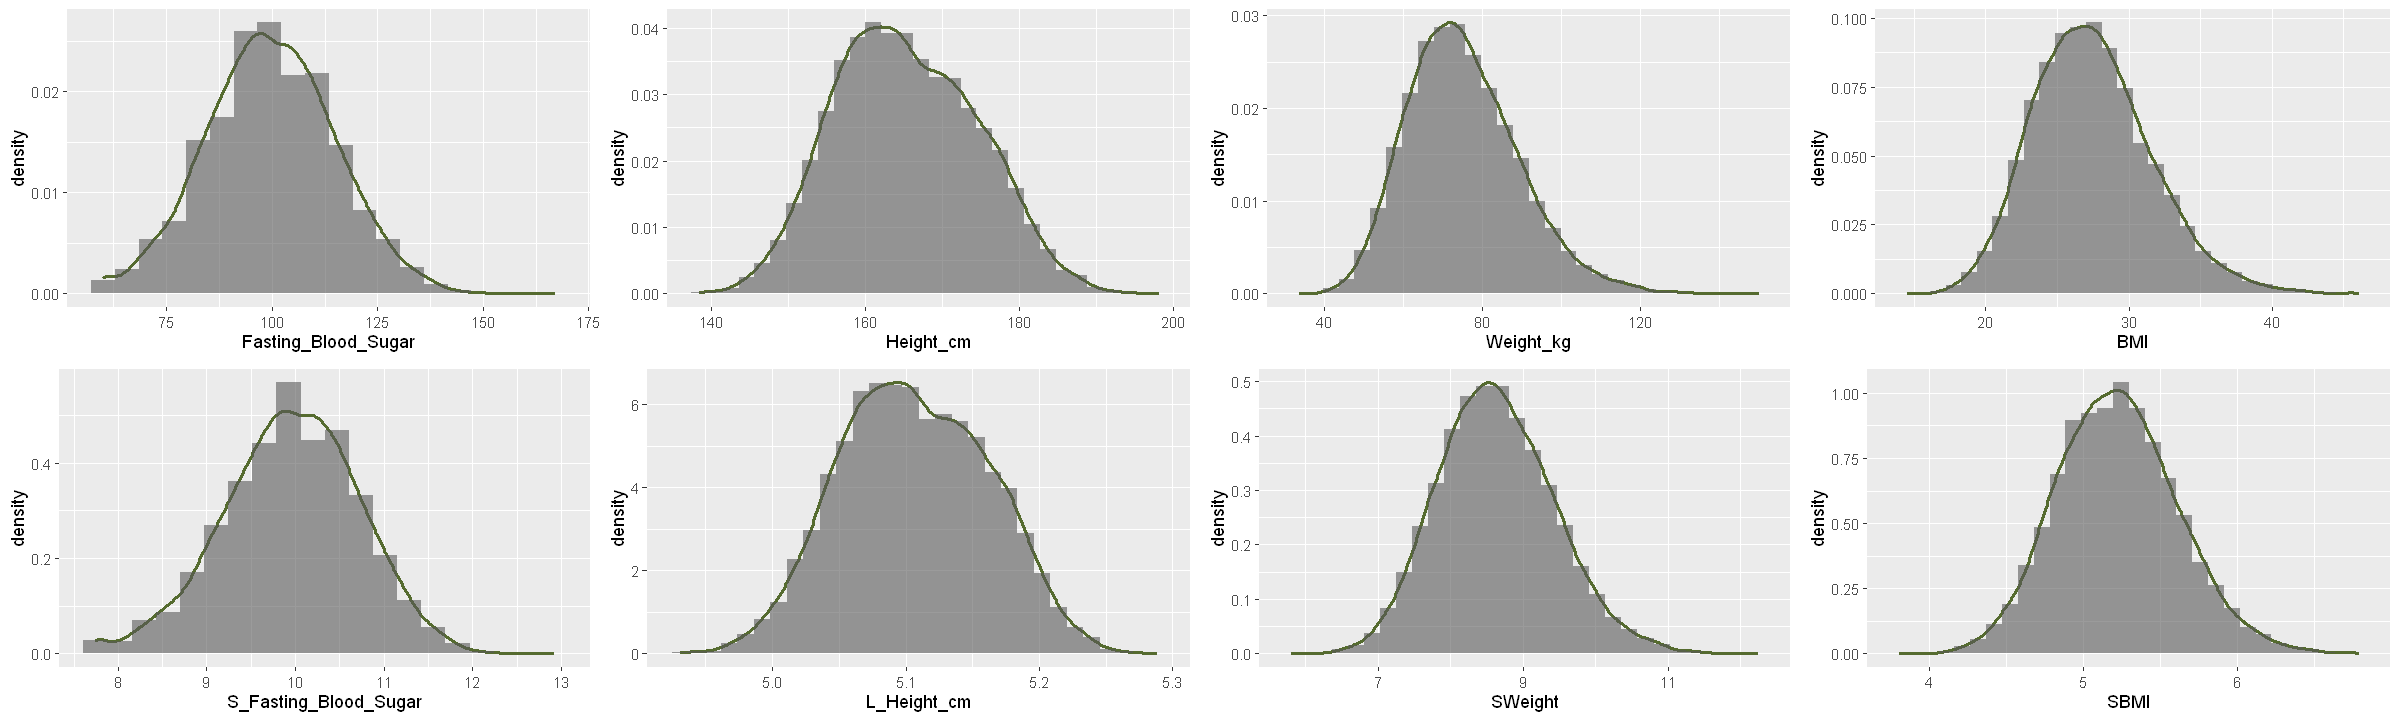

In [8]:
options(repr.plot.width = 20, repr.plot.height = 6)
data[,"SBMI"] = sqrt(data[,"BMI"])
data[,"SWeight"] = sqrt(data[,"Weight_kg"])
data[, "S_Fasting_Blood_Sugar"] = sqrt(data[, "Fasting_Blood_Sugar"])
data[, "L_Height_cm"] = log(data[, "Height_cm"])

sg1=ggplot(data,aes(x=S_Fasting_Blood_Sugar))+geom_density(linewidth=1,col="darkolivegreen") + geom_histogram(alpha=0.6,aes(y=after_stat(density)),bins=20)
sg2=ggplot(data,aes(x=L_Height_cm))+geom_density(linewidth=1,col="darkolivegreen") + geom_histogram(alpha=0.6,aes(y=after_stat(density)),bins=30)
sg4=ggplot(data,aes(x=SBMI)) + geom_density(linewidth=1,col="darkolivegreen") + geom_histogram(alpha=0.6,aes(y=after_stat(density)),bins=30)
sg3=ggplot(data,aes(x=SWeight)) + geom_density(linewidth=1,col="darkolivegreen") + geom_histogram(alpha=0.6,aes(y=after_stat(density)),bins=30)
grid.arrange(g10,g2,g3,g4,sg1,sg2,sg3,sg4,ncol=4)

In [9]:
#On ne garde que les variables transformées
data=data %>% select(-c(Fasting_Blood_Sugar,Height_cm,Weight_kg,BMI))
summary(data)

      Age           Gender      Systolic_BP     Diastolic_BP   
 Min.   :25.00   Female:7622   Min.   : 90.0   Min.   : 60.00  
 1st Qu.:46.00   Male  :7378   1st Qu.:127.0   1st Qu.: 85.00  
 Median :55.00                 Median :135.0   Median : 91.00  
 Mean   :54.54                 Mean   :135.1   Mean   : 90.54  
 3rd Qu.:63.00                 3rd Qu.:143.0   3rd Qu.: 96.00  
 Max.   :85.00                 Max.   :182.0   Max.   :120.00  
                                                               
 Cholesterol_Total Cholesterol_LDL Cholesterol_HDL Smoking_Status
 Min.   :127.0     Min.   : 70.0   Min.   :20.00   0:10495       
 1st Qu.:201.0     1st Qu.:128.0   1st Qu.:39.00   1: 4505       
 Median :216.0     Median :140.0   Median :43.00                 
 Mean   :216.2     Mean   :140.4   Mean   :43.31                 
 3rd Qu.:231.0     3rd Qu.:152.0   3rd Qu.:47.00                 
 Max.   :303.0     Max.   :210.0   Max.   :68.00                 
                          

### Variables qualitatives

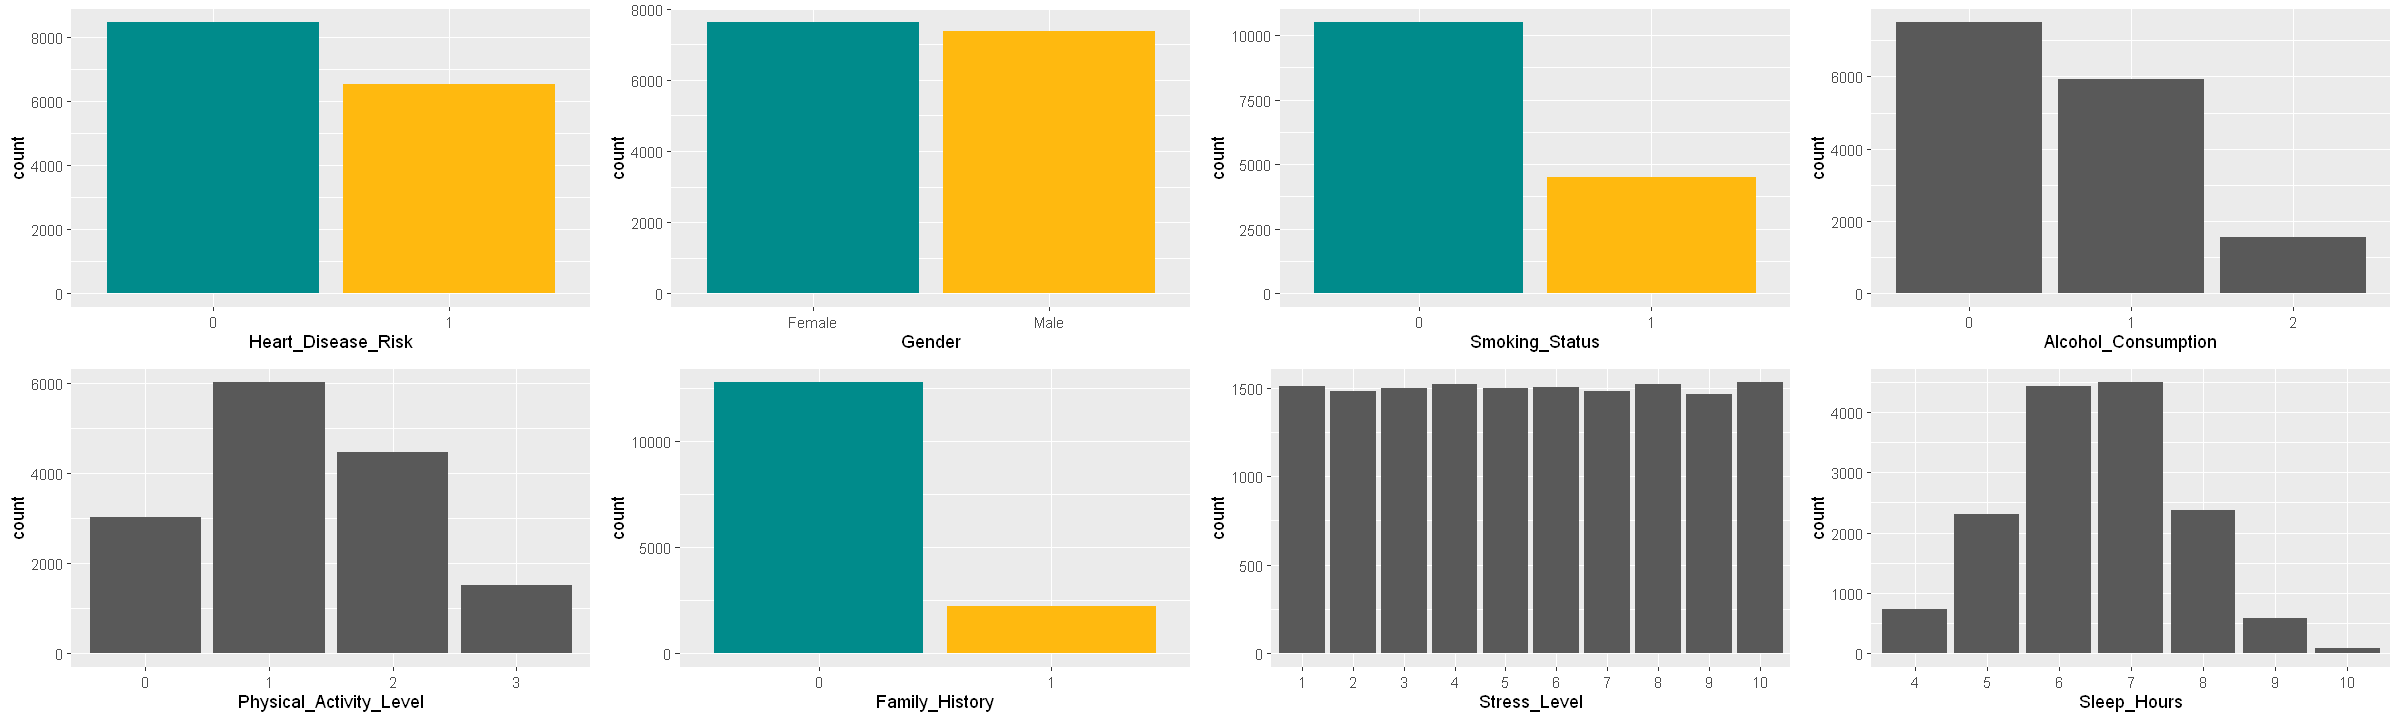

In [10]:
# Affichage des fréquences des modalités
colors=c("darkcyan","darkgoldenrod1")
p1=ggplot(data,aes(x=Heart_Disease_Risk))+geom_bar(fill=colors)
p2=ggplot(data,aes(x=Gender))+geom_bar(fill=colors)
p3=ggplot(data,aes(x=Smoking_Status))+geom_bar(fill=colors)
p4=ggplot(data,aes(x=Alcohol_Consumption))+geom_bar()
p5=ggplot(data,aes(x=Physical_Activity_Level))+geom_bar()
p6=ggplot(data,aes(x=Family_History))+geom_bar(fill=colors)
p7=ggplot(data,aes(x=Stress_Level))+geom_bar()
p8=ggplot(data,aes(x=Sleep_Hours))+geom_bar()
grid.arrange(p1,p2,p3,p4,p5,p6,p7,p8,ncol=4)

Toutes les modalités ont l'air d'être bien représentées et l'échantillon intérrogé semple représentatif de la population; 

## 2.2 Analyse bidimensionnelle

### Corrélation entre variables quantitatives

In [11]:
options(repr.plot.width = 14, repr.plot.height = 7)

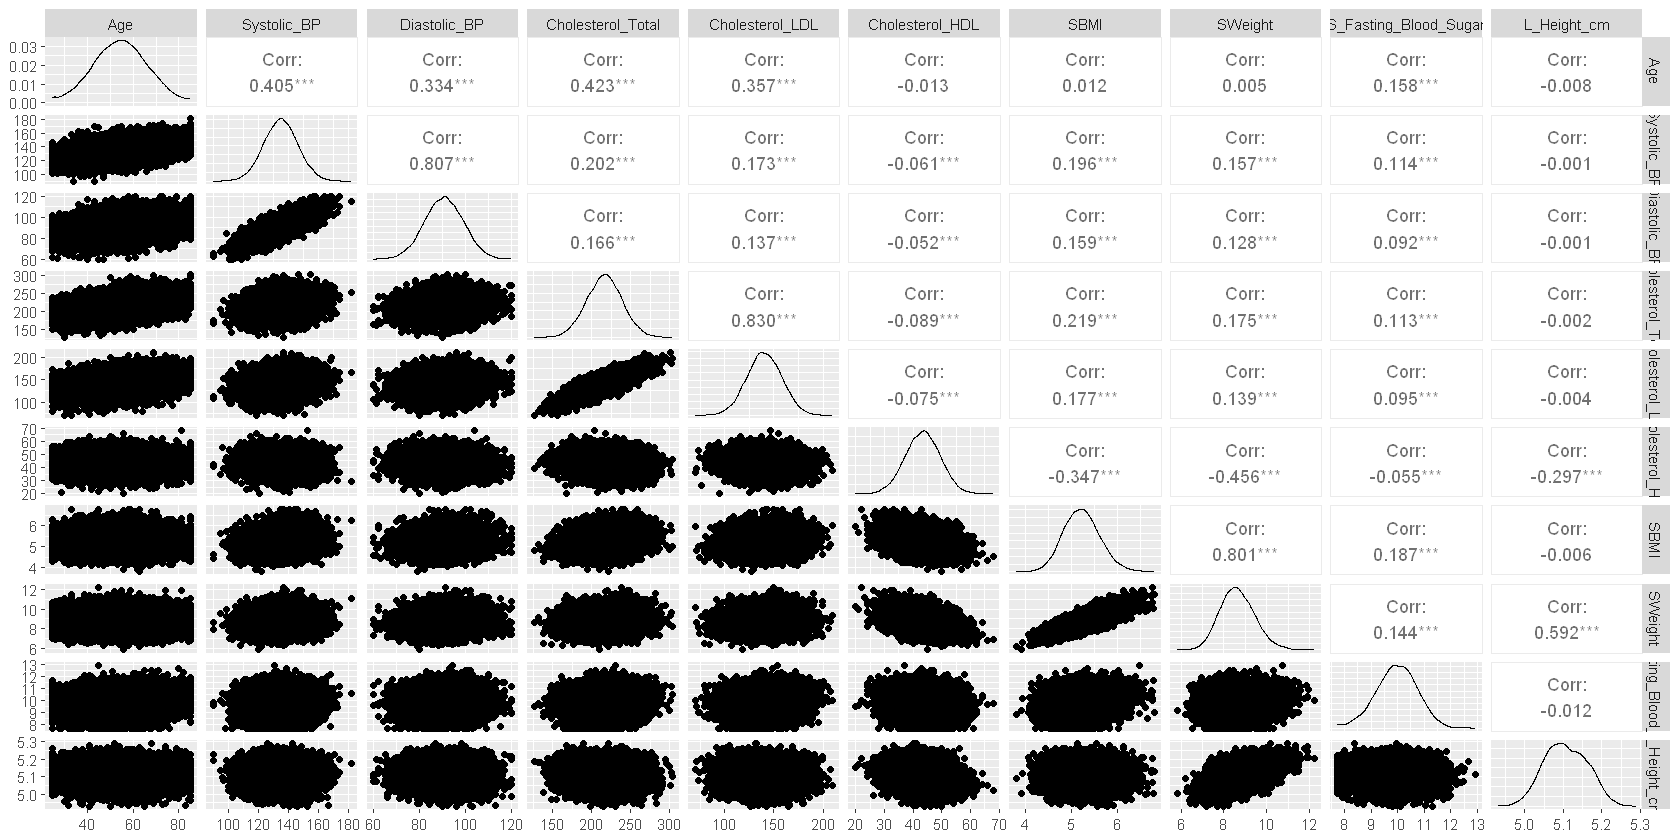

In [12]:
data_quanti = data %>% select(where(is.numeric))
ggpairs(data_quanti)

On remarque 3 paires de variables très corrélées positivement (avec des valeurs de correlation autour de 0.8): le **poids du patient** avec **l'IMC**, la **pression artérielle systolique** (Systotic_BP) avec la **pression artérielle diastolique** (Diastotic_BP) et le taux de **cholesterol total** avec le taux de **cholesterol LDL**. On note aussi que la variable **Height** est corrélé positivement avec **SWeight** (presque 0.6).

Cela semble logique car le calcul de l'IMC dépend du poids, les variables Diastotic_BP et Systotic_BP mesurent toutes les deux la pression artérielle et enfin le cholesterol LDL fait partie du cholesterol total. Cependant on remarque que le taux de cholesterol total soit très corrélé avec le taux de cholesterol LDL ("mauvais") mais pas avec le HDL ("bon") (correlation de 0.830 contre -0.089). Les deux types de cholesterol ne semblent pas non plus corrélées entre eux. On suppose donc que le mauvais cholesterol est présent en majorité dans le taux de chomesterol total.

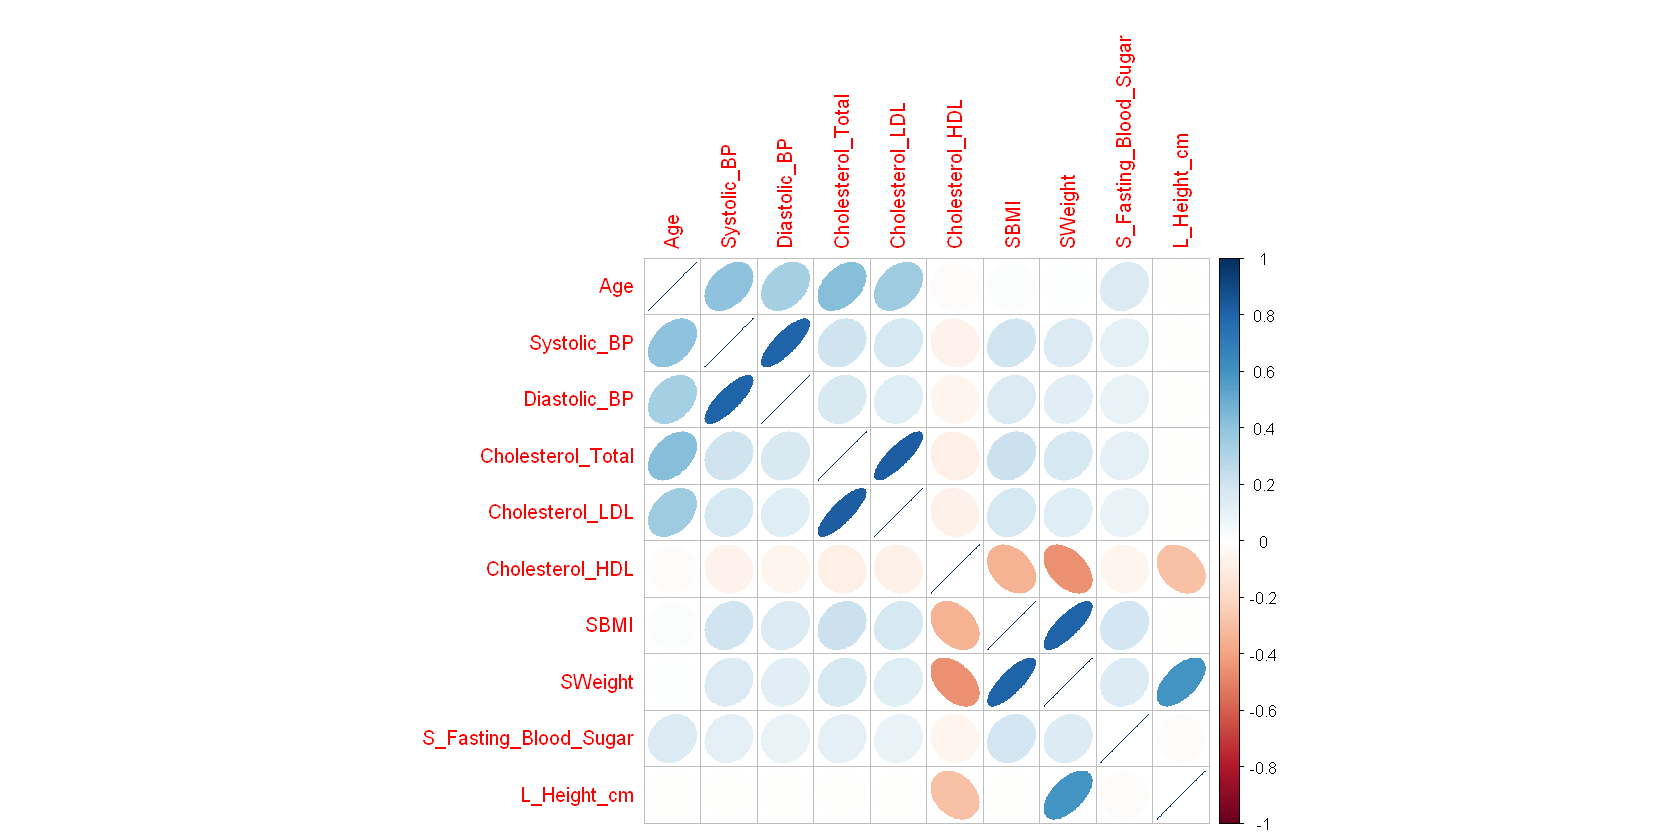

In [13]:
corrplot(cor(data_quanti),method="ellipse")

Cette deuxième représentation des corrélations confirme nos conclusions.

### Corrélations entre variables qualitatives et quantitatives

On s'intéresse dans cette partie aux corrélations entre les differentes variables quantitatives sur la variable Heart_Disease_Risk et l'effet des variables qualitatives sur la variable Cholesterol_LDL car c'est elles que nous allons essayer prédire par la suite.

**Etude de la relation entre les différents taux de cholesterol et le risque cardiaque en fonction du genre**

In [14]:
options(repr.plot.width = 20, repr.plot.height = 6)

#### Heart desease risk en fonction des variables quantitatives

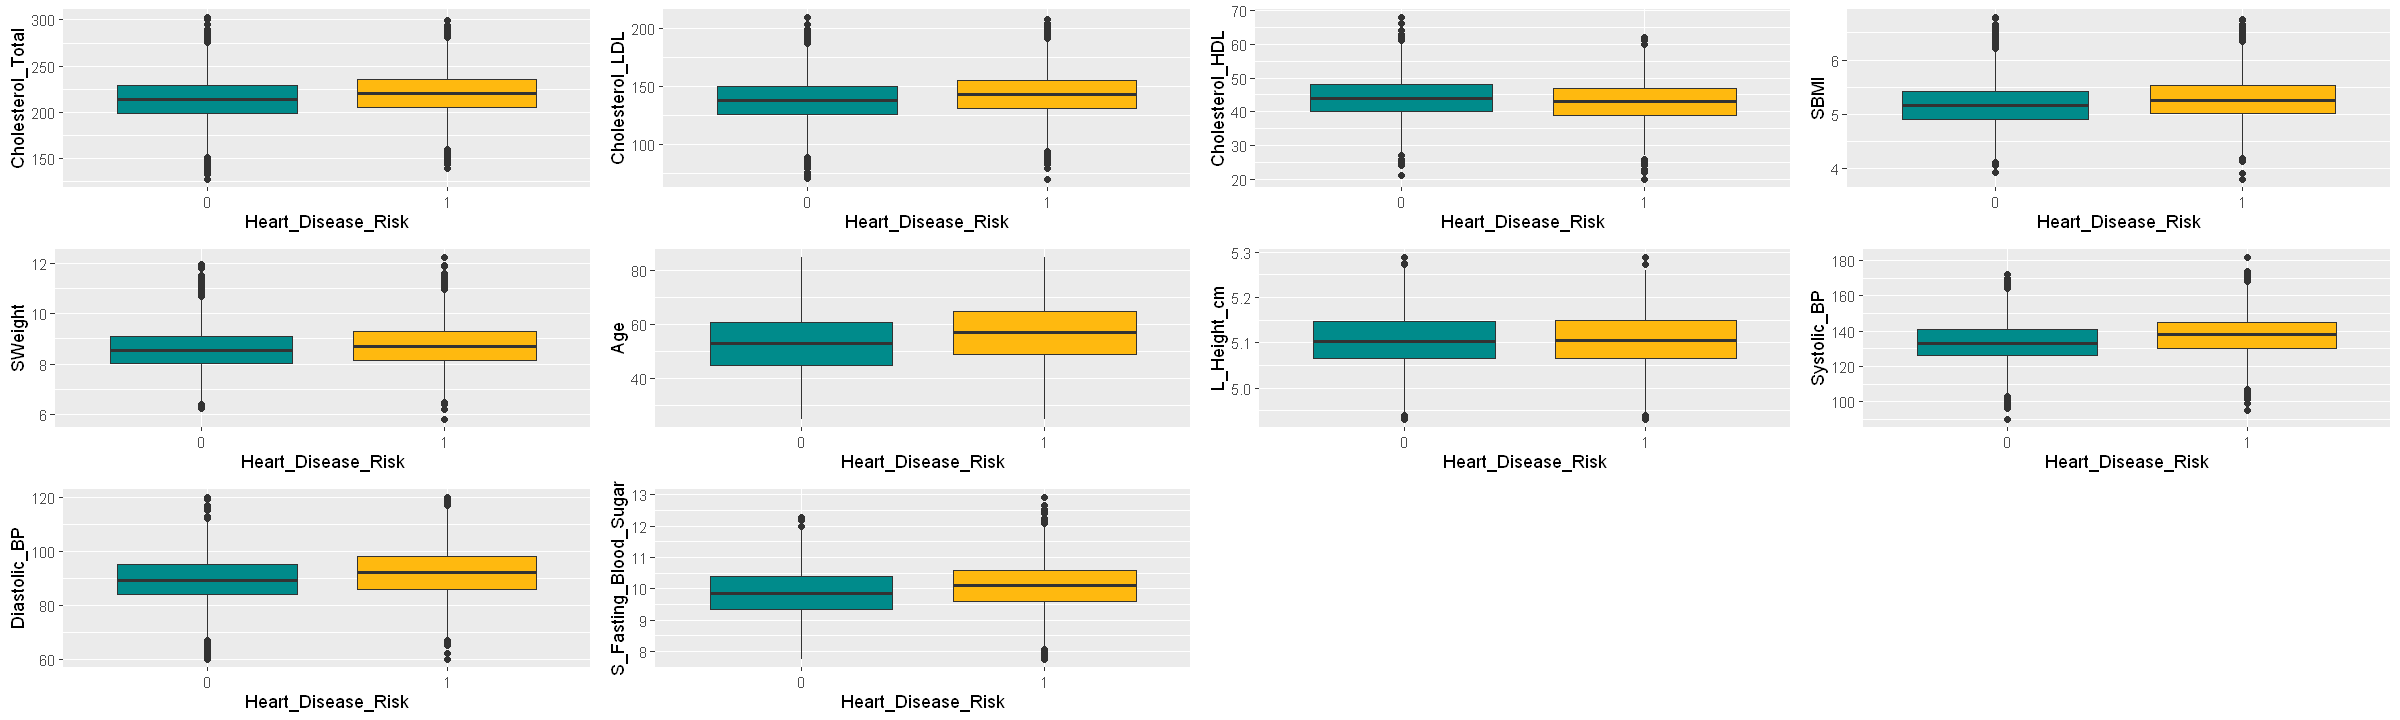

In [15]:
gg1=ggplot(data, aes(x = Heart_Disease_Risk, y= Cholesterol_Total)) +geom_boxplot(fill=colors)
gg2=ggplot(data, aes(x = Heart_Disease_Risk, y= Cholesterol_LDL)) +geom_boxplot(fill=colors)
gg3=ggplot(data, aes(x = Heart_Disease_Risk, y= Cholesterol_HDL)) +geom_boxplot(fill=colors)
gg4 = ggplot(data,aes(x = Heart_Disease_Risk, y= SBMI)) + geom_boxplot(fill=colors)
gg5 = ggplot(data,aes(x = Heart_Disease_Risk, y=SWeight)) + geom_boxplot(fill=colors)
gg6 = ggplot(data,aes(x = Heart_Disease_Risk, y=Age)) + geom_boxplot(fill=colors)
gg7 = ggplot(data,aes(x = Heart_Disease_Risk, y=L_Height_cm)) + geom_boxplot(fill=colors)
gg8 = ggplot(data,aes(x = Heart_Disease_Risk, y=Systolic_BP)) + geom_boxplot(fill=colors)
gg9 = ggplot(data,aes(x = Heart_Disease_Risk, y=Diastolic_BP)) + geom_boxplot(fill=colors)
gg10 = ggplot(data,aes(x = Heart_Disease_Risk, y=S_Fasting_Blood_Sugar)) + geom_boxplot(fill=colors)
grid.arrange(gg1,gg2,gg3,gg4,gg5,gg6,gg7,gg8,gg9,gg10,ncol=4)

On remarque que les variables liés à la tension artérielle ont une influence sur le risque d'accident vasculaire. De plus, L'IMC, le poids, l'âge et le taux de glycémie à un jeun jouent un rôle dans le risque d'accident cardiaque.On remarque que le taux de cholesterol total est plus élevé chez les personnes qui ont un risque élevé d'accident cardiaque. Lorsqu'on regarde en détail, le cholesterol LDL est lui aussi en plus grande quantité chez les personne à risque d'accident cardiaque. En revanche, le taux de cholesterol HDL est plus bas chez ces mêmes personnes. 

#### Cholesterol LDL en fonction des variables qualiatives

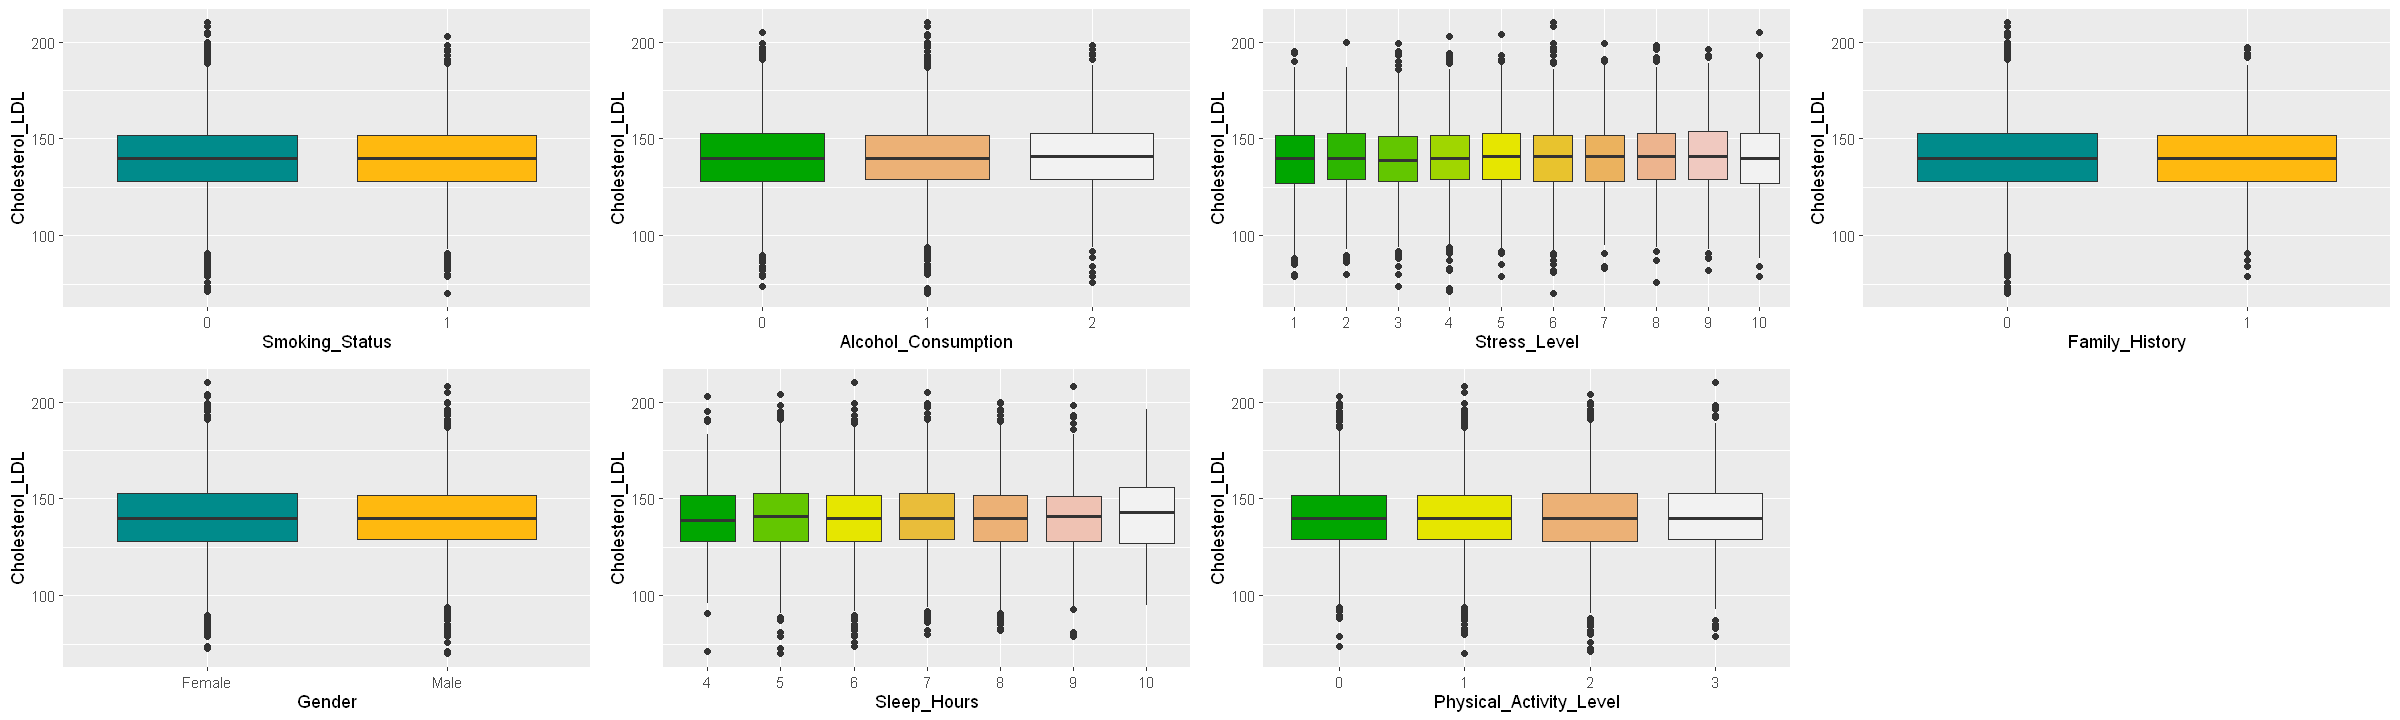

In [16]:
gc1 = ggplot(data,aes(x =Smoking_Status,  y= Cholesterol_LDL)) + geom_boxplot(fill=colors)
gc2 = ggplot(data,aes(x = Alcohol_Consumption, y=Cholesterol_LDL)) + geom_boxplot(fill = terrain.colors(3))
gc3 = ggplot(data,aes(x = Stress_Level, y=Cholesterol_LDL)) + geom_boxplot(fill = terrain.colors(10))
gc4 = ggplot(data,aes(x = Family_History, y=Cholesterol_LDL)) + geom_boxplot(fill = colors)
gc5 = ggplot(data,aes(x = Gender, y=Cholesterol_LDL)) + geom_boxplot(fill = colors)
gc6 = ggplot(data,aes(x = Sleep_Hours, y=Cholesterol_LDL)) + geom_boxplot(fill = terrain.colors(7))
gc7 = ggplot(data,aes(x = Physical_Activity_Level, y=Cholesterol_LDL)) + geom_boxplot(fill = terrain.colors(4))
grid.arrange(gc1,gc2,gc3,gc4,gc5,gc6,gc7,ncol=4)

En revanche, on note par cette affichage que les variables quantitatives n'ont pas à priori d'influence sur le taux de "mauvais" cholestérol.

### Corrélation qualitatif-qualitatif

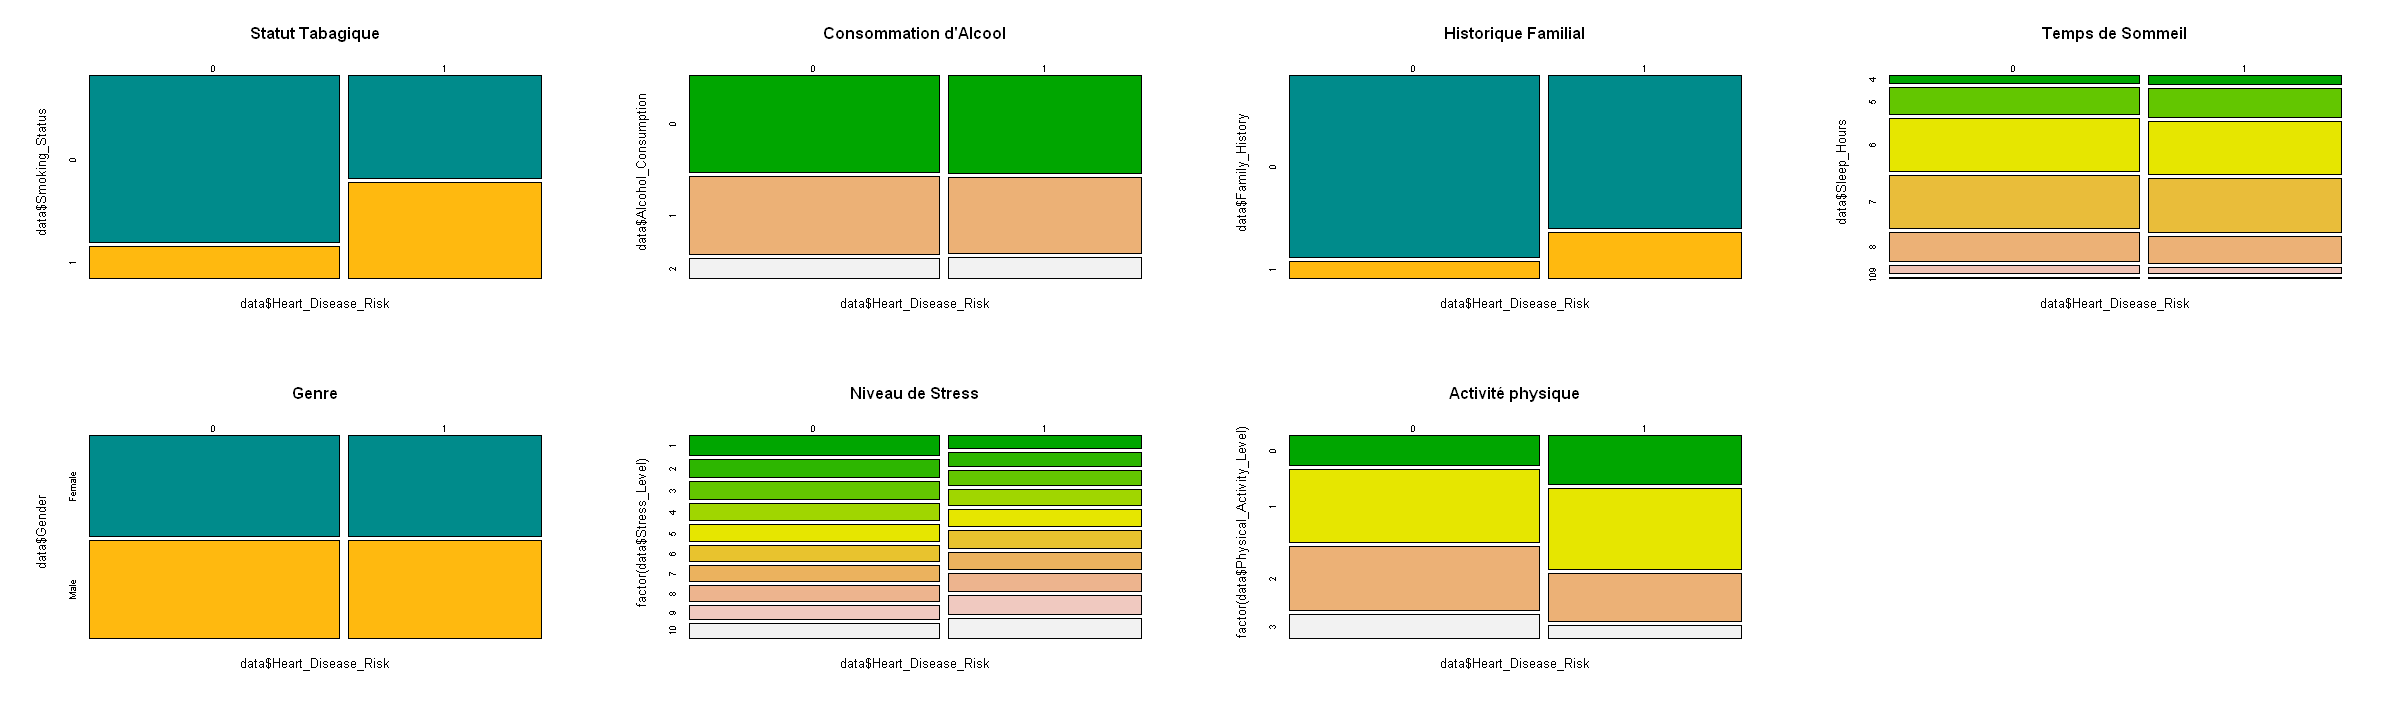

In [17]:
#Rendre jolie les labels ? 
par(mfrow = c(2, 4))
mosaicplot(data$Heart_Disease_Risk ~ data$Smoking_Status, main = "Statut Tabagique",col=colors)
mosaicplot(data$Heart_Disease_Risk ~ data$Alcohol_Consumption, main = "Consommation d'Alcool",col = terrain.colors(3))
mosaicplot(data$Heart_Disease_Risk ~ data$Family_History, main = "Historique Familial",col=colors)
mosaicplot(data$Heart_Disease_Risk ~ data$Sleep_Hours, main = "Temps de Sommeil",col = terrain.colors(7))
mosaicplot(data$Heart_Disease_Risk ~ data$Gender, main = "Genre",col=colors)
mosaicplot(data$Heart_Disease_Risk ~ factor(data$Stress_Level),main = "Niveau de Stress",col = terrain.colors(10))
mosaicplot(data$Heart_Disease_Risk ~ factor(data$Physical_Activity_Level), main = "Activité physique",col = terrain.colors(4))

On voit sur les graphiques ci-dessus que le risque d'accident vaculaire est fortement influencé par le fait que l'individus soit fumeur ou non. De plus, l'antécédent cardiaque familial est un facteur qui influence la variable Heart_Desease_Risk. Enfin, on remarque que le fait de ne pas avoir d'activité physique et d'être stressé serait un facteur qui influencerait  le risque d'accident cardiaque.

# 3. ACP

Puisque nous avons des variables avec des valeurs très différentes, il est nécessaire de centrer et réduire les données(scale.unit=TRUE).

In [18]:
res_pca=PCA(data_quanti, scale.unit = TRUE, graph = TRUE)
res_pca$eig

,eigenvalue,percentage of variance,cumulative percentage of variance
comp 1,2.920380259,29.20380259,29.20380
comp 2,2.037915226,20.37915226,49.58295
comp 3,1.480190242,14.80190242,64.38486
comp 4,1.056831036,10.56831036,74.95317
comp 5,0.907168905,9.07168905,84.02486
comp 6,0.686433196,6.86433196,90.88919
comp 7,0.556520101,5.56520101,96.45439
comp 8,0.188839990,1.88839990,98.34279
comp 9,0.164500697,1.64500697,99.98780
comp 10,0.001220346,0.01220346,100.00000


On va garder les 5 premières composantes principales car à elles, elles expliquent plus de 80% de la variance.

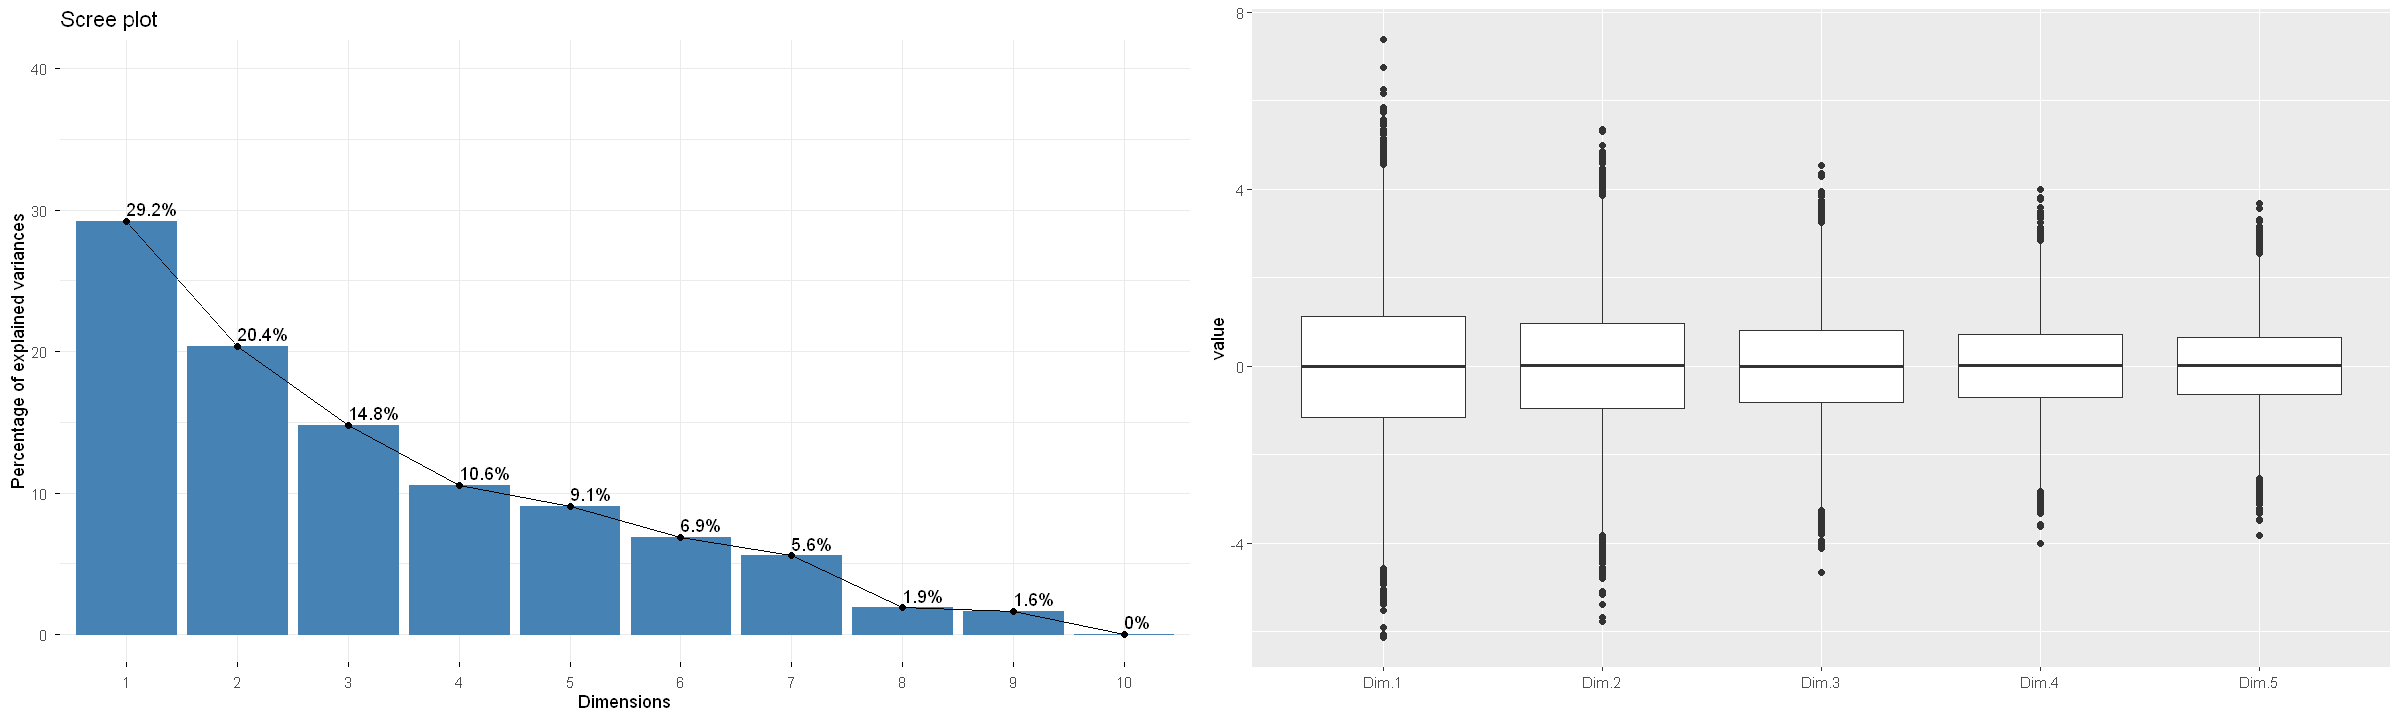

In [19]:
g1<-fviz_eig(res_pca, addlabels = TRUE, ylim = c(0, 40))
g2<-ggplot(melt(res_pca$ind$coord),aes(x=Var2,y=value))+
  geom_boxplot()+
  xlab("")
grid.arrange(g1,g2,ncol=2)

On remarque que les deux premières dimensions portent près de 50% de l'information, on voit que le coude est présent entre la 2ème et 3ème dimension, on va pouvoir se concentrer sur le premier plan factoriel pour la suite des analyses


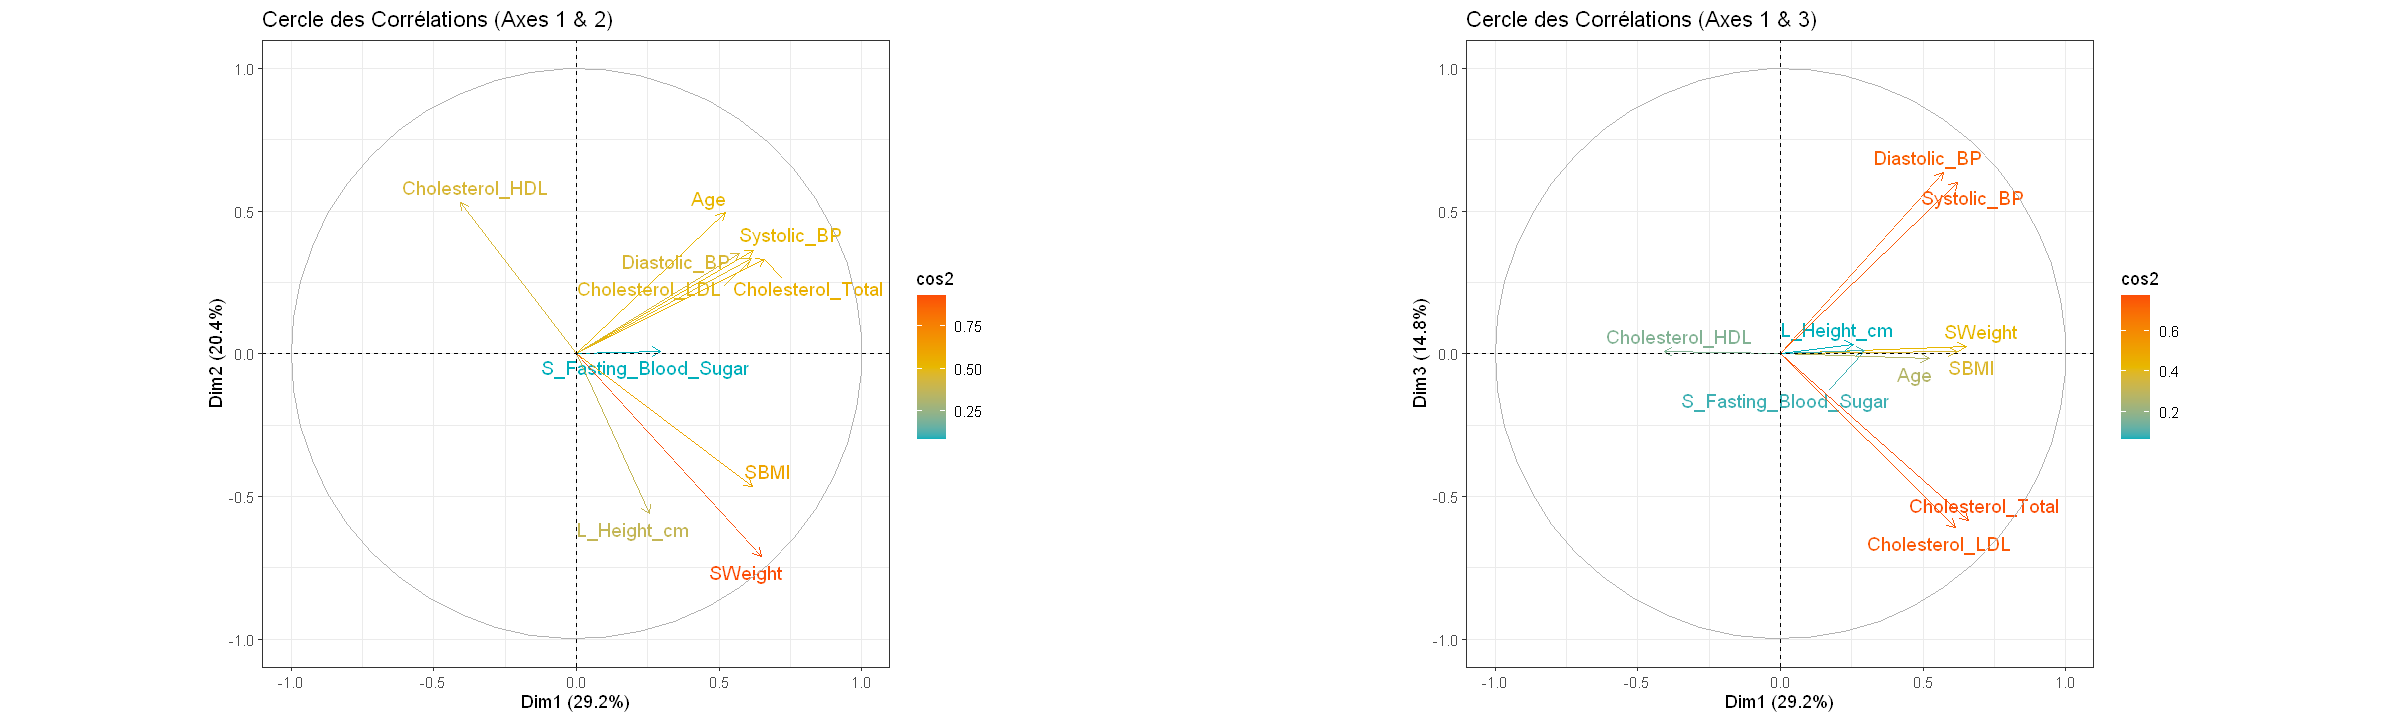

In [20]:

v1 <- fviz_pca_var(res_pca, axes=c(1,2), col.var="cos2",
                   gradient.cols = c("#00AFBB", "#E7B800", "#FC4E07"),
                   repel = TRUE) + 
  labs(title = "Cercle des Corrélations (Axes 1 & 2)") + theme_bw()


v2 <- fviz_pca_var(res_pca, axes=c(1,3), col.var="cos2",
                   gradient.cols = c("#00AFBB", "#E7B800", "#FC4E07"),
                   repel = TRUE) + 
  labs(title = "Cercle des Corrélations (Axes 1 & 3)") + theme_bw()

grid.arrange(v1, v2, ncol=2)

L'examen des deux premiers plans factoriels révèle une organisation du risque autour de trois dimensions indépendantes : le plan 1-2 met en évidence un pôle « morpho-tensionnel » (forte corrélation entre le BMI et les pressions artérielles sur l'axe 1) totalement orthogonal à un pôle « lipidique » (porté par le cholestérol LDL sur l'axe 2). Le plan 1-3 complète cette analyse en faisant émerger des facteurs isolés, comme l'âge et le cholestérol HDL, qui apportent une information complémentaire non captée par la corpulence ou le mauvais cholestérol. Cette structure confirme la nécessité de traiter séparément ces leviers biologiques lors de la modélisation et souligne la redondance critique entre le poids et l'IMC, qu'il faudra arbitrer pour éviter tout biais de multicolinéarité.

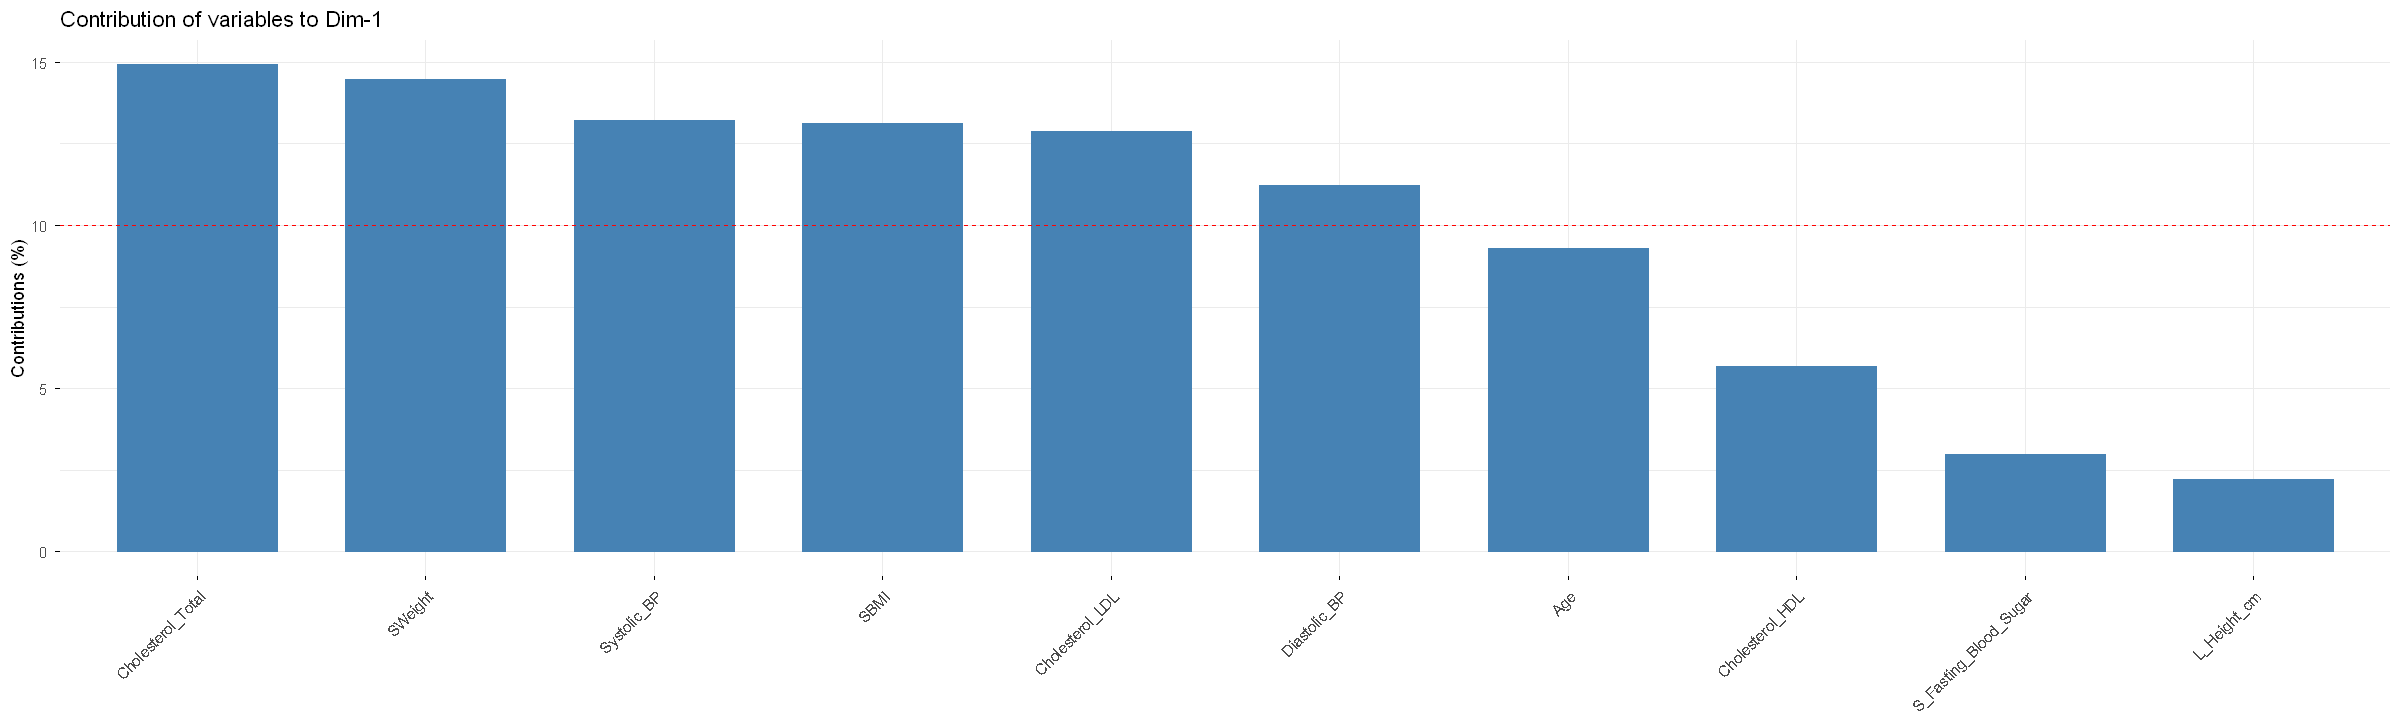

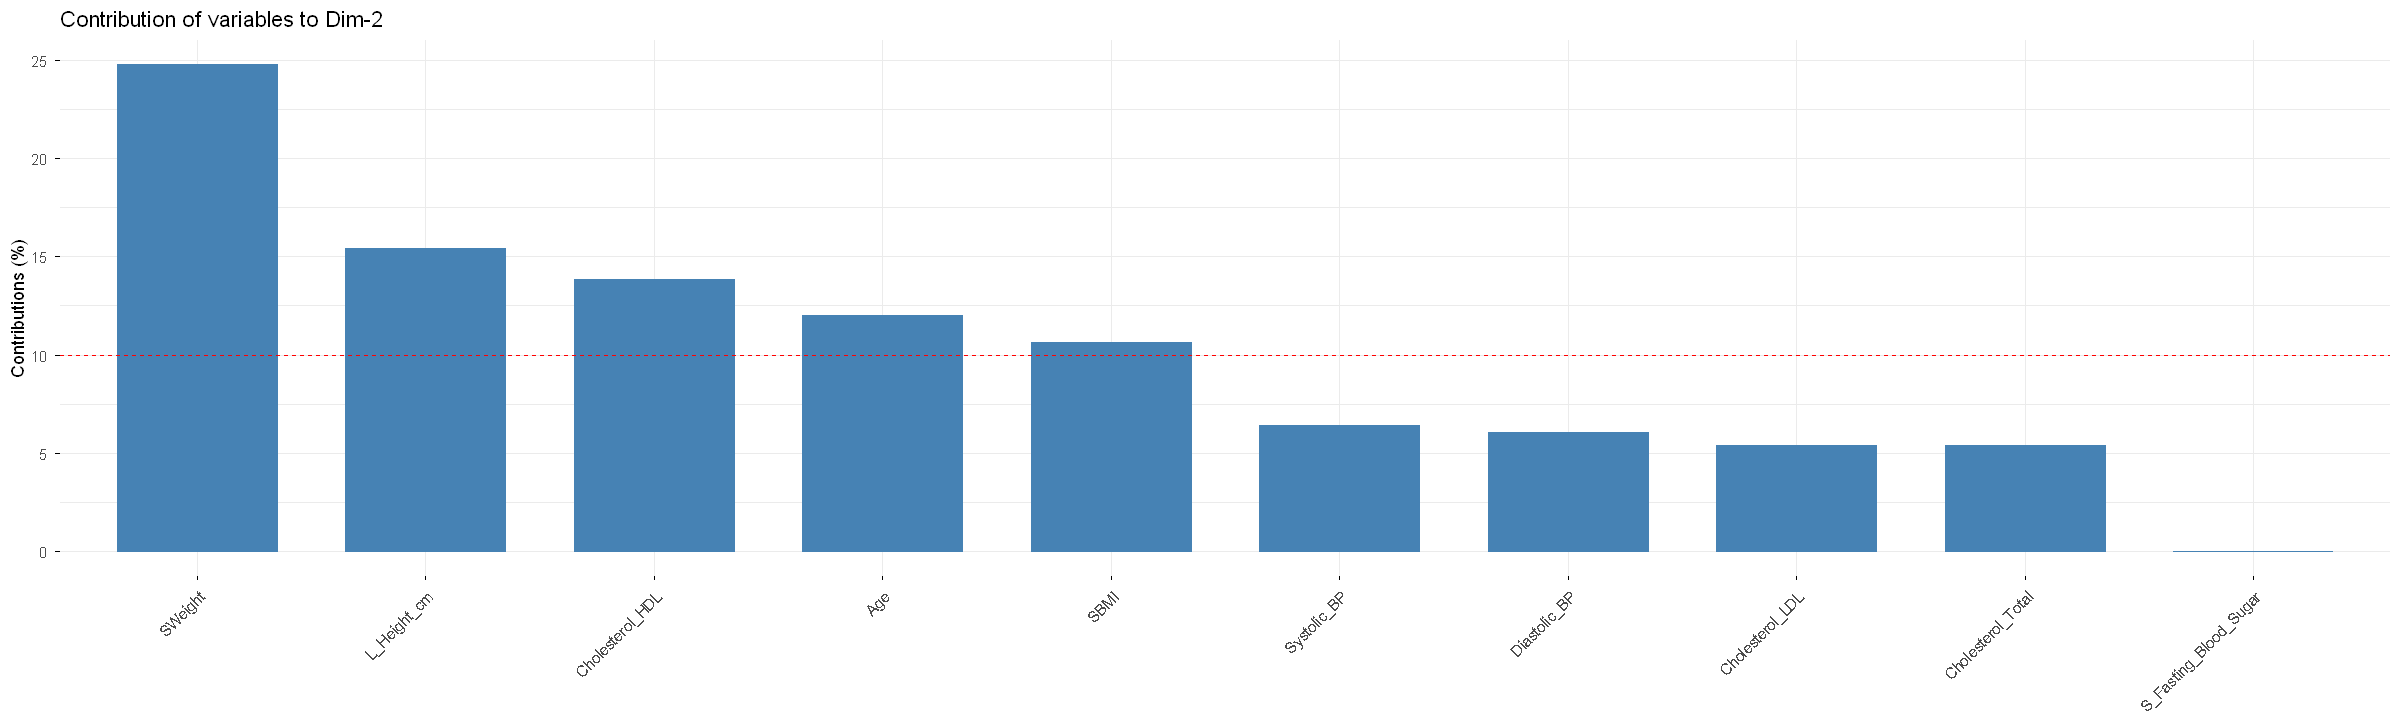

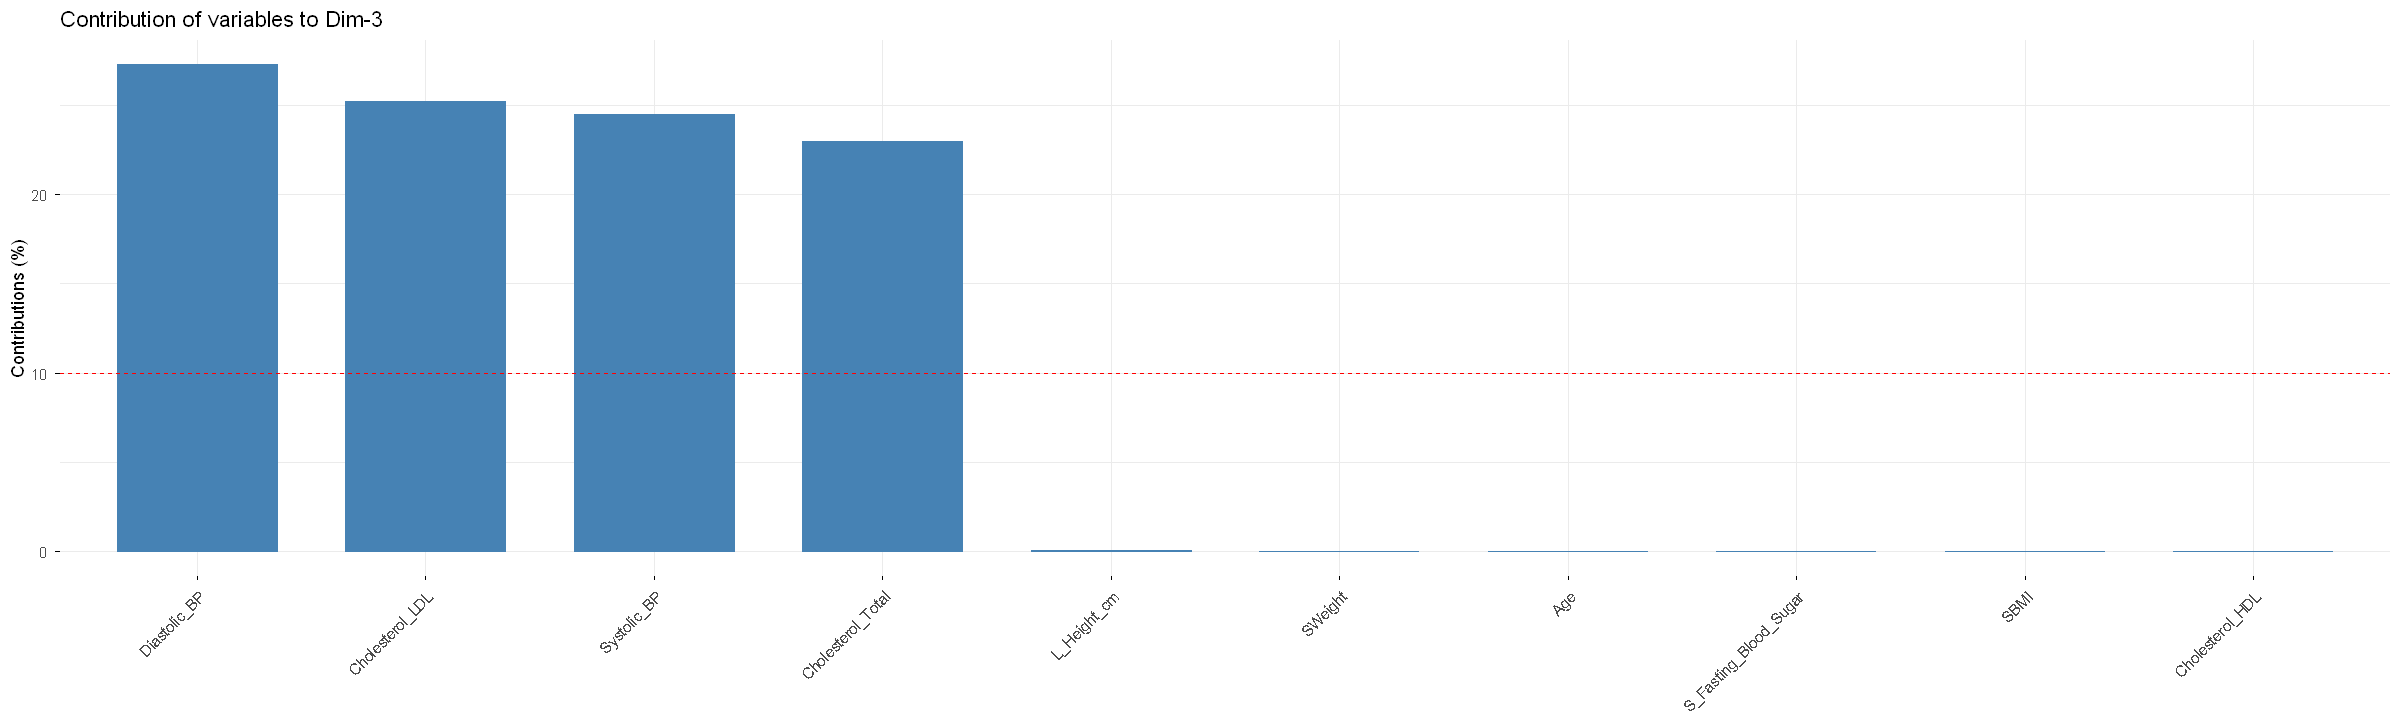

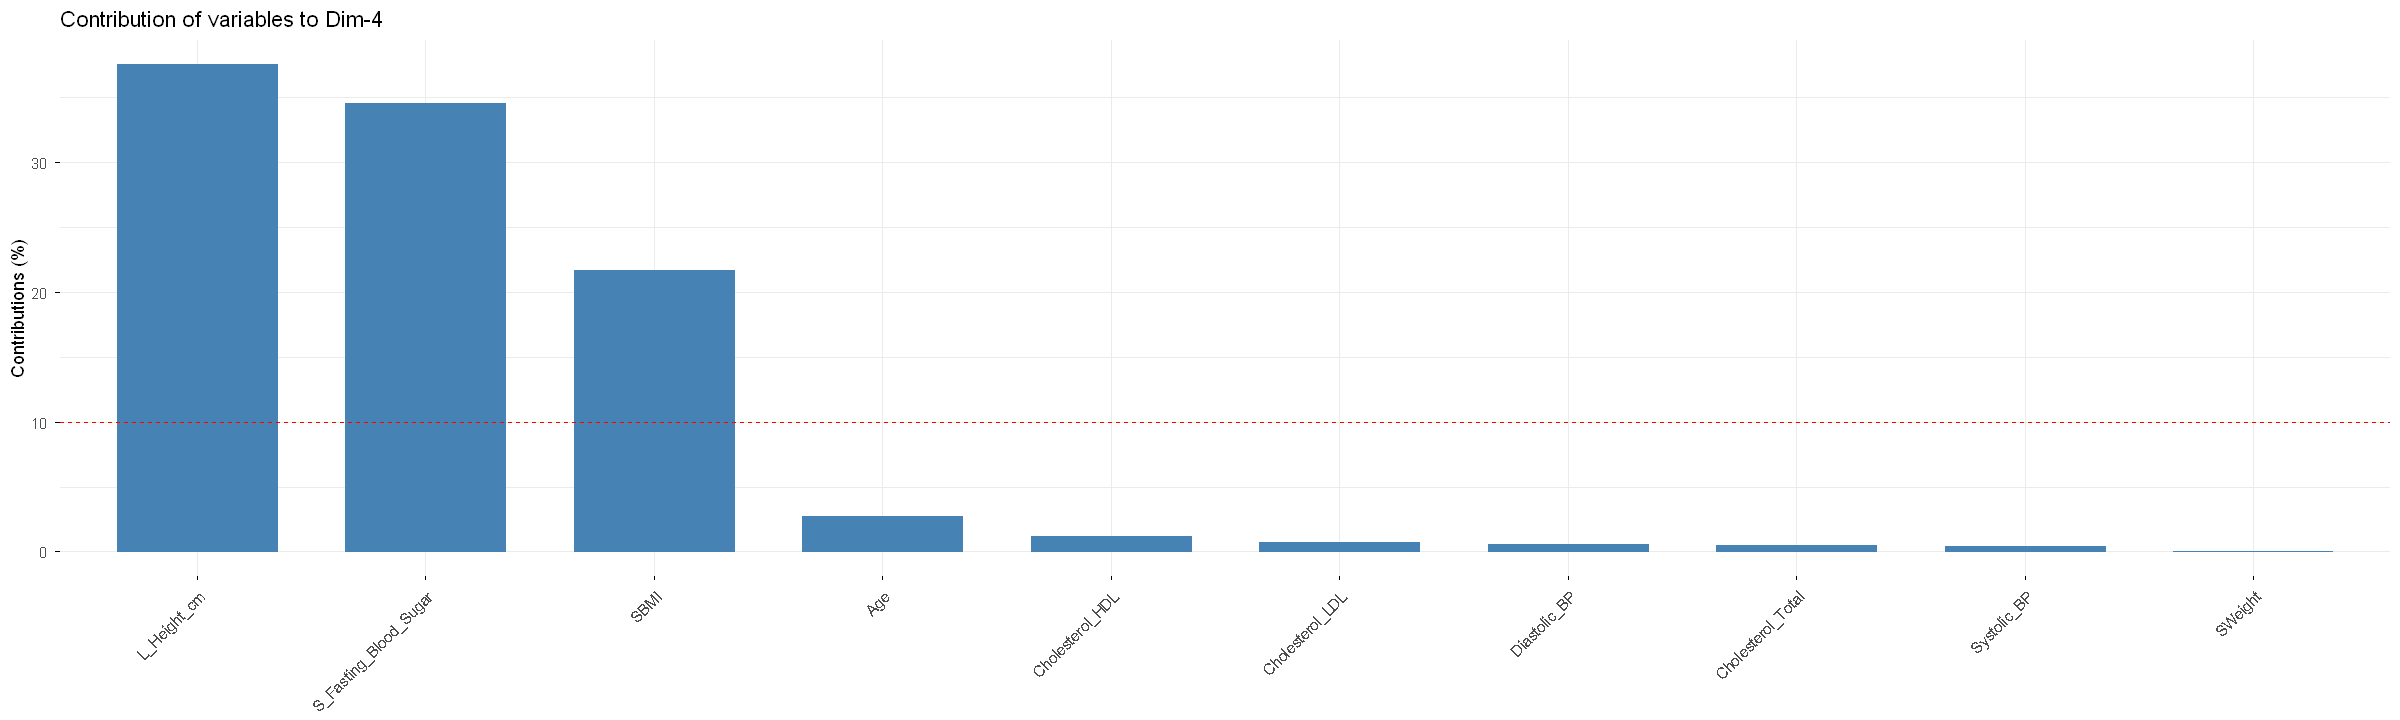

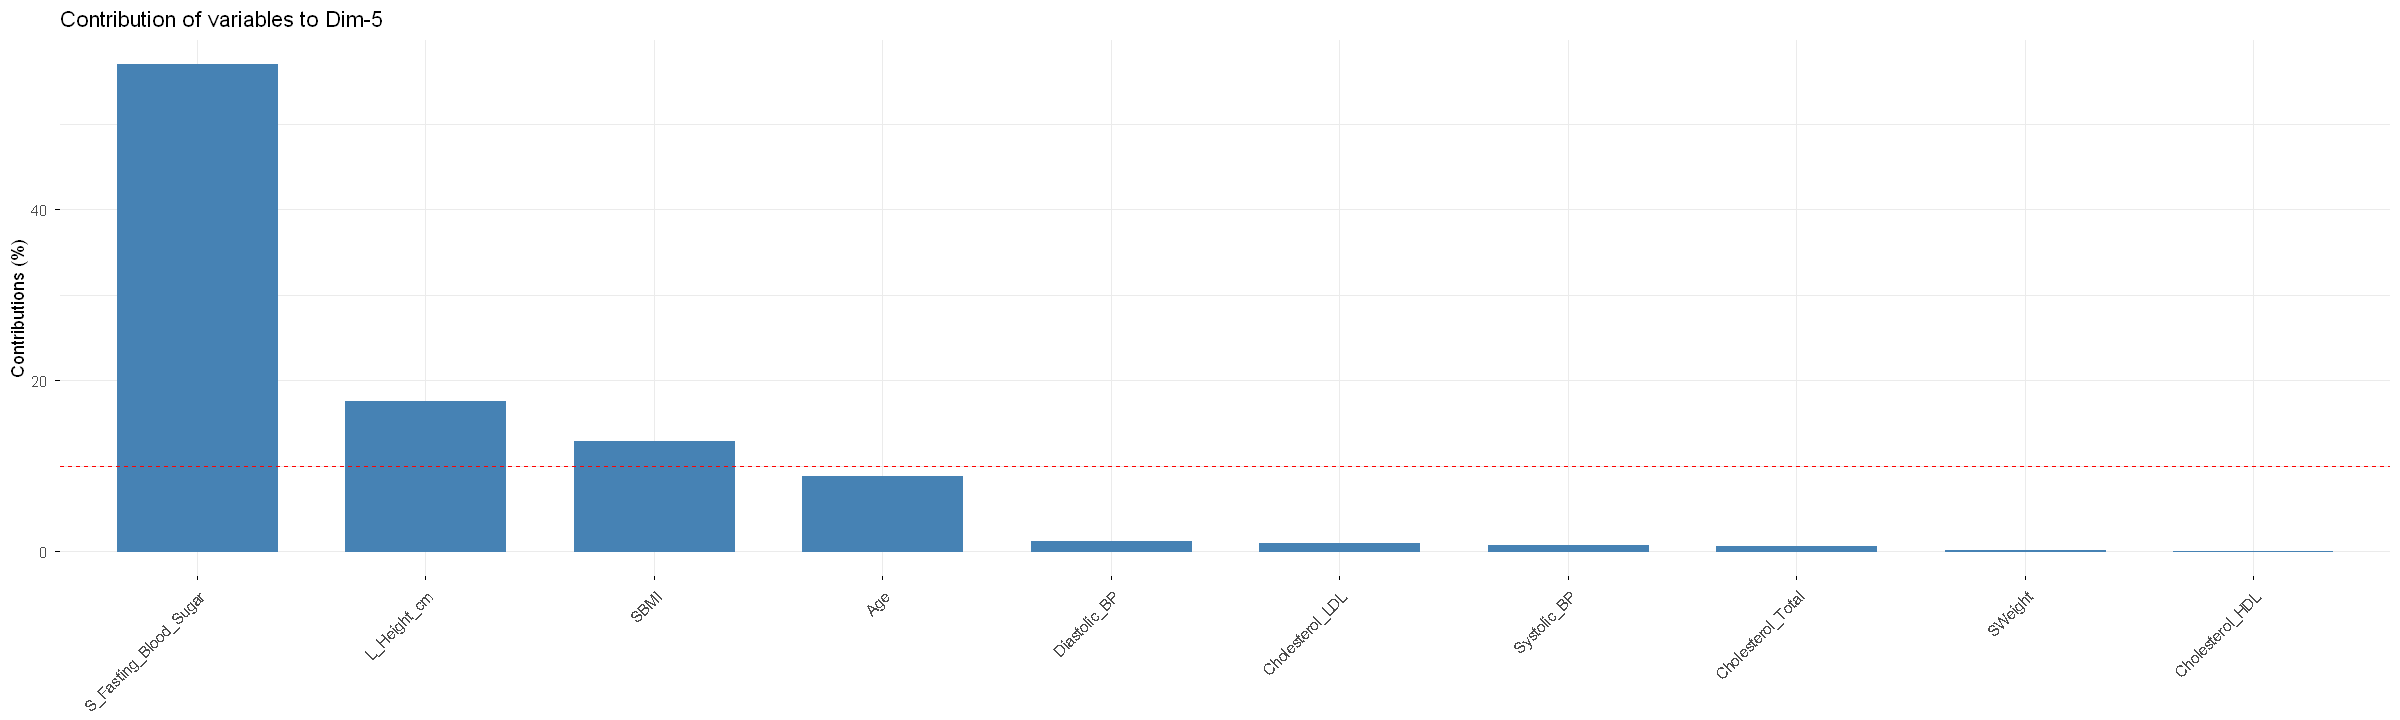

In [21]:
# Visualiser les 30 individus qui contribuent le plus à l'Axe 1
fviz_contrib(res_pca, choice = "var", axes = 1)
fviz_contrib(res_pca, choice = "var", axes = 2) 
fviz_contrib(res_pca, choice = "var", axes = 3)
fviz_contrib(res_pca, choice = "var", axes = 4) 
fviz_contrib(res_pca, choice = "var", axes = 5) 


On voit que la variable S_Fasting_Blood_Sugar contribue significativement à la 5e dimension alors qu'elle contribue très peu 3 première composantes principales

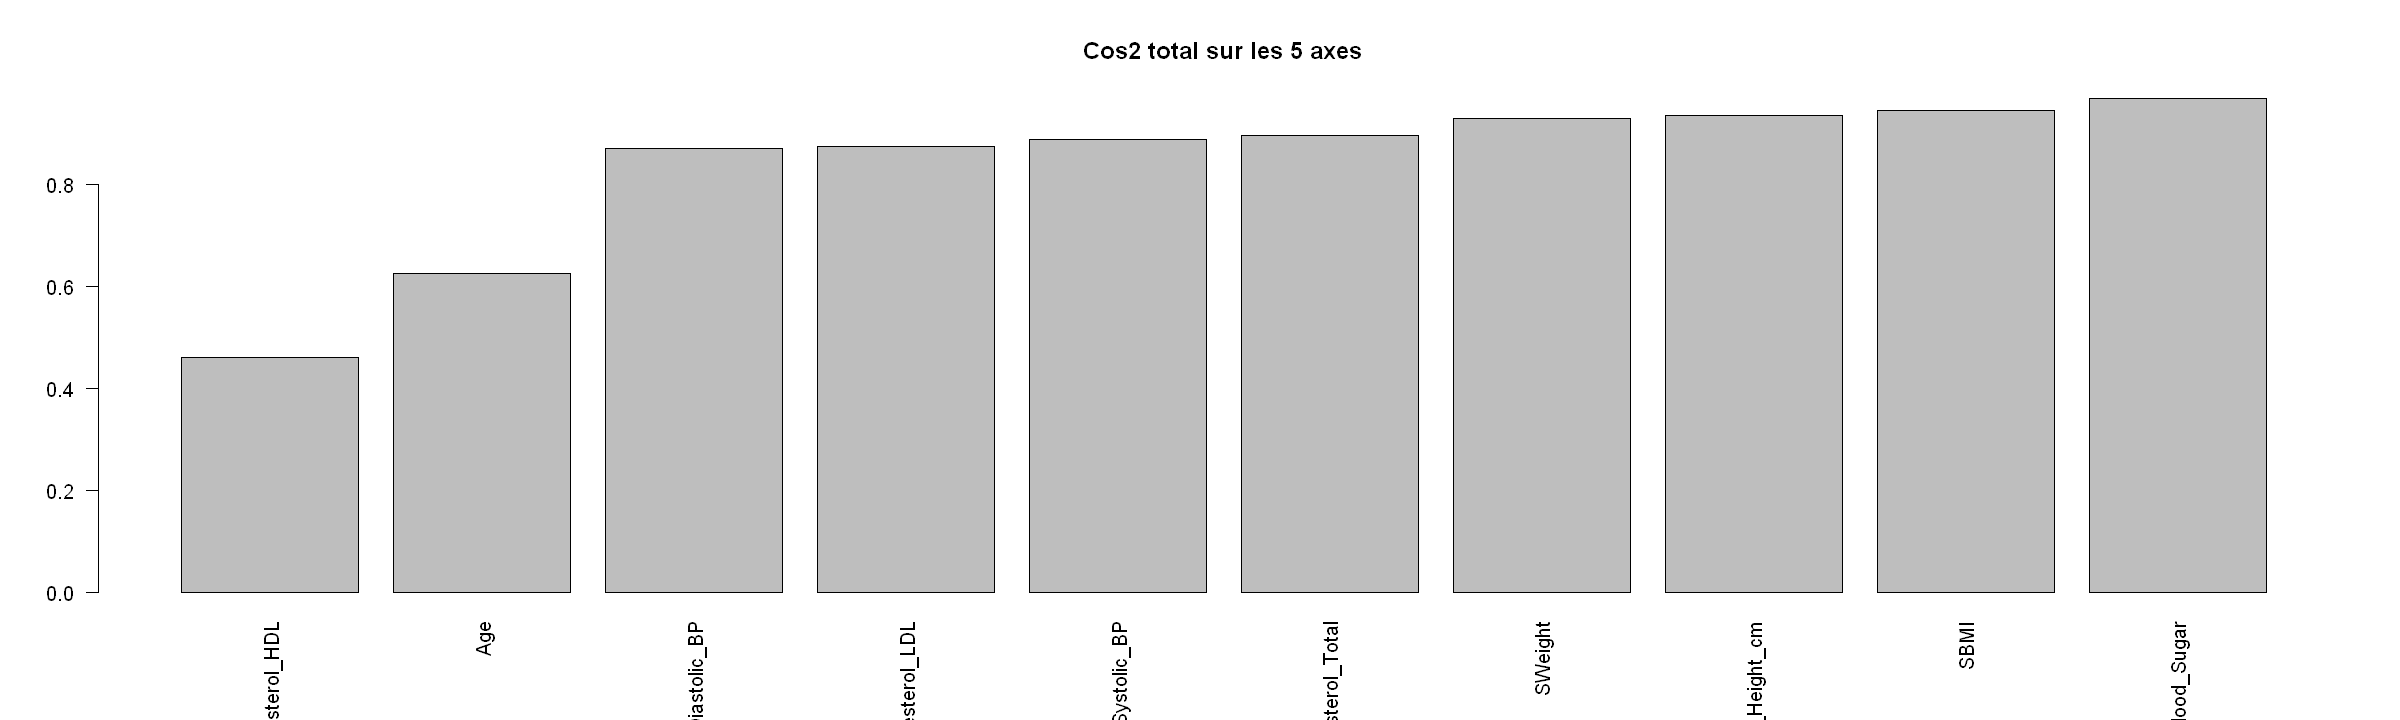

In [22]:
var_cos2_sum <- rowSums(res_pca$var$cos2[, 1:5])
barplot(sort(var_cos2_sum), las=2, main="Cos2 total sur les 5 axes")

L'information de l'age ainsi que du cholestérol n'est pas présente dans les 5 premières composantes principales de l'ACP, elles doivent être surement contenue dans les autres dimensions.

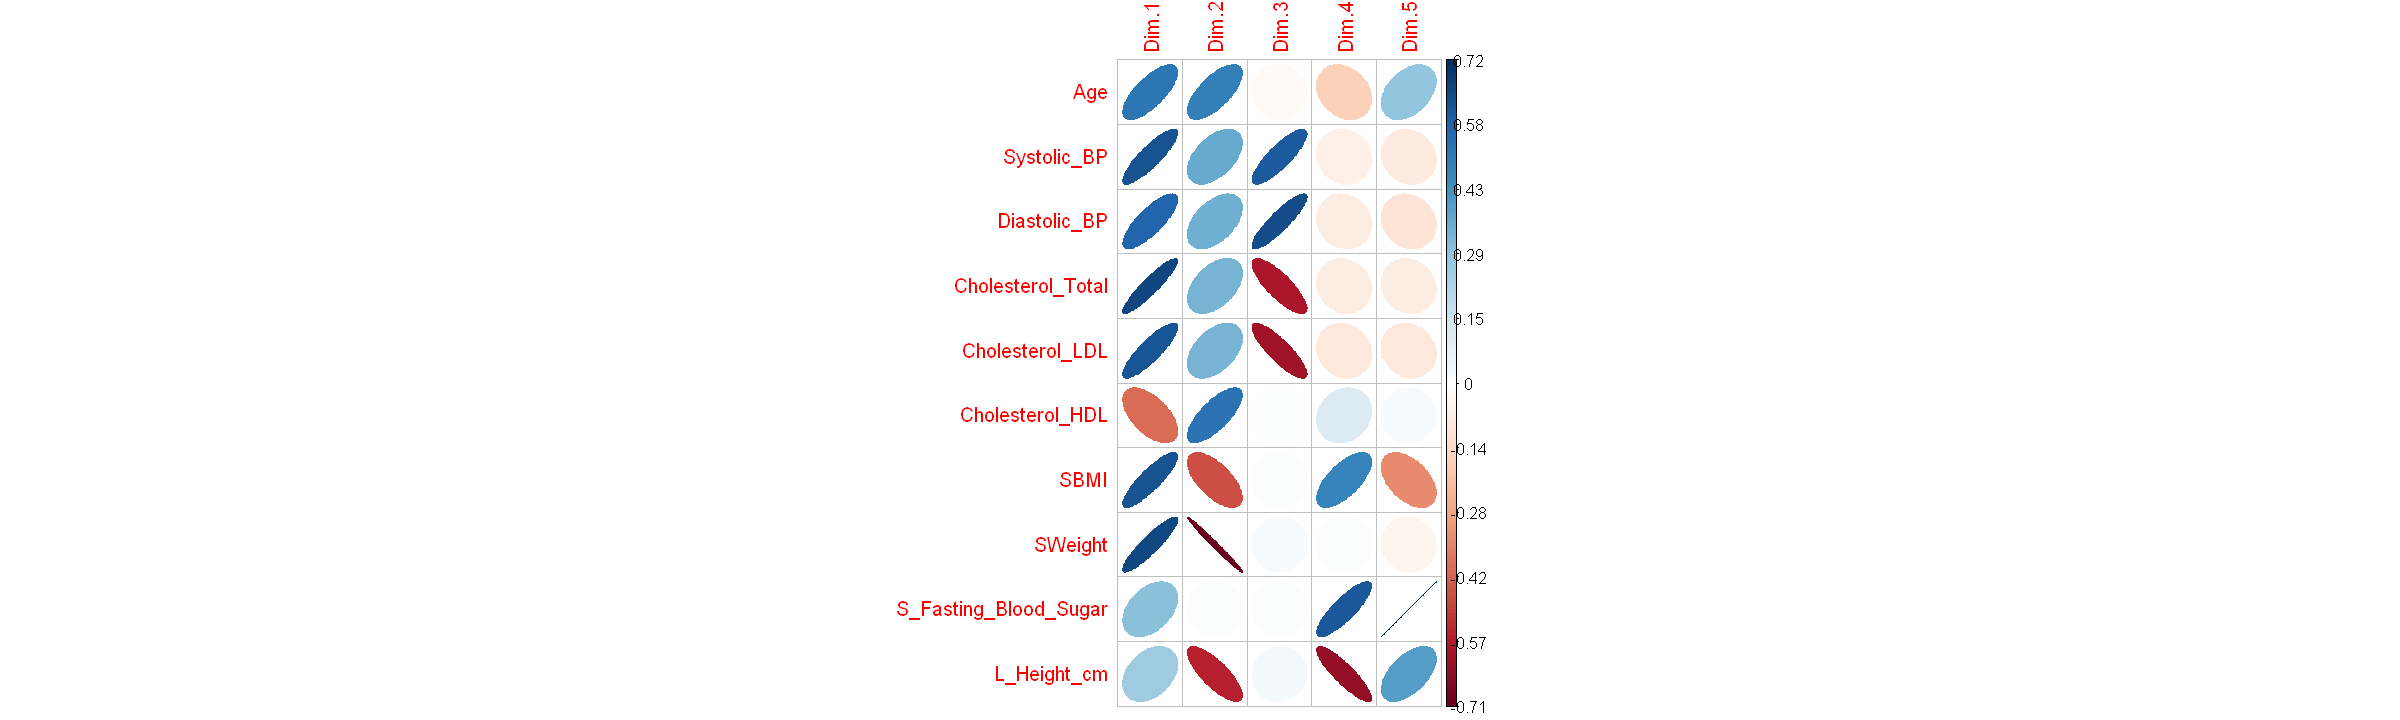

In [23]:
corrplot(res_pca$var$cor, is.corr=FALSE,method="ellipse")

Ce corrplot synthétise la contribution de chaque variable aux axes de l'ACP. La finesse et l'inclinaison des ellipses confirment la polarisation des données : on observe un bloc biométrique (poids et tensions) saturant la Dim 1, tandis que le profil lipidique (LDL) se concentre sur la Dim 2. L'étroitesse des formes sur les dimensions supérieures pour l'âge ou le HDL prouve que ces variables apportent une information spécifique et indépendante, validant ainsi la structure multidimensionnelle du jeu de données.

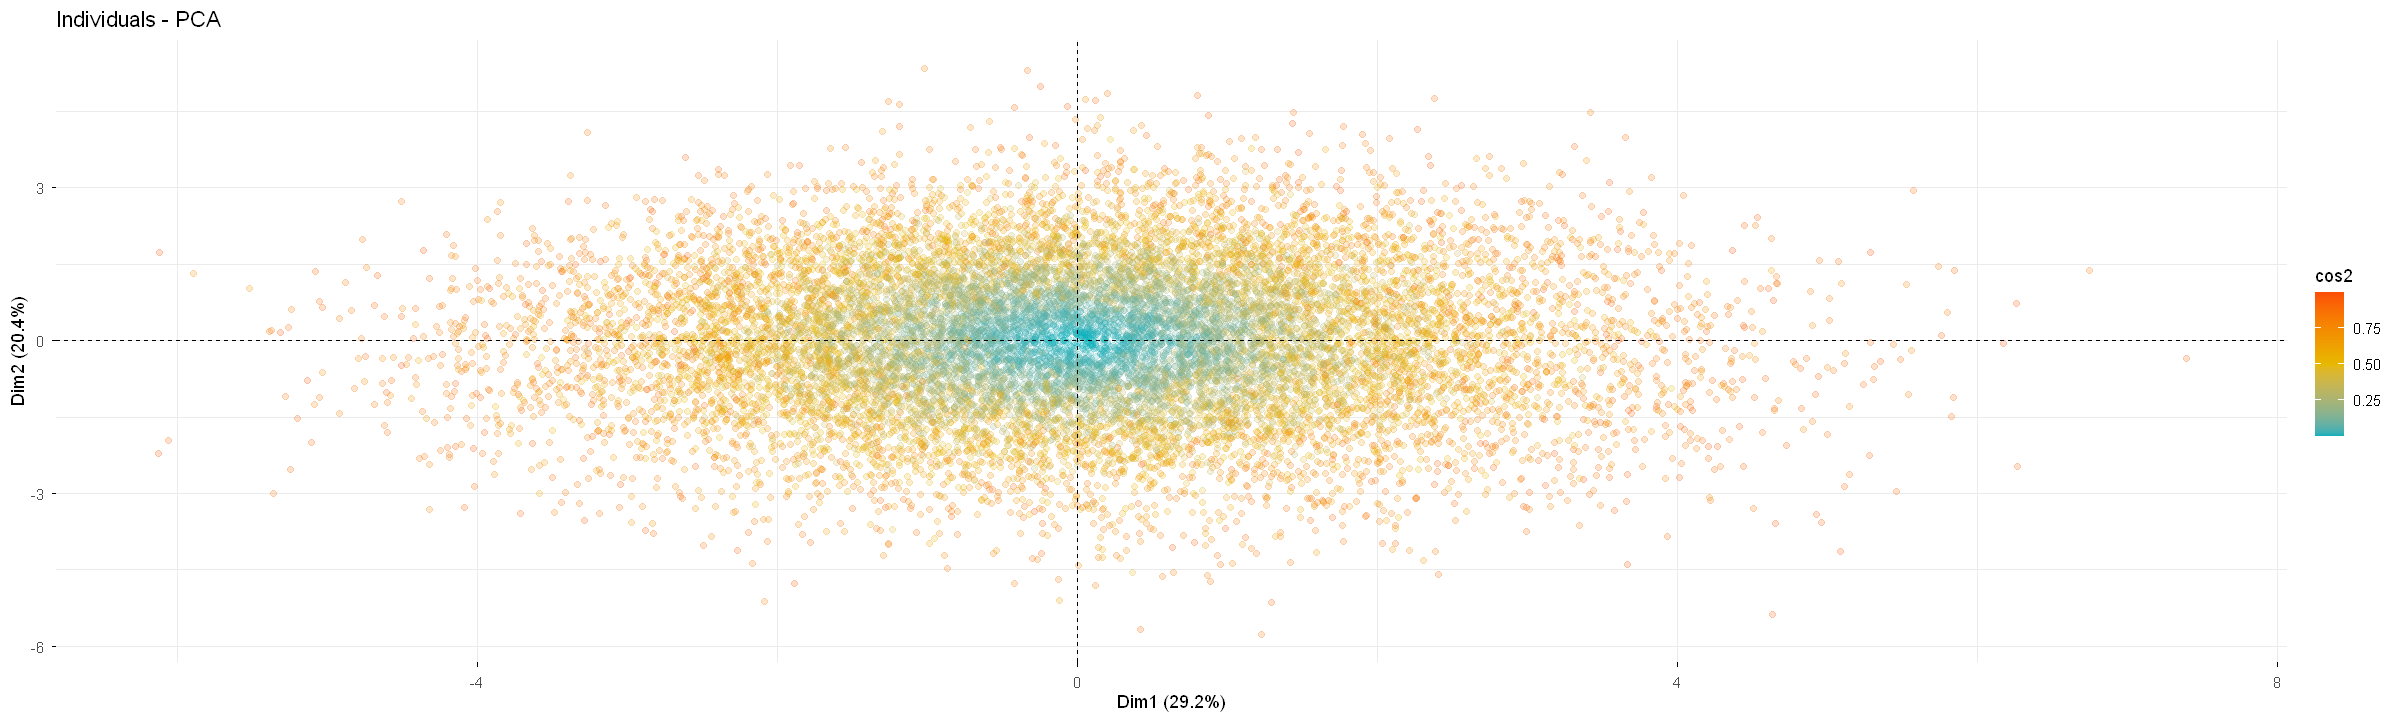

In [24]:
fviz_pca_ind(res_pca, 
             col.ind = "cos2", 
             gradient.cols = c("#00AFBB", "#E7B800", "#FC4E07"),
             label = "none",        # On cache les noms (trop nombreux)
             alpha.ind = 0.2)

Ce "nuage d'individus" permet de visualiser la structure globale de la population. L'utilisation du $cos^2$ pour la coloration montre que les patients situés en périphérie (en rouge/orangé) sont ceux dont le profil est le mieux expliqué par les axes de poids et de cholestérol. La forte densité centrale indique une population homogène, tandis que l'étalement du nuage confirme la présence d'individus aux profils extrêmes (outliers) qui tirent la variance. 

### Interprétation avec les variables qualitatives

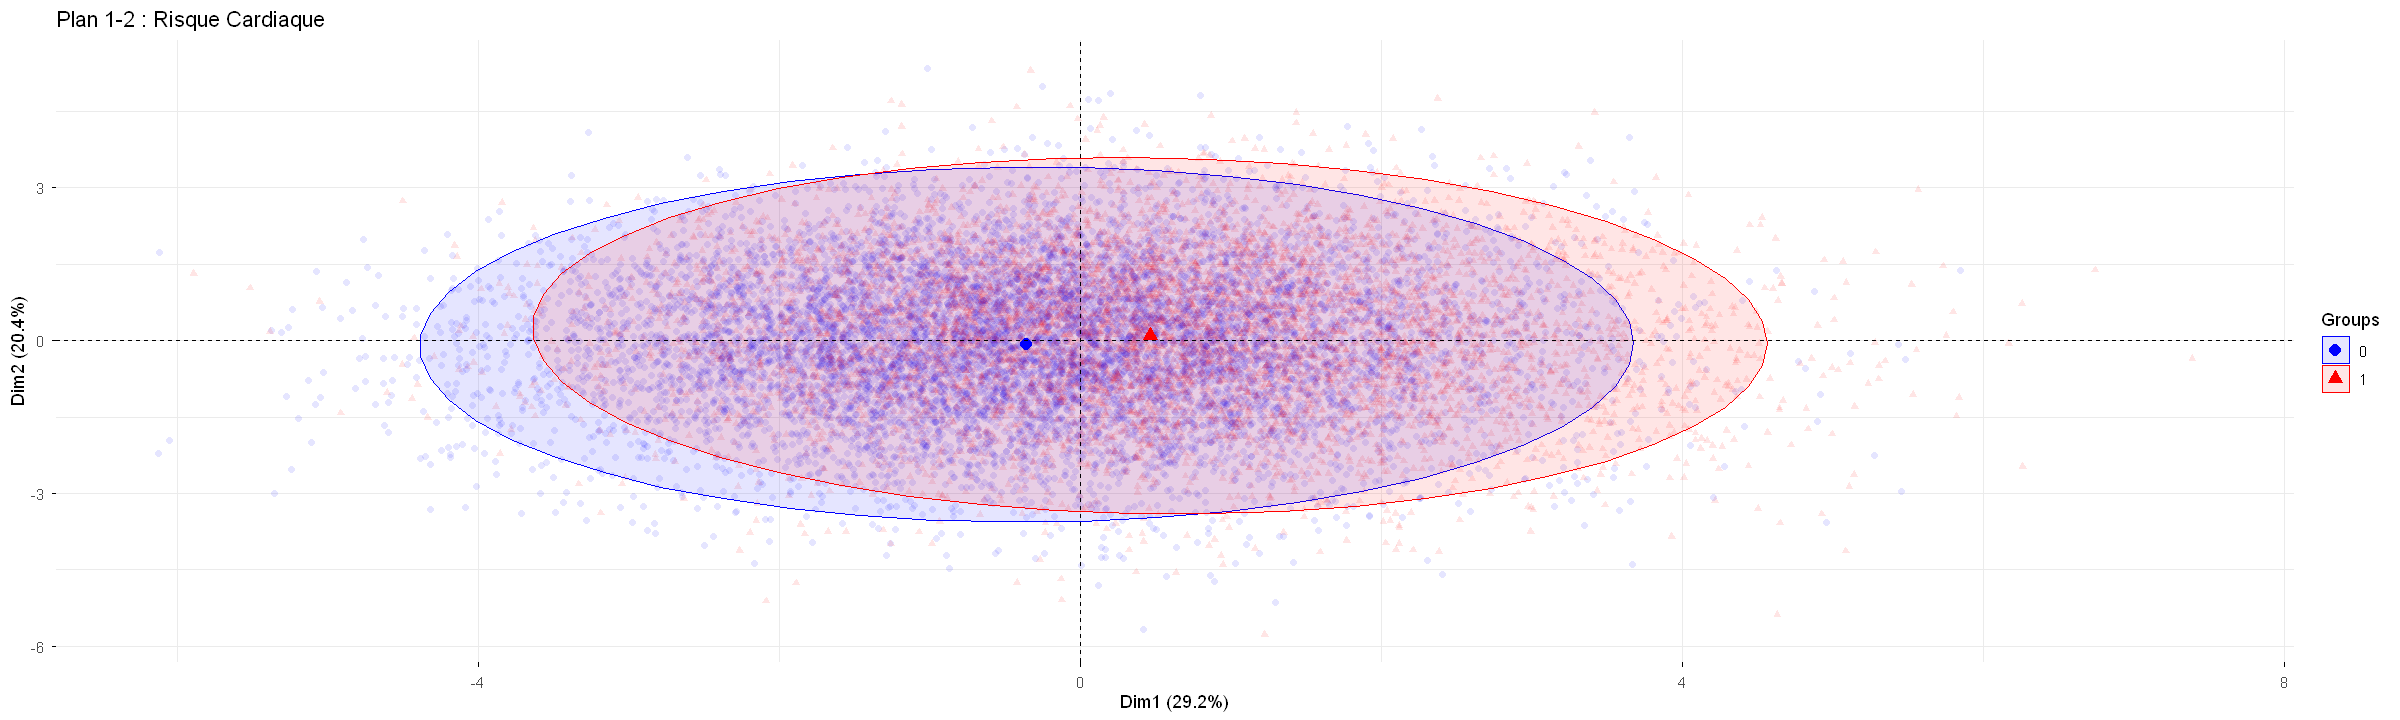

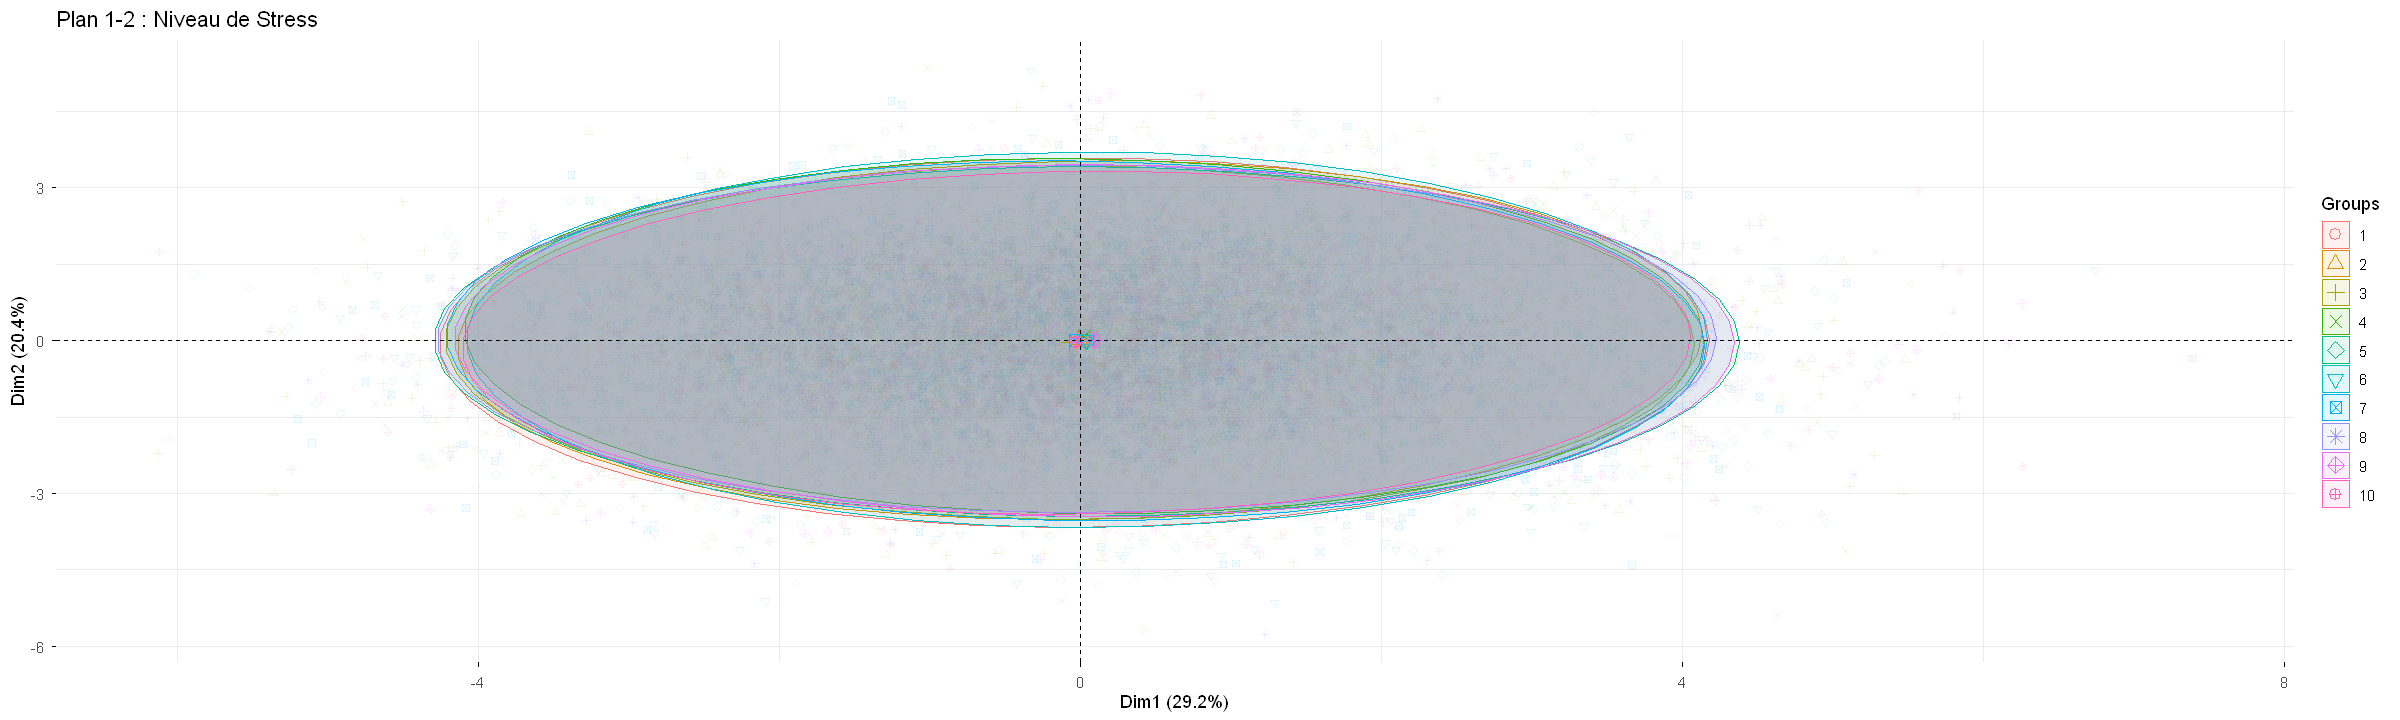

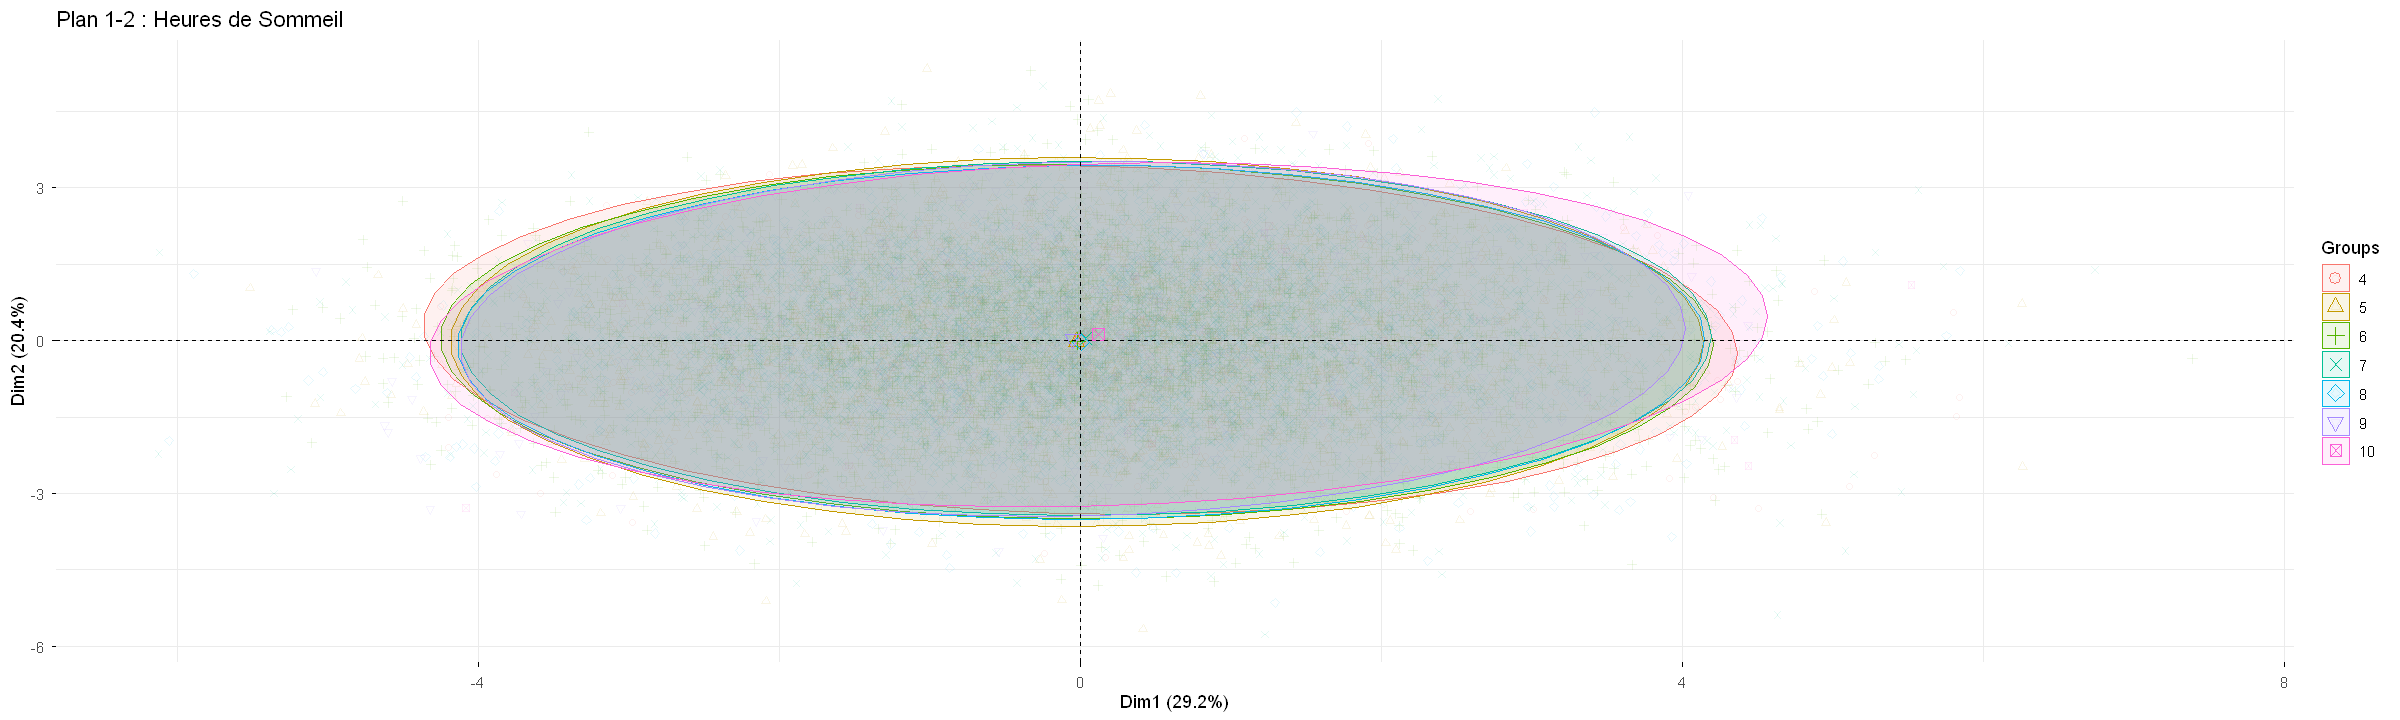

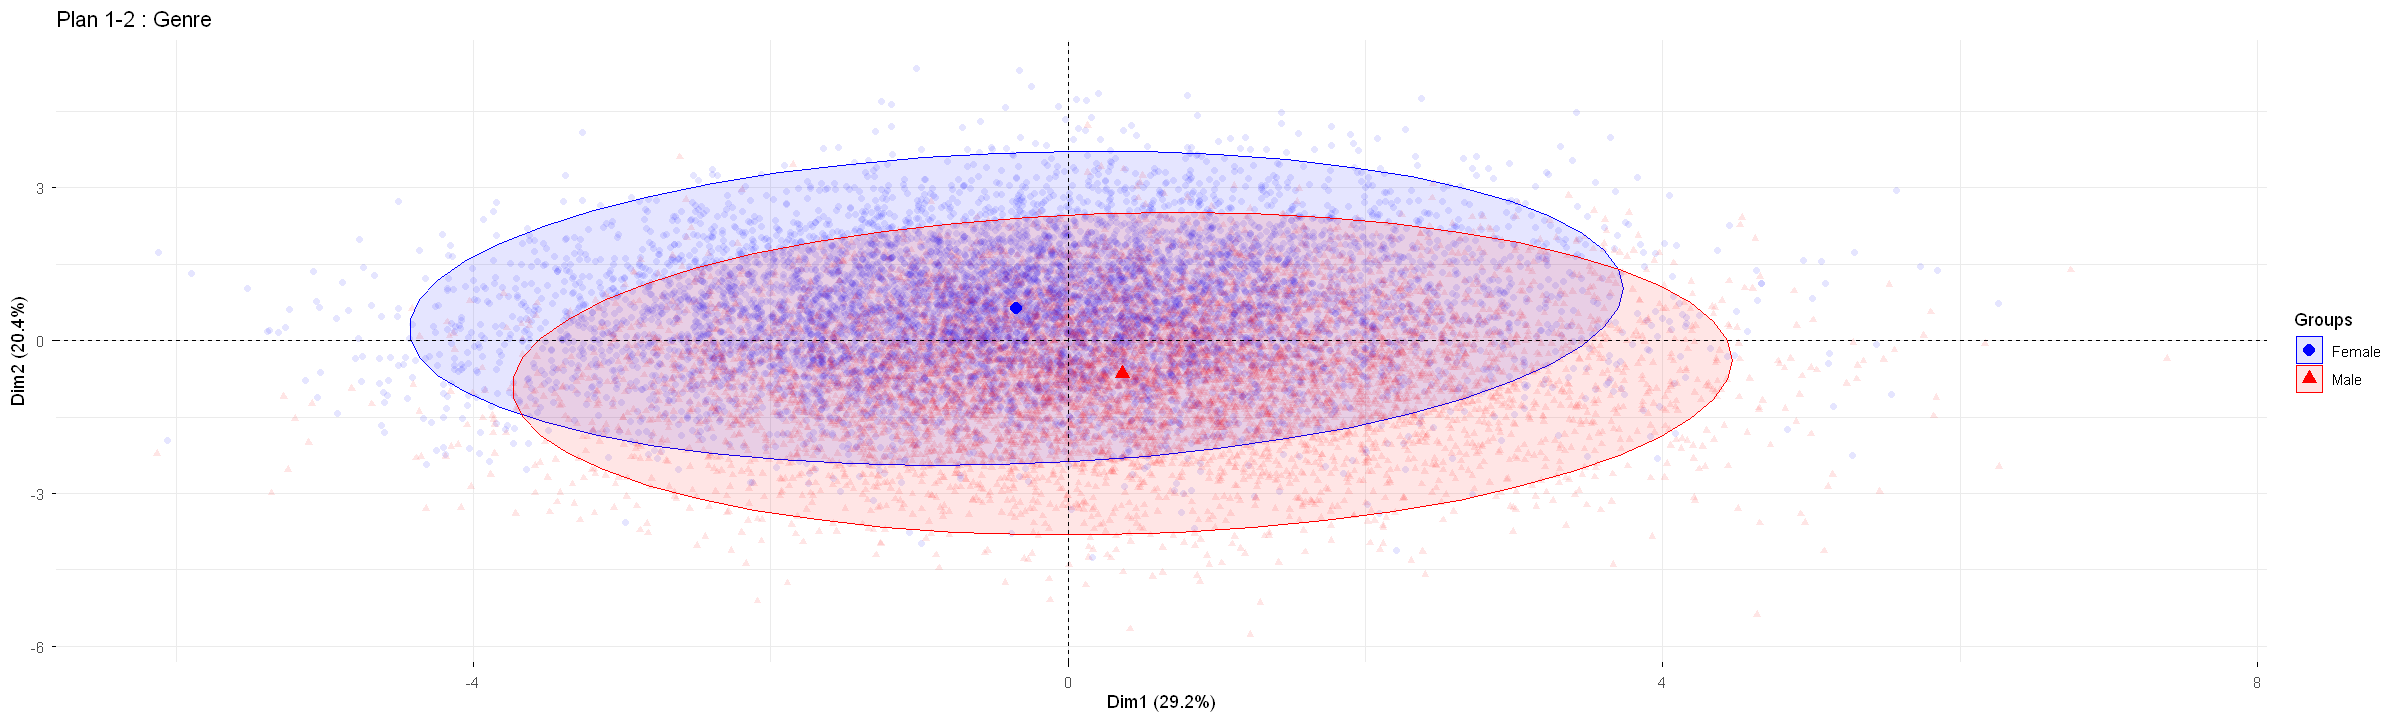

In [25]:

## Plan principal

# Risque Cardiaque 
fviz_pca_ind(res_pca, habillage = data$Heart_Disease_Risk, axes = c(1,2),
             label = "none", alpha.ind = 0.1, palette = c("blue", "red"), addEllipses = TRUE,
             title = "Plan 1-2 : Risque Cardiaque")

# Stress
fviz_pca_ind(res_pca, habillage = data$Stress_Level, axes = c(1,2),
             label = "none", alpha.ind = 0.1, addEllipses = TRUE,
             title = "Plan 1-2 : Niveau de Stress")

# Sommeil

fviz_pca_ind(res_pca, habillage = data$Sleep_Hours, axes = c(1,2),
             label = "none", alpha.ind = 0.1, addEllipses = TRUE,
             title = "Plan 1-2 : Heures de Sommeil")


# Genre
fviz_pca_ind(res_pca, habillage = data$Gender, axes = c(1,2),
             label = "none", alpha.ind = 0.1, palette = c("blue", "red"), addEllipses = TRUE,
             title = "Plan 1-2 : Genre")

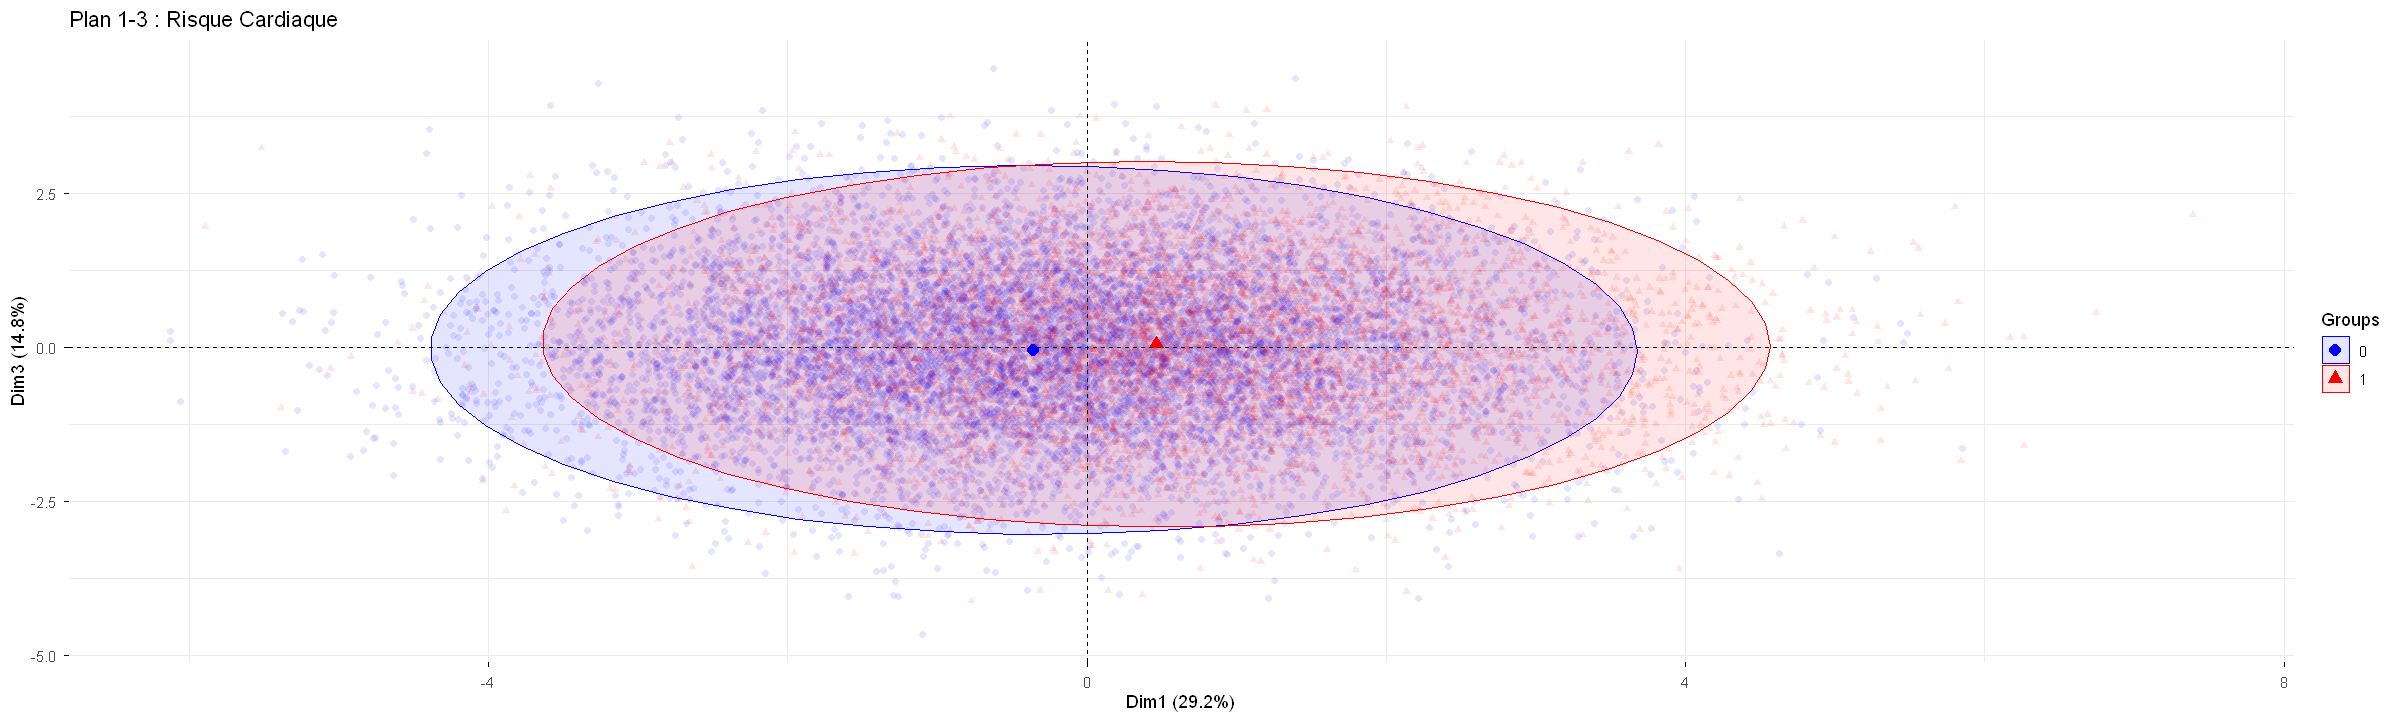

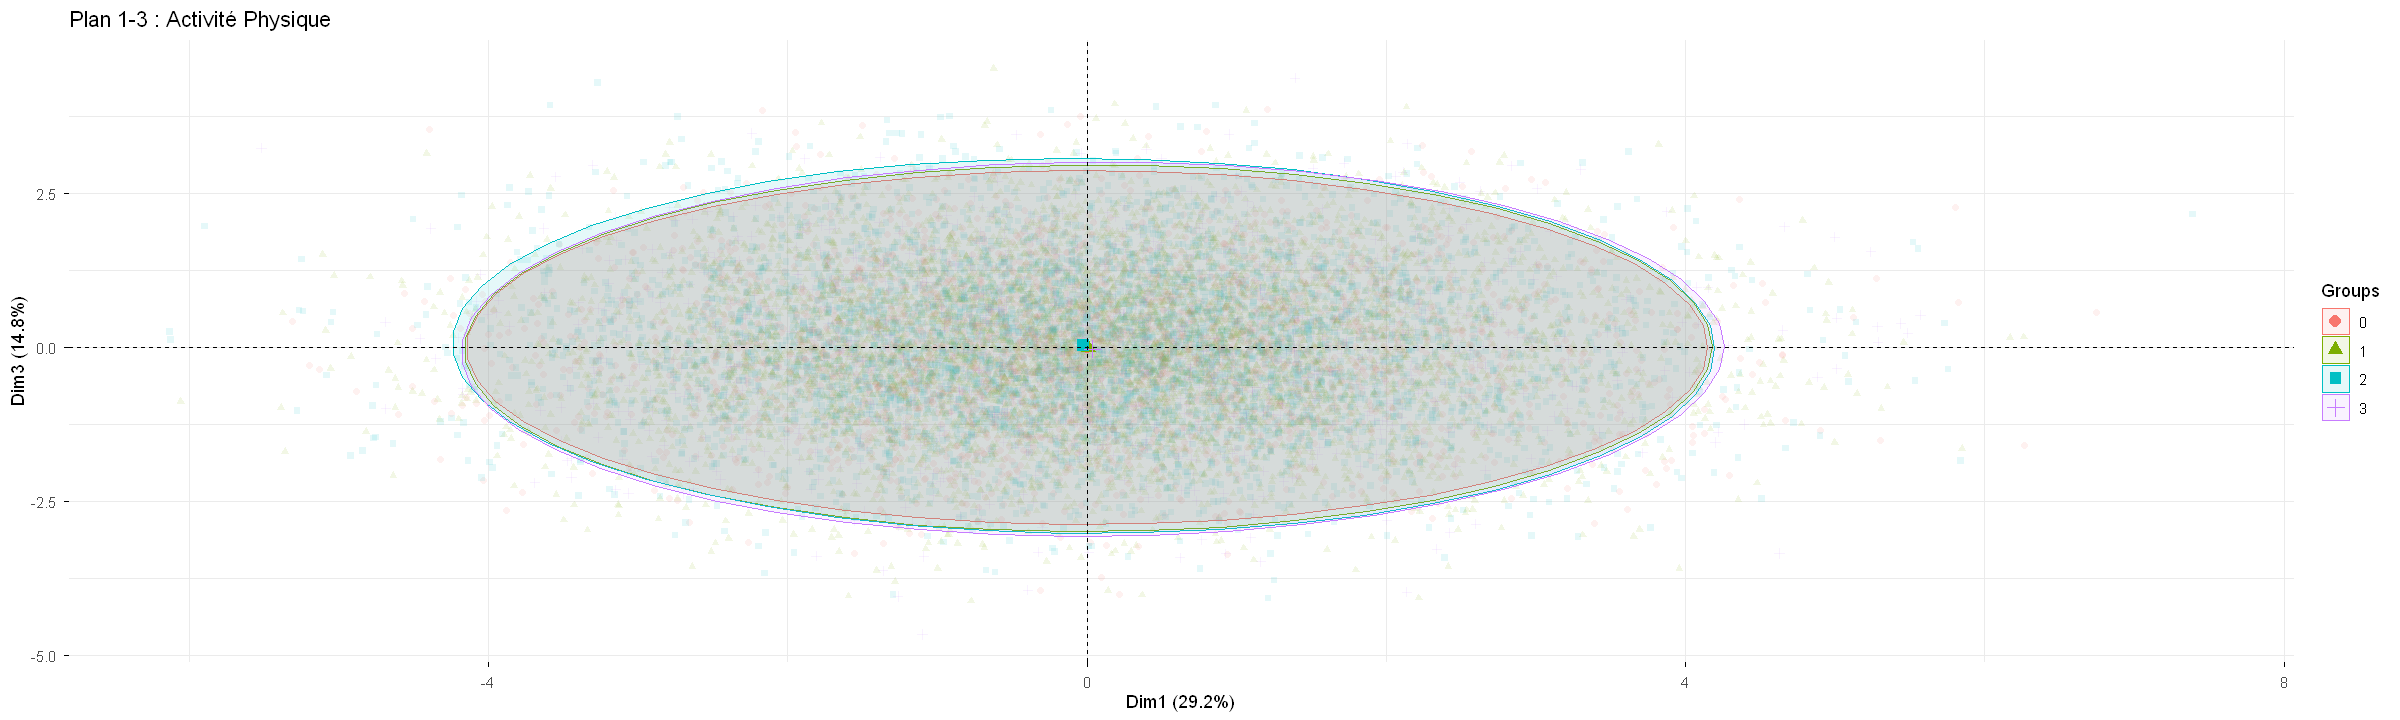

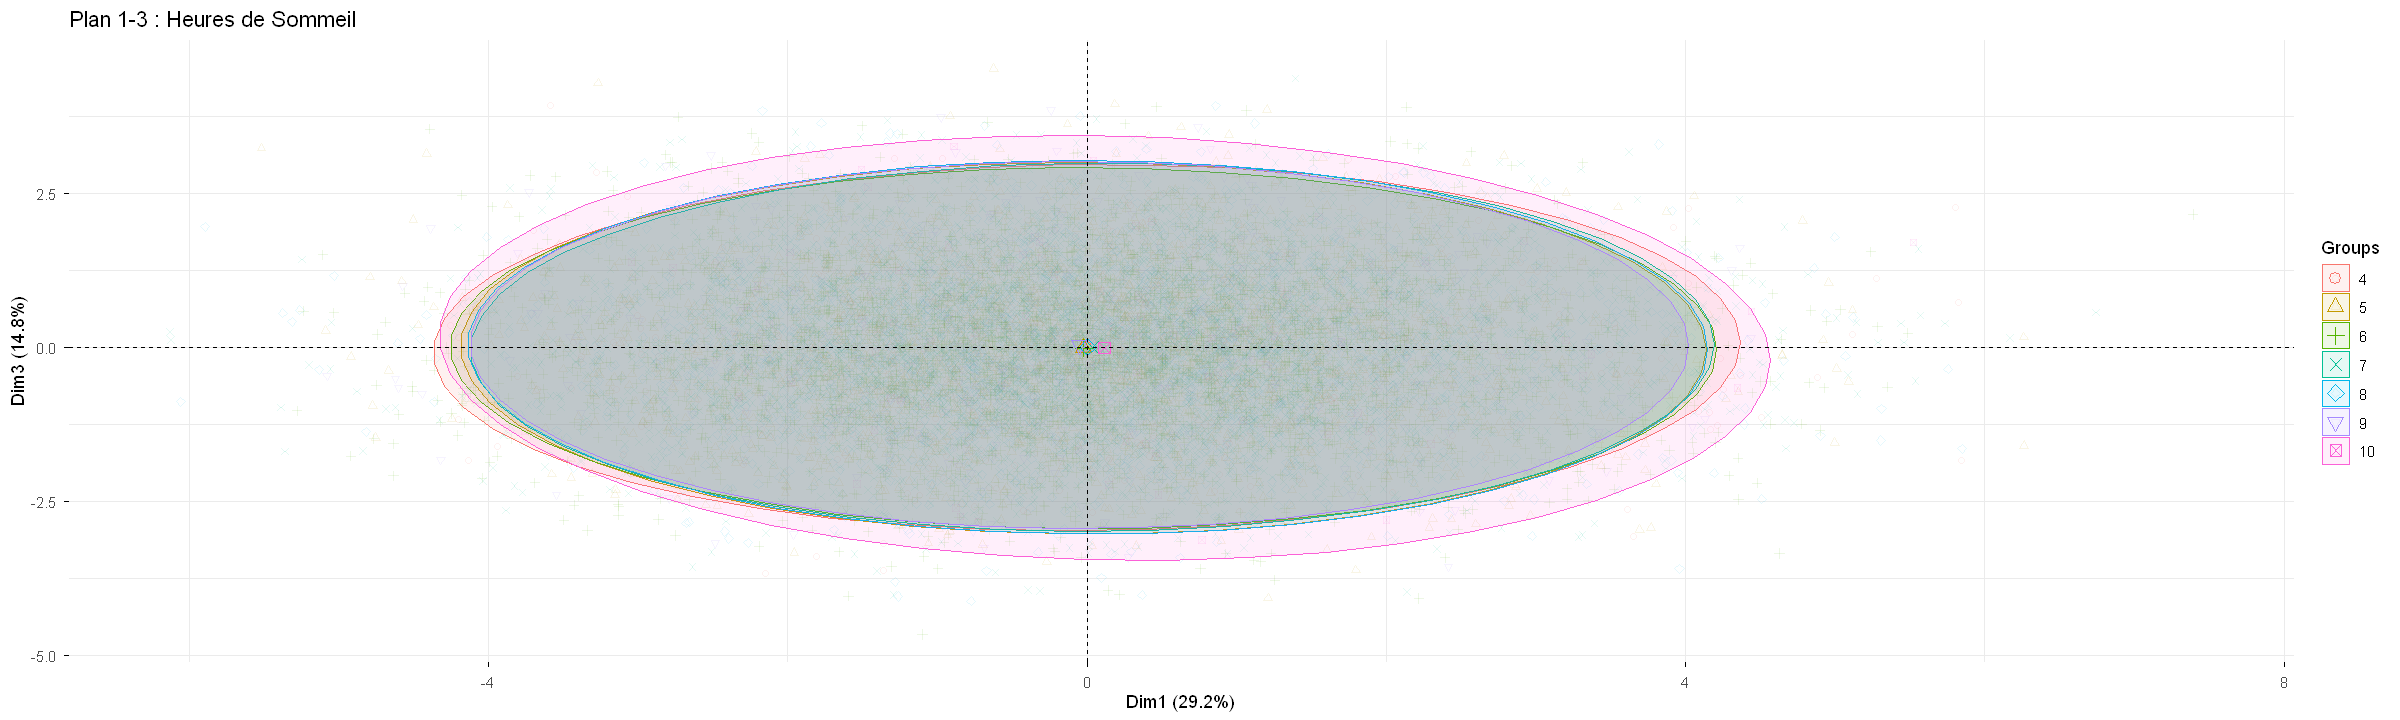

In [26]:
## Plan 1-3

# Risque Cardiaque sur Dim 3
fviz_pca_ind(res_pca, habillage = data$Heart_Disease_Risk, axes = c(1,3),
             label = "none", alpha.ind = 0.1, palette = c("blue", "red"), addEllipses = TRUE,
             title = "Plan 1-3 : Risque Cardiaque")

# Activité Physique sur Dim 3 
fviz_pca_ind(res_pca, habillage = data$Physical_Activity_Level, axes = c(1,3),
             label = "none", alpha.ind = 0.1, addEllipses = TRUE,
             title = "Plan 1-3 : Activité Physique")

# Sommeil sur Dim 3
fviz_pca_ind(res_pca, habillage = data$Sleep_Hours, axes = c(1,3),
             label = "none", alpha.ind = 0.1, addEllipses = TRUE,
             title = "Plan 1-3 : Heures de Sommeil")

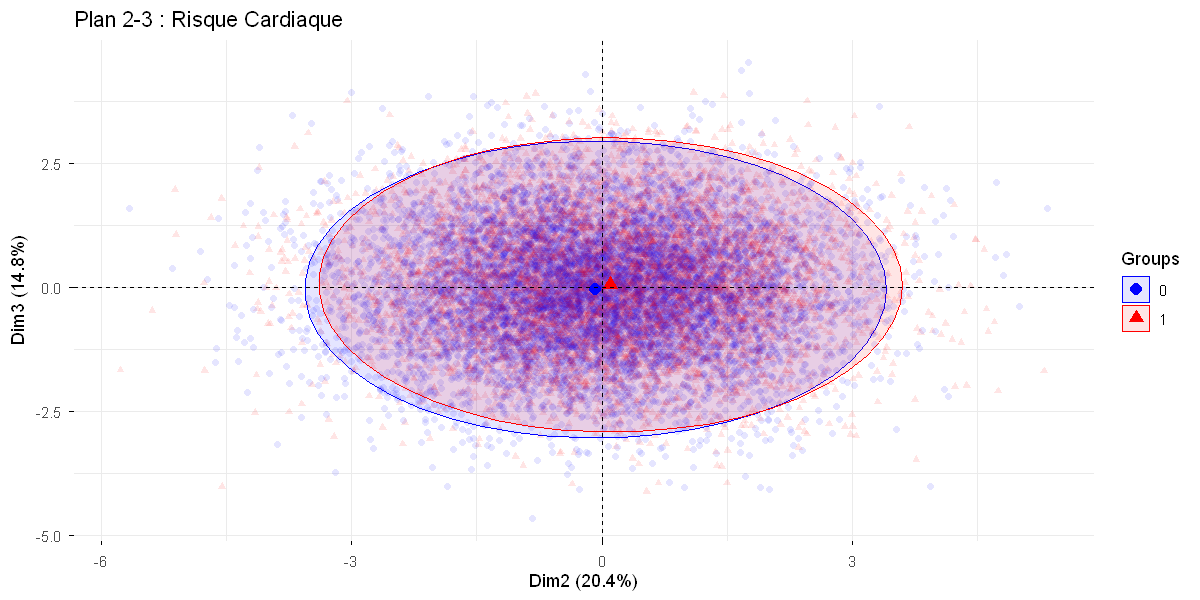

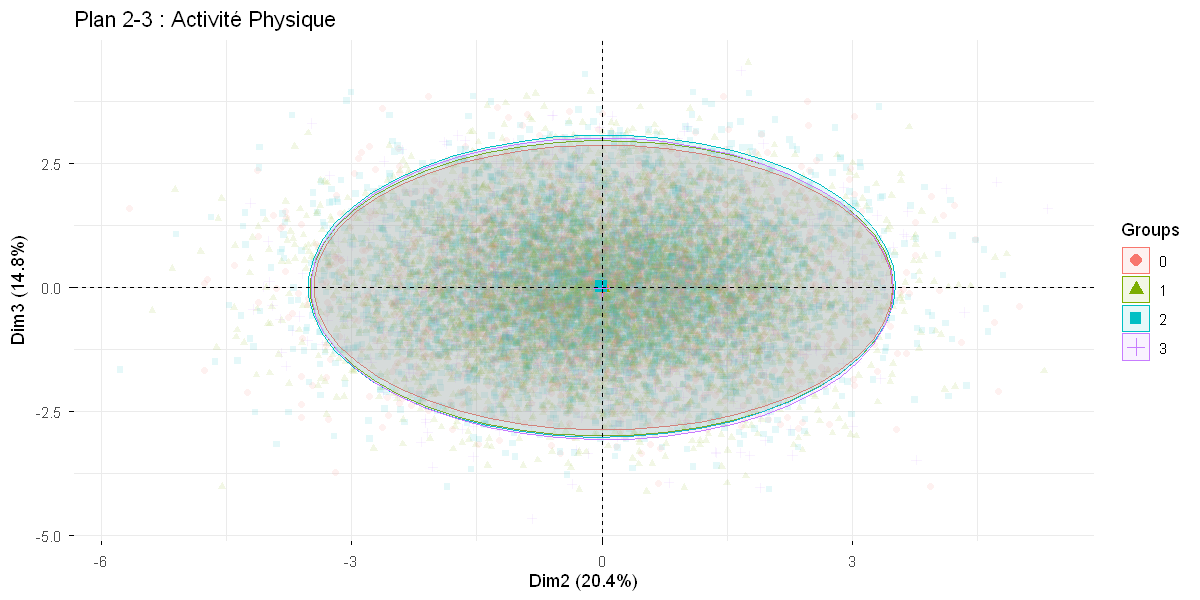

In [ ]:
## Plan 2-3

# Risque Cardiaque sur Dim 2-3
fviz_pca_ind(res_pca, habillage = data$Heart_Disease_Risk, axes = c(2,3),
             label = "none", alpha.ind = 0.1, palette = c("blue", "red"), addEllipses = TRUE,
             title = "Plan 2-3 : Risque Cardiaque")


L'absence de superposition des ellipses signifie que la variable qualitative segmente réellement la population : elle démontre que les groupes possèdent des caractéristiques biologiques distinctes sur ces axes et que cette variable sera donc un prédicteur robuste.

En conclusion, l’ACP a permis de réduire la dimensionnalité de ce jeu de données complexe en identifiant trois leviers de variance indépendants : un pôle biométrique majeur (BMI, tensions), un pôle lipidique (LDL, cholestérol total) et un pôle de facteurs spécifiques (âge, HDL). La projection des variables qualitatives révèle que le risque cardiovasculaire et le niveau de stress sont les facteurs qui segmentent le plus nettement la population, comme en témoigne le décalage des ellipses de confiance sur les premiers plans factoriels. Cette structuration de l’information valide la pertinence des variables sélectionnées et servira de base rigoureuse à la construction de nos modèles prédictifs, en nous permettant de prioriser les variables à fort signal tout en anticipant les problèmes de multicolinéarité.

# 4. Prediction du risque d’accident cardiaque ( variable Heart_Disease_Risk)

## Division du jeu de données en un échantillon d’apprentissage et un échantillon test

Cette étape est essentielle pour évaluer la performance des algorithmes de machine learning. Pour obtenir obtenir des résultats non biaisés, il faut évaluer la qualité des prédictions sur un échantillon de test, indépendant de l'entraînement. On utilise la librairie caret pour une implémentation plus rapide.

In [29]:
library(caret)

In [28]:
set.seed(131)
trainIndex = createDataPartition(data$Heart_Disease_Risk,p=0.8,list = FALSE)
dataTrain0 = data[ trainIndex,]
dataTest0 = data[-trainIndex,]

Il est aussi très important de normaliser les données pour mettre toutes les variables sur la même échelle. Cela évite que les variables ayant de grandes valeurs numériques n'écrasent les variables aux valeurs plus petites.

In [14]:
dataTrain=dataTrain0
dataTrain[,-c(2,8,9,10,11,12,13,14)]=scale(dataTrain0[,-c(2,8,9,10,11,12,13,14)])

# on normalise l'échantillon test avec la moyenne et l'écart type de l'échantillon d'apprentissage
dataTest=dataTest0
dataTest[,-c(2,8,9,10,11,12,13,14)]=scale(dataTest0[,-c(2,8,9,10,11,12,13,14)],
                            center=sapply(dataTrain0[,-c(2,8,9,10,11,12,13,14)],mean), # on centre avec les moyennes de l'échantillon d'apprentissage
                            scale=sapply(dataTrain0[,-c(2,8,9,10,11,12,13,14)],sd)) # on réduit avec les écart-types de l'échantillon d'apprentissage
summary(dataTrain)
summary(dataTest)

      Age              Gender      Systolic_BP        Diastolic_BP     
 Min.   :-2.50056   Female:6126   Min.   :-4.00425   Min.   :-3.62845  
 1st Qu.:-0.64148   Male  :5874   1st Qu.:-0.63600   1st Qu.:-0.66295  
 Median : 0.03455                 Median :-0.01553   Median : 0.04877  
 Mean   : 0.00000                 Mean   : 0.00000   Mean   : 0.00000  
 3rd Qu.: 0.71058                 3rd Qu.: 0.69357   3rd Qu.: 0.64187  
 Max.   : 2.56965                 Max.   : 4.15046   Max.   : 3.48876  
                                                                       
 Cholesterol_Total  Cholesterol_LDL    Cholesterol_HDL    Smoking_Status
 Min.   :-3.71524   Min.   :-3.92744   Min.   :-3.91739   0:8401        
 1st Qu.:-0.67272   1st Qu.:-0.69168   1st Qu.:-0.72723   1:3599        
 Median :-0.01131   Median :-0.02221   Median :-0.05562                 
 Mean   : 0.00000   Mean   : 0.00000   Mean   : 0.00000                 
 3rd Qu.: 0.65011   3rd Qu.: 0.64725   3rd Qu.: 0.61599    

      Age              Gender      Systolic_BP        Diastolic_BP     
 Min.   :-2.50056   Female:1496   Min.   :-3.02923   Min.   :-3.62845  
 1st Qu.:-0.72598   Male  :1504   1st Qu.:-0.72464   1st Qu.:-0.66295  
 Median :-0.04996                 Median :-0.01553   Median :-0.06985  
 Mean   :-0.02241                 Mean   :-0.02552   Mean   :-0.02821  
 3rd Qu.: 0.64720                 3rd Qu.: 0.60493   3rd Qu.: 0.64187  
 Max.   : 2.56965                 Max.   : 3.17544   Max.   : 3.48876  
                                                                       
 Cholesterol_Total   Cholesterol_LDL    Cholesterol_HDL    Smoking_Status
 Min.   :-3.935714   Min.   :-3.87165   Min.   :-3.24577   0:2094        
 1st Qu.:-0.672724   1st Qu.:-0.69168   1st Qu.:-0.72723   1: 906        
 Median :-0.011307   Median :-0.02221   Median :-0.05562                 
 Mean   :-0.001856   Mean   :-0.01197   Mean   :-0.01963                 
 3rd Qu.: 0.650110   3rd Qu.: 0.64725   3rd Qu.: 0.615

## Modèle de régression logistique

Nous cherchons à prédire la variable Heart_Disease_Risk qui est une variable binaire, on utilise donc un modèle linéaire généralisé (régression logistique).

### Modèle sans intéraction entre les variables

In [24]:
# estimation du modèle complet(sans interactions)
reglog = glm(Heart_Disease_Risk ~. , data = dataTrain, family = binomial(link="logit"))
anova(reglog, test = "Chisq")

,Df,Deviance,Resid. Df,Resid. Dev,Pr(>Chi)
,<int>,<dbl>,<int>,<dbl>,<dbl>
NULL,NA,NA,11999,16438.38,NA
Age,1,3.330504e+02,11998,16105.33,2.081636e-74
Gender,1,5.432754e-01,11997,16104.79,4.610785e-01
Systolic_BP,1,2.272832e+02,11996,15877.51,2.332635e-51
Diastolic_BP,1,2.102715e-01,11995,15877.30,6.465547e-01
Cholesterol_Total,1,5.747755e+01,11994,15819.82,3.418599e-14
Cholesterol_LDL,1,1.913292e+01,11993,15800.69,1.219235e-05
Cholesterol_HDL,1,3.189926e+01,11992,15768.79,1.623793e-08
Smoking_Status,1,1.607143e+03,11991,14161.64,0.000000e+00


La commande anova réalise des tests du Chi-deux et permet d'évaluer l'apport de chaque variable à notre modèle. On voit que certaines variables ont des p-valeurs au dessus de 5%. Il est donc important de sélectionner seulement les variable significatives. Pour ce faire nous utilisons le critère AIC.

In [25]:
# Recherche d'un modèle optimal
reglog.stepAIC = step(reglog, direction = "backward")

Start:  AIC=12736.38
Heart_Disease_Risk ~ Age + Gender + Systolic_BP + Diastolic_BP + 
    Cholesterol_Total + Cholesterol_LDL + Cholesterol_HDL + Smoking_Status + 
    Alcohol_Consumption + Physical_Activity_Level + Family_History + 
    Stress_Level + Sleep_Hours + SBMI + SWeight + S_Fasting_Blood_Sugar + 
    L_Height_cm

                          Df Deviance   AIC
- SWeight                  1    12668 12734
- L_Height_cm              1    12668 12734
- Diastolic_BP             1    12669 12735
- SBMI                     1    12669 12735
- Gender                   1    12669 12735
- Cholesterol_Total        1    12669 12735
- Alcohol_Consumption      2    12671 12735
<none>                          12668 12736
- Cholesterol_HDL          1    12674 12740
- Sleep_Hours              6    12697 12753
- Cholesterol_LDL          1    12695 12761
- Age                      1    12744 12810
- Systolic_BP              1    12746 12812
- Stress_Level             9    12865 12915
- S_Fasting_B

In [26]:
anova(reglog.stepAIC,test="Chisq")

,Df,Deviance,Resid. Df,Resid. Dev,Pr(>Chi)
,<int>,<dbl>,<int>,<dbl>,<dbl>
NULL,NA,NA,11999,16438.38,NA
Age,1,333.05045,11998,16105.33,2.081636e-74
Systolic_BP,1,227.16047,11997,15878.17,2.480927e-51
Cholesterol_LDL,1,75.68844,11996,15802.48,3.321459e-18
Cholesterol_HDL,1,30.50806,11995,15771.98,3.324821e-08
Smoking_Status,1,1606.48208,11994,14165.49,0.000000e+00
Physical_Activity_Level,3,386.47507,11991,13779.02,1.882025e-83
Family_History,1,597.14366,11990,13181.88,6.999670e-132
Stress_Level,9,194.27089,11981,12987.60,5.254821e-37


On remarque que la sélection AIC n'a conservé que des variables statistiquement significatives avec des p-valeurs en dessous de 5%. En s'intérressant à la colonne correspondant aux déviances, nous pouvons avoir une idée des variables importantes pour la prédiction du risque cardiaque. Cela met en évidence que le statut tabagique (Smoking_Status) est le facteur le plus déterminant avec une déviance expliquée majeure de 1606,48, suivi par les antécédents familiaux (Family_History) et le niveau d'activité physique (Physical_Activity_Level). À l'inverse, la durée du sommeil (Sleep_Hours) et le cholestérol HDL s'avèrent être les variables qui apportent le moins d'information pour prédire le risque cardiaque dans ce modèle.

In [27]:
#matrice de confusion
table(reglog$fitted.values > 0.5, dataTrain[, "Heart_Disease_Risk"])
table(reglog.stepAIC$fitted.values > 0.5, dataTrain[, "Heart_Disease_Risk"])

       
           0    1
  FALSE 5497 1852
  TRUE  1271 3380

       
           0    1
  FALSE 5497 1847
  TRUE  1271 3385

La comparaison des deux matrices montre que la sélection AIC simplifie efficacement le modèle avec un gain de vrai positifs détéctés. Cependant, ces scores calculés sur l'échantillon d'entraînement ne représentent pas ses performances réelles car ils masquent un risque potentiel de sur-apprentissage.

### Modèles avec intéractions

Nous travaillons avec un grand nombre de variables et donc d'interactions ce qui peut donner des warnings (à cause de divisions par 0) et être long si on essaye d'estimer le modèle avec toutes les interactions possibles. Nous allons donc utiliser deux méthodes qui permettent d'éviter le problème en selectionnant directement les variables et intéractions siginificatives:

- Une procédure stepwise de selection de variable sur critère BIC (car il pénalise plus la complexité du modèle que l'AIC)
- Une pénalisation L1 (LASSO)

**Modèle avec séléction BIC**

In [28]:
reglog.inter = glm(Heart_Disease_Risk ~ 1, data = dataTrain,family = binomial)

reglog.inter.step = step(reglog.inter, direction = "both", k=log(nrow(dataTrain)),
    scope = list(lower = ~1, upper = ~(Age + Gender + L_Height_cm + SWeight + SBMI + Systolic_BP + Diastolic_BP +Cholesterol_Total + Cholesterol_LDL
                                      + Cholesterol_HDL +  S_Fasting_Blood_Sugar + Smoking_Status +  Alcohol_Consumption + Physical_Activity_Level + 
                                       Family_History + Stress_Level + Sleep_Hours)^2)) # On précise le plus grand modèle possible

Start:  AIC=16447.78
Heart_Disease_Risk ~ 1

                          Df Deviance   AIC
+ Smoking_Status           1    14896 14915
+ Family_History           1    15986 16005
+ Systolic_BP              1    15995 16014
+ Age                      1    16105 16124
+ S_Fasting_Blood_Sugar    1    16123 16142
+ Physical_Activity_Level  3    16129 16166
+ Diastolic_BP             1    16158 16177
+ Cholesterol_Total        1    16216 16235
+ Cholesterol_LDL          1    16216 16235
+ SBMI                     1    16246 16264
+ SWeight                  1    16299 16318
+ Stress_Level             9    16292 16386
+ Cholesterol_HDL          1    16386 16404
<none>                          16438 16448
+ L_Height_cm              1    16437 16456
+ Gender                   1    16438 16457
+ Alcohol_Consumption      2    16436 16464
+ Sleep_Hours              6    16418 16484

Step:  AIC=14915.09
Heart_Disease_Risk ~ Smoking_Status

                          Df Deviance   AIC
+ Family_History 

In [29]:
anova(reglog.inter.step, test = "Chisq")

,Df,Deviance,Resid. Df,Resid. Dev,Pr(>Chi)
,<int>,<dbl>,<int>,<dbl>,<dbl>
NULL,NA,NA,11999,16438.38,NA
Smoking_Status,1,1542.08394,11998,14896.30,0.000000e+00
Family_History,1,532.76068,11997,14363.54,7.085177e-118
Systolic_BP,1,497.25419,11996,13866.29,3.761899e-110
Physical_Activity_Level,3,405.42539,11993,13460.86,1.478964e-87
S_Fasting_Blood_Sugar,1,296.84740,11992,13164.01,1.601876e-66
Cholesterol_LDL,1,143.31937,11991,13020.69,5.004986e-33
Stress_Level,9,193.31600,11982,12827.38,8.327198e-37
Age,1,58.32241,11981,12769.05,2.224952e-14


Le fait le plus marquant est que ce modèle a finalement exclu toutes les interactions, ne conservant que des effets principaux. On y retrouve pratiquement les mêmes variables majeures pour la prédiction du risque cardiaque que dans le modèle précédent (Smoking_Status, Family_History, Physical_Activity_Level). On observe cependant une légère modification dans l'ordre d'importance : la pression artérielle systolique (Systolic_BP) s'avère ici plus déterminante que dans le modèle sans interactions initial.

**Régression avec pénalisation L1 (LASSO)**

La régression LASSO est particulièrement adaptée à notre problème puisqu'elle force les coefficients des variables les moins importantes à valoir exactement 0, ce qui permet de réduire le nombre de variables. L'hyperparamètre $\lambda$, qui contrôle la force de cette pénalité, est déterminé par une validation croisée à $k$ blocs. 

Warning message:
"`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the ggfortify package.
  Please report the issue at <https://github.com/sinhrks/ggfortify/issues>."


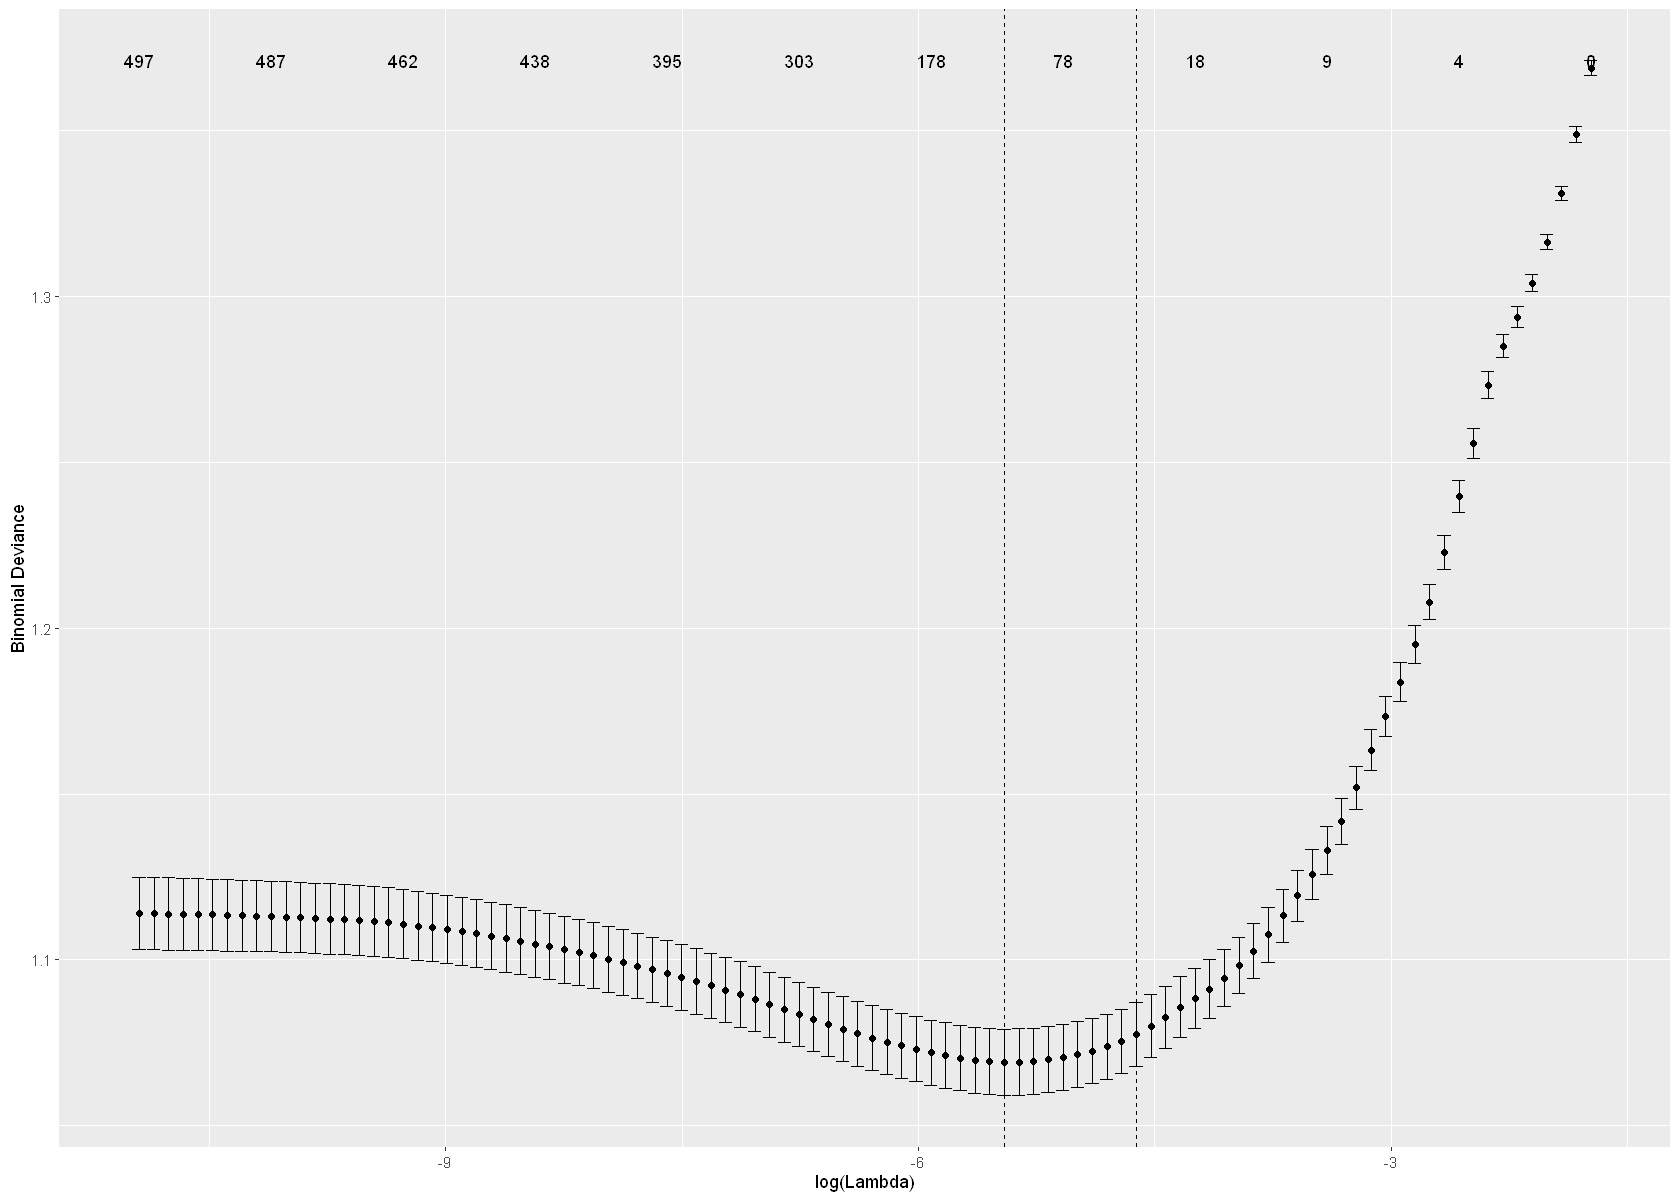

In [30]:
options(repr.plot.width = 14, repr.plot.height = 10)
x.mat = model.matrix(Heart_Disease_Risk~(.)^2-1, data=dataTrain) # permet d'encoder les variables qualitatives et prendre en compte les intéractions
y_train = as.numeric(as.character(dataTrain$Heart_Disease_Risk)) #la fonction cv.glmnet ne prend pas d'objets factors

set.seed(123) #Pour que le découpage des k folds soit toujours le même

reglog.inter.lasso.cv = cv.glmnet(y=y_train, x = x.mat,family="binomial", alpha=1)
autoplot(reglog.inter.lasso.cv)

La ligne pointillée de gauche correspond à la valeur de lambda.min qui donne l'erreur de validation croisée la plus faible. La ligne de pointillé de droite correspond à la valeur de lambda.1se qui donne la plus grande valeur de lambda telle que l'erreur reste à moins d'un écart-type de l'erreur minimale. Cette valeur de lambda donne donc une plus grande pénalisation et donc un modèle plus simple, c'est elle que nous allons utiliser. 

In [31]:
paste("Valeur de lambda estimée :", round(reglog.inter.lasso.cv$lambda.1se, 3)) #round(,3) correspond au nb de décimale après la virgule
# coefficients du modèle correspondant:
coef(reglog.inter.lasso.cv, s = "lambda.1se")

[1] "Valeur de lambda estimée : 0.01"

508 x 1 sparse Matrix of class "dgCMatrix"
                                                 lambda.1se
(Intercept)                                    -0.757799020
Age                                             0.166374348
GenderFemale                                    .          
GenderMale                                      .          
Systolic_BP                                     0.272947738
Diastolic_BP                                    .          
Cholesterol_Total                               .          
Cholesterol_LDL                                 0.137114042
Cholesterol_HDL                                -0.003530418
Smoking_Status1                                 1.708228719
Alcohol_Consumption1                            .          
Alcohol_Consumption2                            .          
Physical_Activity_Level1                       -0.117180106
Physical_Activity_Level2                       -0.574167456
Physical_Activity_Level3                       -0.8573054

On observe bien que beaucoup de coefficients vallent maintenant 0. Nous allons comparer les deux modèles obtenus avec les deux méthodes.

In [32]:
# Variables du modèle par stepAIC
vars_step = names(coef(reglog.inter.step))[-1] # [-1] pour enlever l'intercept

coefs_lasso = coef(reglog.inter.lasso.cv, s = "lambda.1se")
# On garde les noms dont la valeur est différente de 0
vars_lasso = rownames(coefs_lasso)[which(coefs_lasso != 0)][-1] # [-1] pour l'intercept

#Variables communes aux deux modèles
communes = intersect(vars_step, vars_lasso)

# Variables le StepAIC a gardées que le LASSO a supprimées 
step = setdiff(vars_step, vars_lasso)

# Variables le LASSO a gardées que le StepAIC a supprimées 
lasso = setdiff(vars_lasso, vars_step)

paste("Nombre de variables communes:",length(communes))
paste("Nombre de variables uniquement dans le modèle stepAIC:",length(step))
paste("Nombre de variables uniquement dans le modèle LASSO:",length(lasso))

[1] "Nombre de variables communes: 15"

[1] "Nombre de variables uniquement dans le modèle stepAIC: 4"

[1] "Nombre de variables uniquement dans le modèle LASSO: 20"

La comparaison entre les deux modèles montre qu'ils s'accordent sur les 15 variables majeures pour prédire le risque cardiaque. On voit que le critère BIC pénalise plus le nombre de variables que LASSO qui en garde 20 de plus (notamment des interactions).

### Prévision sur l'échantillon test

Dans cette partie nous allons comparer les modèles suivants: 
- Le modèle sélectionné avec le critère AIC (reglog.stepAIC)
- Le modèle sélectionné avec le critère BIC (reglog.inter.step)
- Le modèle avec interactions LASSO (reglog.inter.lasso.cv)

Nous évaluons d'abord les performances avec les matrices de confusion sur l'échantillon de test.

In [ ]:
#Prévision modèle sans interaction avec selection de variable
pred.log.stepAIC <- predict(reglog.stepAIC, newdata = dataTest, type = "response")
#Prévision modèle avec interaction par stepAIC
pred.log.stepBIC <- predict(reglog.inter.step, newdata = dataTest, type = "response")
#Prévision modèle avec interaction par lasso
x.mat.test = model.matrix(Heart_Disease_Risk~(.)^2-1, data=dataTest)
pred.log.inter.lasso <- predict(reglog.inter.lasso.cv, newx = x.mat.test, type = "response")


table.AIC <- table(pred.log.stepAIC > 0.5, dataTest[, "Heart_Disease_Risk"])
table.BIC <- table(pred.log.stepBIC  > 0.5, dataTest[, "Heart_Disease_Risk"])
table.lasso <- table(pred.log.inter.lasso > 0.5, dataTest[, "Heart_Disease_Risk"])

cat("Matrice de confusion du modèle obtenu via AIC:")
print(table.AIC)
cat("Matrice de confusion du modèle obtenu via BIC:")
print(table.BIC)
cat("Matrice de confusion du modèle LASSO:")
print(table.lasso)

Matrice de confusion du modèle obtenu via AIC:       
           0    1
  FALSE 1384  469
  TRUE   308  839
Matrice de confusion du modèle obtenu via BIC:       
           0    1
  FALSE 1391  476
  TRUE   301  832
Matrice de confusion du modèle LASSO:       
           0    1
  FALSE 1385  500
  TRUE   307  808


Dans le cadre de la prédiction d'un risque cardiaque, rater un patient à risque (faux négatif) est plus grave que de générer une fausse alerte (faux positif). On va donc afficher la sensibilité des modèles qui (le pourcentage d'individus à risque que le modèle a réussi à détecter).

In [133]:
se_reglog.AIC <- table.AIC["TRUE", "1"] / sum(table.AIC[, "1"])
se_reglog.BIC <- table.BIC["TRUE", "1"] / sum(table.BIC[,"1" ])
se_reglog.inter.lasso <- table.lasso["TRUE", "1"] / sum(table.lasso[,"1"])

cat("Sensibilité modèle sans interaction via AIC:", round(se_reglog.AIC * 100, 2), "%\n")
cat("Sensibilité modèle sans interaction via BIC:", round(se_reglog.BIC * 100, 2), "%\n")
cat("Sensibilité modèle avec interactions (LASSO) :", round(se_reglog.inter.lasso * 100, 2), "%\n")

Sensibilité modèle sans interaction via AIC: 64.14 %
Sensibilité modèle sans interaction via BIC: 63.61 %
Sensibilité modèle avec interactions (LASSO) : 61.77 %


Les modèles sans interactions ont des performances très proches et un peu au dessus du modèle avec intercations via LASSO. Cela s'explique par le fait que la procédure BIC n'a finalement retenu aucune interaction entre les variables. Au bout du compte, la seule différence entre le modèle via BIC et le modèle via AIC réside dans le nombre de variables conservées (9 pour le BIC contre 11 pour l'AIC).

Nous étudions maintenant les courbes ROC.

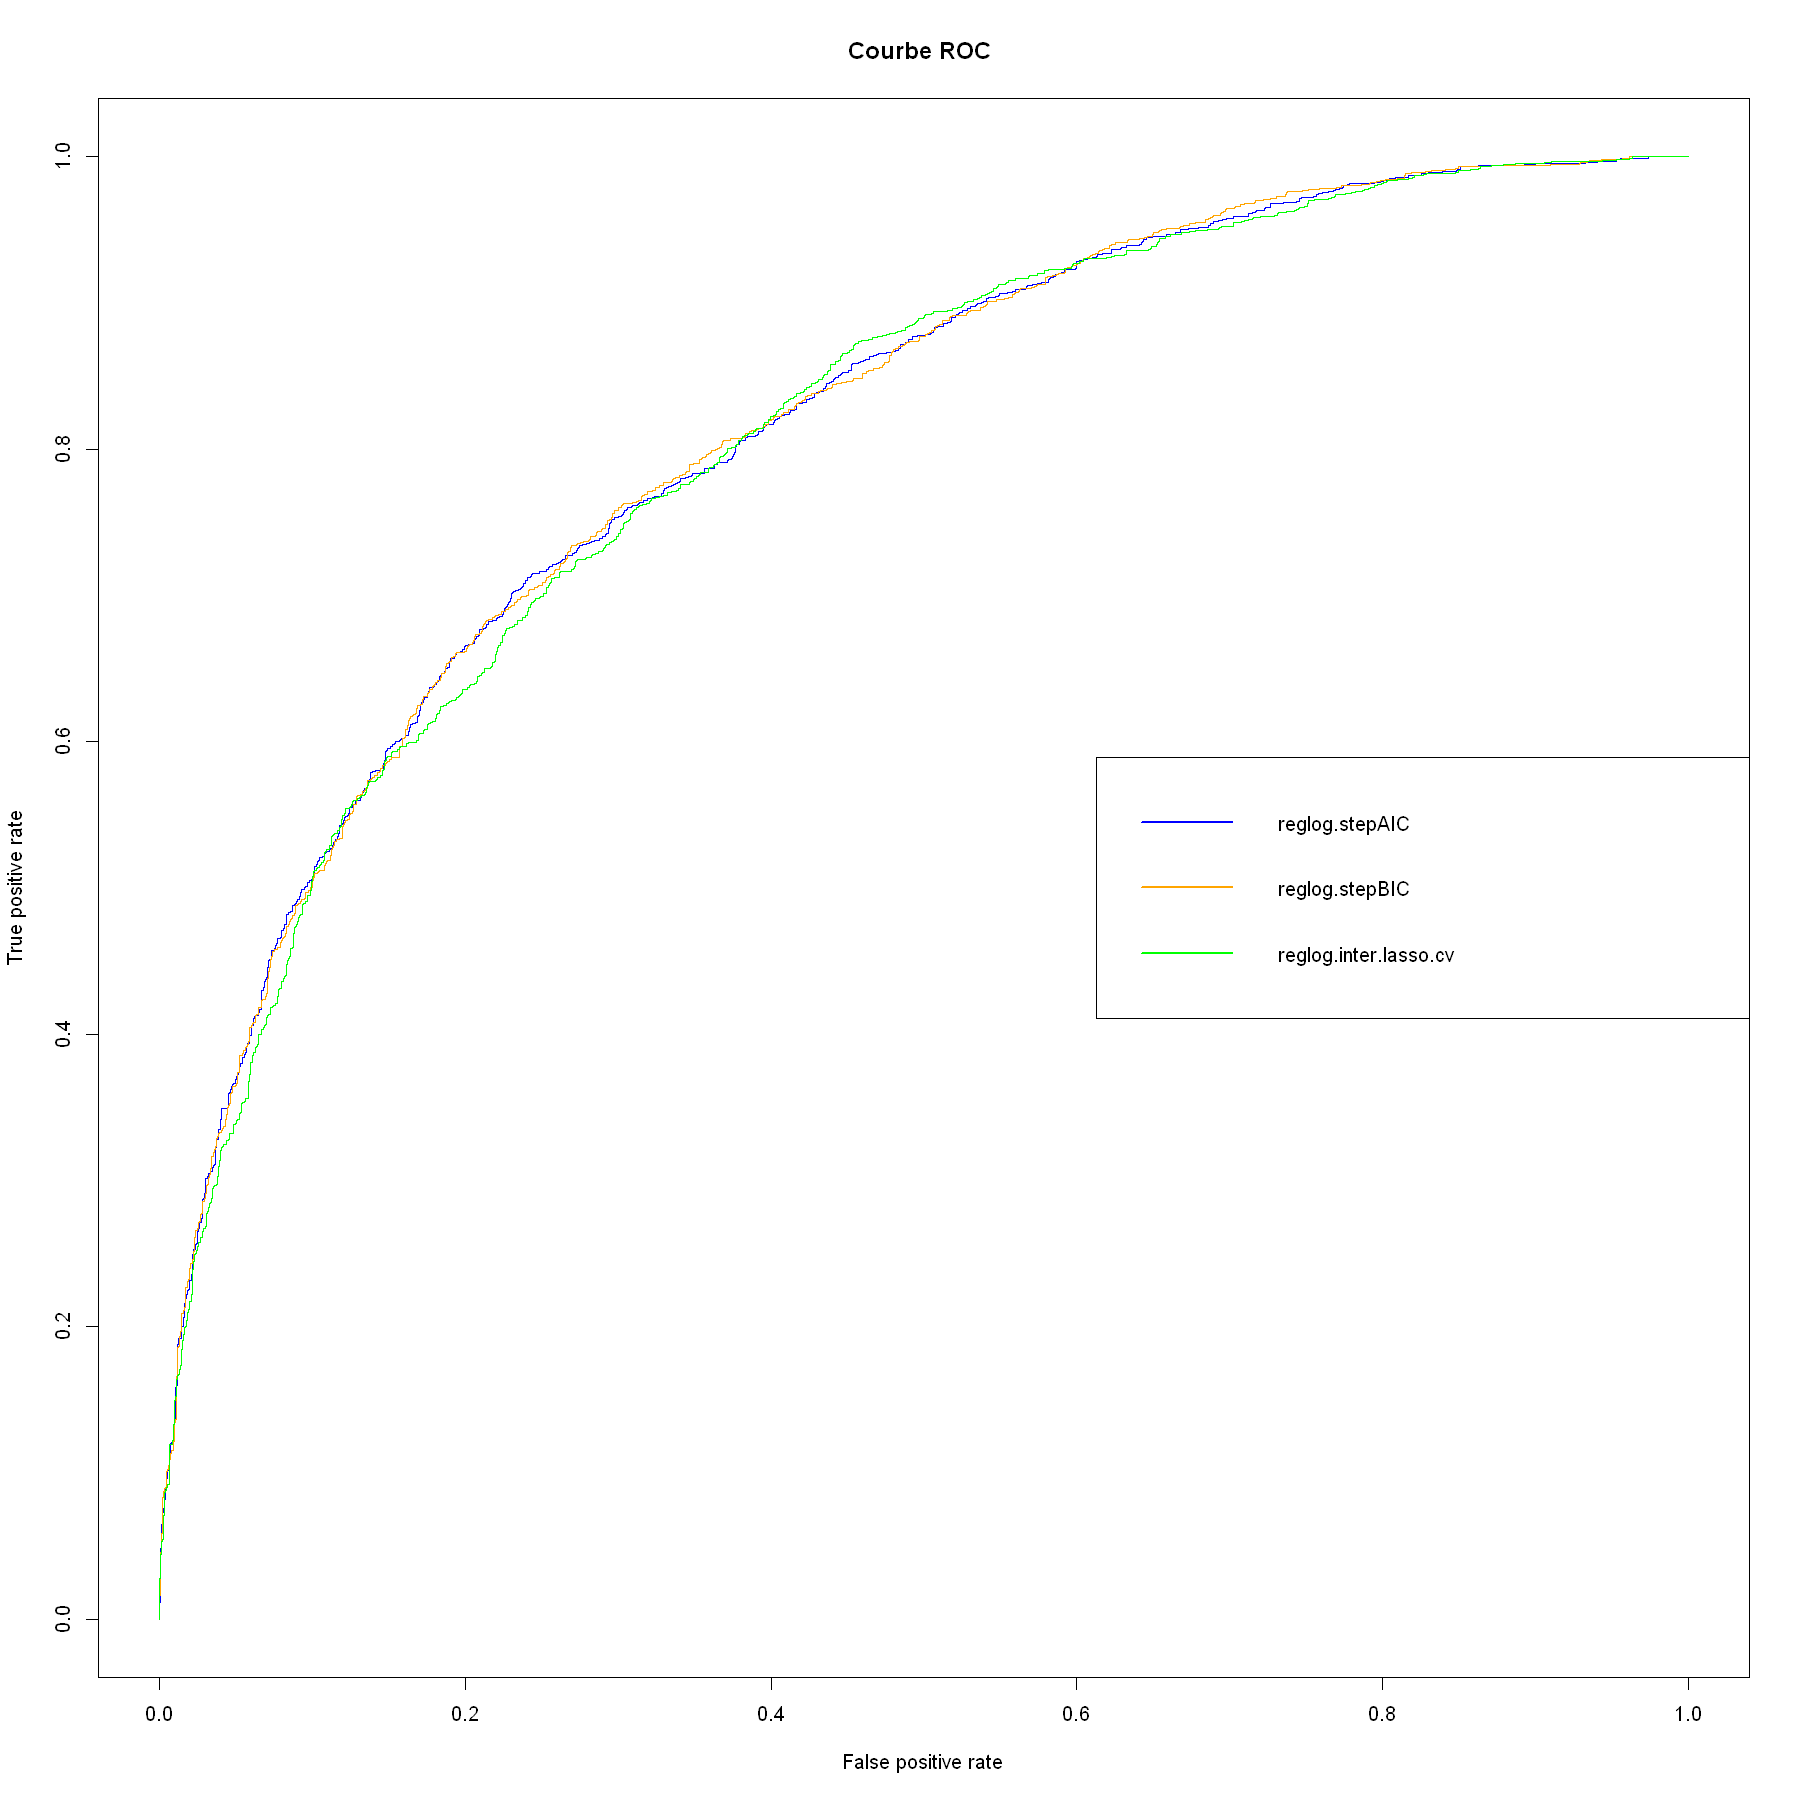

In [121]:
options(repr.plot.width = 15, repr.plot.height = 15)


#Prévision modèle sans interaction avec selection de variable
predlogit.AIC<- prediction(pred.log.stepAIC, dataTest[, "Heart_Disease_Risk"])
perflogit.AIC <- performance(predlogit.AIC, "tpr", "fpr")

#Prévision modèle avec interaction par BIC
predlogit.BIC <- prediction(pred.log.stepBIC, dataTest[, "Heart_Disease_Risk"])
perflogit.BIC <- performance(predlogit.BIC, "tpr", "fpr")

#Prévision modèle avec interaction par lasso
predlogit.inter.lasso <- prediction(pred.log.inter.lasso, dataTest[, "Heart_Disease_Risk"])
perflogit.inter.lasso <- performance(predlogit.inter.lasso, "tpr", "fpr")

plot(perflogit.AIC,col="blue", main = "Courbe ROC ")
plot(perflogit.BIC,col="orange",add=TRUE) 
plot(perflogit.inter.lasso,col="green",add=TRUE) 

legend("right", legend=c( "reglog.stepAIC", "reglog.stepBIC","reglog.inter.lasso.cv"),
       col=c("blue","orange","green"), lwd = 2)


Les trois courbes ROC sont quasiment confondues, ce qui montre que les performances globales des modèles sont très proches sur l'échantillon de test. On remarque toutefois que la courbe du LASSO (en vert) est légèrement en dessous des autres. Cela confirme que l'ajout d'interactions n'apporte rien.

Au final nous choisissons de retenir le modèle le moins complexe (celui obtenu avec la procédure BIC) pour la comparaison finale avec les autres modèles à la fin de cette partie sur la prédiction du risque cardiaque.

## Support Vector Machine (SVM)

Le modèle SVM permet de construire un hyperplan de séparation optimal qui sépare au mieux les observations en deux classes. Il est possible d'utiliser plusieurs noyaux qui vont déterminer la forme géométrique de cette frontière de séparation. Dans le cadre de cette étude, nous nous limiterons à la comparaison de trois noyaux principaux : linéaire, polynomial et gaussien, afin d'identifier celui qui s'ajuste le mieux à nos données.

Le coût est le paramètre de régularisation qui détermine la tolérance du modèle face aux observations mal classées :

- Un coût faible autorise des erreurs de classement pour privilégier une marge plus large et un modèle plus simple.

- Un coût élevé pénalise sévèrement chaque mauvaise classification, ce qui force le modèle à créer une frontière étroite et complexe pour classer parfaitement les points d'entraînement (risque de sur-apprentissage).

Nous calibrons ce paramètre par validation croisée à 5 folds grâce à la méthode du grid search (via la fonction tune.svm) pour chaque noyau. Enfin, certains noyaux possèdent leurs propres hyperparamètres spécifiques (comme gamma pour le noyau gaussien ou degree pour le polynomial) qu'il convient également d'estimer simultanément par cette méthode. Afin de réduire davantage le temps d'exécution des recherches, ces validations croisées sont réalisées sur un sous-échantillon représentatif de 3 000 individus, extrait de manière aléatoire des 12 000 observations de notre jeu d'apprentissage. Une fois ces hyperparamètres optimaux identifiés, les modèles finaux sont entraînés sur l'intégralité du jeu d'entraînement.


In [31]:
library(e1071)

In [16]:
#Création du sous-échantillon pour la recherche des paramètres optimaux
set.seed(123) 

lignes_tuning <- sample(1:nrow(dataTrain), size = 3000)
dataTrain_tuning <- dataTrain[lignes_tuning, ]

### Noyau linéaire

Le noyau linéaire cherche un hyperplan plan droit pour séparer les classes directement dans l'espace d'origine. Il ne possède aucun hyperparamètre spécifique supplémentaire en dehors du coût (cost). Nous avons d'abord testé une échelle large avec les valeurs ($0.1, 1, 10$), ce qui a donné une valeur optimale de $C=10$. Nous avons donc décider d'élargir notre recherche en testant des valeurs supérieures (jusqu'à $C = 20$).

In [83]:
set.seed(123)
svm.linear.tune = tune.svm(Heart_Disease_Risk ~ ., data = dataTrain_tuning, kernel = "linear",
                           cost = c(10,15,20),
                           tunecontrol = tune.control(cross = 5))
print(svm.linear.tune$best.parameters)

  cost
2   15


La validation croisée a finalement convergé vers un coût optimal de 15. Nous allons donc entraîner le modèle final avec ce paramètre là.

In [84]:
#Entraînement avec les paramètres optimaux
svm.linear.best = svm(Heart_Disease_Risk ~ ., data = dataTrain, kernel = "linear",
                      cost = svm.linear.tune$best.parameters$cost,
                      probability = TRUE) #probability =TRUE pour la courbe ROC finale

### Noyau polynomial

Le noyau polynomial modélise des relations non linéaires sous forme de courbes (paraboliques, cubiques, etc.). Il nécessite de calibrer deux hyperparamètres additionnels: le degré du polynôme (degree) et la constante de décalage (coef0).

Nous fixons la plage du paramètre degree à $2$ et $3$. Le degré 2 permet d'explorer des formes quadratiques tandis que le degré 3 apporte la flexibilité des formes cubiques sans être trop complexe et mener au sur-ajustement.

Pour le paramètre coef0, nous essayons une large plage: $-5, -1, 0, 1, 5$. 

Concernant le paramètre de coût, notre démarche à été itérative. Nous avions initialement testé la même échelle large que pour le noyau linéaire ($0.1, 1, 10$). Cependant, le modèle optimal obtenait une valeur de $0.01$, nous avons donc choisi d'élargir la fenêtre de recherche en y intégrant la valeur de $0.01$.

In [85]:
set.seed(123)
svm.poly.tune = tune.svm(Heart_Disease_Risk ~ ., data = dataTrain_tuning, kernel = "polynomial",
                         cost = c(0.01, 0.1, 1, 10),
                         degree = c(2, 3),               # On teste les degrés 2 et 3
                         coef0 = c(-5, -1, 0, 1, 5),          
                         tunecontrol = tune.control(cross = 5))

print(svm.poly.tune$best.parameters)

   degree coef0 cost
20      3     5  0.1


Au final, le modèle polynomial optimal privilégie une frontière de séparation cubique (degré 3), associée à un paramètre de coût modéré (cost = 0.1) qui lui donne une flexibilité quant à la marge de tolérance aux erreurs. De plus, la valeur élevée du paramètre coef0 = 5 indique qu'un fort décalage positif de la frontière dans l'espace des caractéristiques.

In [86]:
# Entraînement final
set.seed(123)
svm.poly.best = svm(Heart_Disease_Risk ~ ., data = dataTrain, kernel = "polynomial",
                    cost = svm.poly.tune$best.parameters$cost, 
                    degree = svm.poly.tune$best.parameters$degree,
                    coef0 = svm.poly.tune$best.parameters$coef0,
                    probability = TRUE)

### Noyau gaussien

Le noyau gaussien permet de créer des frontières de décision plus flexibles. En plus du coût, il introduit l'hyperparamètre gamma, qui contrôle le rayon d'influence de chaque vecteur support.

En R, la valeur par défaut de gamma est fixée à $\frac{1}{p}$ (où $p$ est le nombre de variables de notre jeu de données). Pour notre étude, nous avons $p=17$ ce qui fait une valeur par défaut de $0.06$ environ. Nous choisissons donc de tester une séquence fine allant de $0.02$ à $0.1$. 

In [81]:
set.seed(123)
svm.gauss.tune = tune.svm(Heart_Disease_Risk ~ ., data = dataTrain_tuning, kernel = "radial",
                          cost = c(0.1, 1, 10), 
                          gamma = seq(0.02, 0.1, by = 0.02))

print(svm.gauss.tune$best.parameters)

  gamma cost
7  0.04    1


Pour le noyau gaussien, l'optimisation par validation croisée retient comme paramètres optimaux une valeur de gamma = 0.04, associée à un coût cost = 1.

In [82]:
#Entraînement du meilleur modèle Gaussien
svm.gauss.best = svm(Heart_Disease_Risk ~ ., data = dataTrain, kernel = "radial",
                     cost = svm.gauss.tune$best.parameters$cost, 
                     gamma = svm.gauss.tune$best.parameters$gamma,
                     probability = TRUE)

### Matrices de confusion pour chaque modèle

In [87]:
# 1. Prédictions des classes pour chaque modèle
classes.gauss  = predict(svm.gauss.best, newdata = dataTest)
classes.poly   = predict(svm.poly.best, newdata = dataTest)
classes.linear = predict(svm.linear.best, newdata = dataTest)

table.gauss= table(classes.gauss,dataTest$Heart_Disease_Risk)
table.poly= table(classes.poly,dataTest$Heart_Disease_Risk)
table.linear=table(classes.linear,dataTest$Heart_Disease_Risk)

cat("Matrice de confusion du SVM au noyau gaussien\n")
print(table.gauss)

cat("\nMatrice de confusion du SVM au noyau polynomial\n")
print(table.poly)

cat("\nMatrice de confusion du SVM au noyau linéaire\n")
print(table.linear)

Matrice de confusion du SVM au noyau gaussien
             
classes.gauss    0    1
            0 1361  500
            1  331  808

Matrice de confusion du SVM au noyau polynomial
            
classes.poly    0    1
           0 1355  497
           1  337  811

Matrice de confusion du SVM au noyau linéaire
              
classes.linear    0    1
             0 1369  491
             1  323  817


L'analyse des matrices de confusion montre des performances globales assez proches entre les trois types de SVM. Quand on s'intérresse plus en détail au nombre de faux négatifs, le noyau linéaire se montre le plus performant et le plus sécurisant en ratant 491 patients, contre 500 pour le noyau gaussien et 497 pour le noyau polynomial.

### Comparaison des courbes ROC

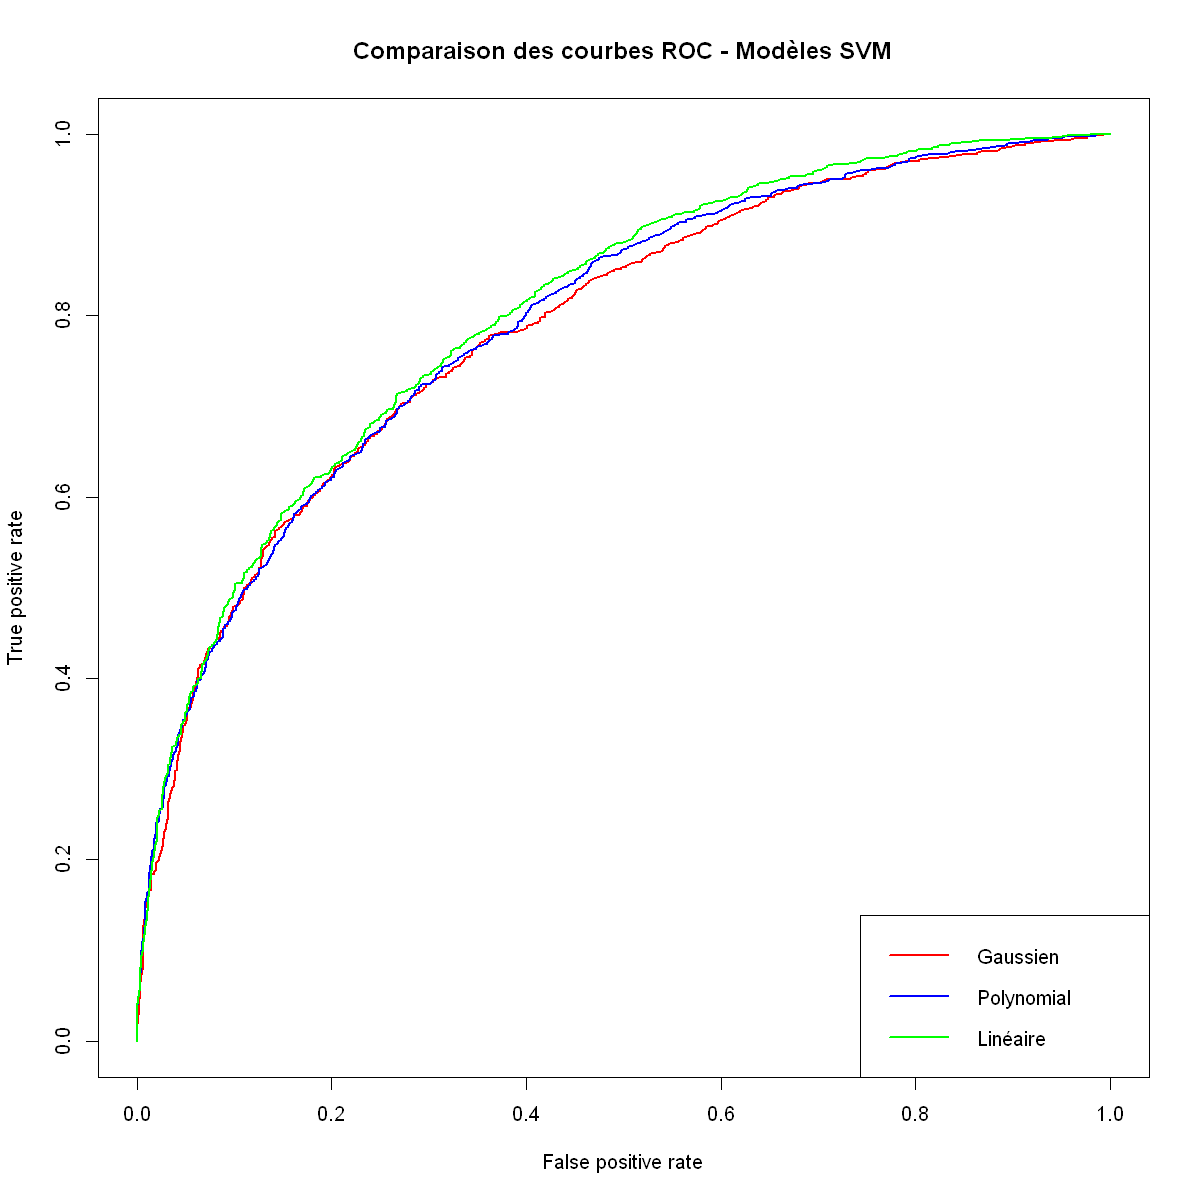

In [ ]:
options(repr.plot.width = 10, repr.plot.height = 10)
pred.gauss = predict(svm.gauss.best, newdata = dataTest, probability = TRUE)
prob.gauss = attr(pred.gauss, "probabilities")[, "1"] # Récupère la proba d'être malade (1)

pred.poly = predict(svm.poly.best, newdata = dataTest, probability = TRUE)
prob.poly = attr(pred.poly, "probabilities")[, "1"]

pred.linear = predict(svm.linear.best, newdata = dataTest, probability = TRUE)
prob.linear = attr(pred.linear, "probabilities")[, "1"]


pred_obj.gauss = prediction(prob.gauss, dataTest$Heart_Disease_Risk)
perf.gauss     = performance(pred_obj.gauss, "tpr", "fpr")

pred_obj.poly  = prediction(prob.poly, dataTest$Heart_Disease_Risk)
perf.poly      = performance(pred_obj.poly, "tpr", "fpr")

pred_obj.linear = prediction(prob.linear, dataTest$Heart_Disease_Risk)
perf.linear     = performance(pred_obj.linear, "tpr", "fpr")


plot(perf.gauss, col = "red", lwd = 2, main = "Comparaison des courbes ROC - Modèles SVM")
plot(perf.poly, col = "blue", lwd = 2, add = TRUE)
plot(perf.linear, col = "green", lwd = 2, add = TRUE)

legend("bottomright", 
       legend = c("Gaussien", "Polynomial", "Linéaire"), 
       col = c("red", "blue", "green"), 
       lwd = 2)

Les courbes ROC confirment visuellement les conclusions tirées des matrices de confusion: bien que les trajectoires des trois modèles soient proches, la courbe du noyau linéaire (en vert) se situe quasi systématiquement au-dessus des autres, sembkant ainsi avoir une aire sous la courbe légèrement plus grande.

## Arbres binaires

Nous allons maintenant prédire le risque cardiaque avec des arbres de classification. Cette méthode repose sur deux hyperparamètres que nous devons calibrer:

- Le critère de division: ce sont les mesures d'hétérogénéité des noeuds enfants que l'on cherche à minimiser. Nous testerons le critère par défaut, l'indice de Gini, et le comparerons au critère d'information (basé sur l'entropie croisée).
- Le paramètre de complexité ($cp$): il permet de réguler la taille d'un arbre. Pour qu'une nouvelle division soit acceptée, elle doit faire baisser le taux de bien classés d'une valeur supérieure à $cp$. Pour trouver la valeur optimale de cp, nous utilisons une validation croisée à 10-folds sur une grille de 20 valeurs. La librairie *caret* sélectionne automatiquement le cp qui maximise le taux de bien classés (Accuracy) sur les données d'apprentissage. Cela nous permet d'obtenir directement un arbre final élagué et performant.

**Optimisation de l'arbre par le critère de Gini**

In [35]:
library(rpart.plot)

[1] "Valeur de cp retenue = 0.00099388379204893"
La variable à la racine est : Smoking_Status1

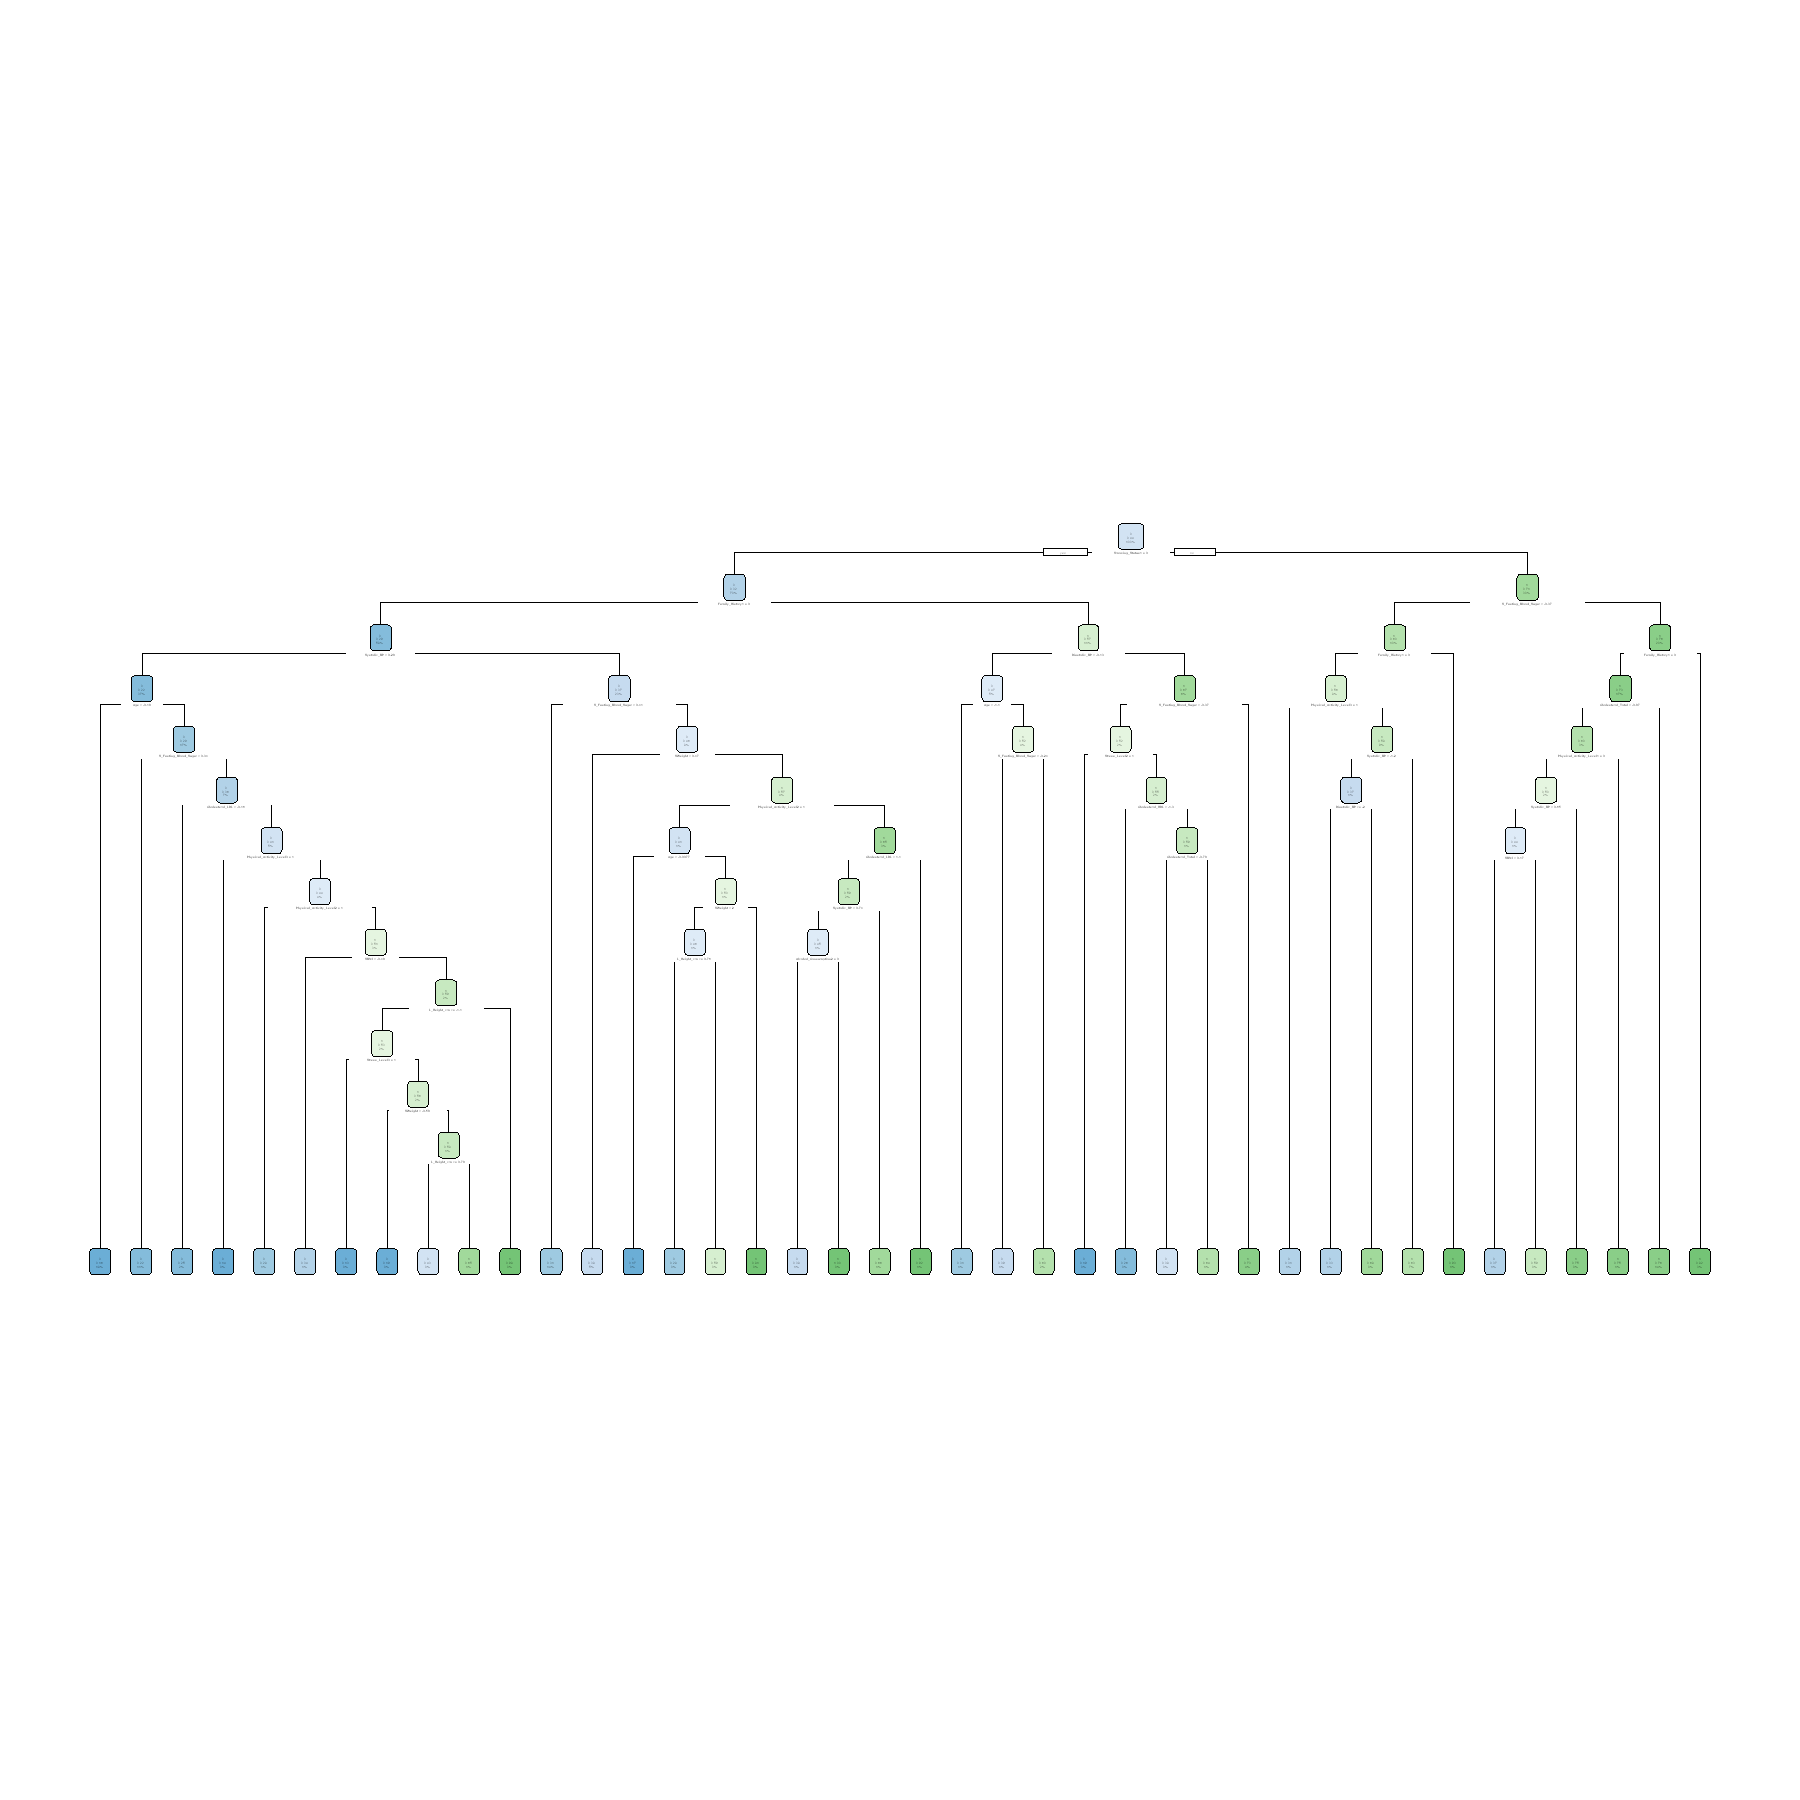

In [41]:
set.seed(123)
ctrl <- trainControl(method = "cv",number = 10) #folds de la validation croisée
tree.gini <- train(Heart_Disease_Risk~.,data=dataTrain,method = "rpart",trControl = ctrl,tuneLength =20,metric="Accuracy")
print(paste("Valeur de cp retenue = ",tree.gini$bestTune,sep=""))
cat("La variable à la racine est :", as.character(tree.gini$finalModel$frame$var[1])) #On affiche la variable qui a le plus d'importance
rpart.plot(tree.gini$finalModel)

**Optimisation de l'arbre par l'entropie croisée**

[1] "Valeur de cp retenue = 0.00105122324159021"
La variable à la racine est : Smoking_Status1

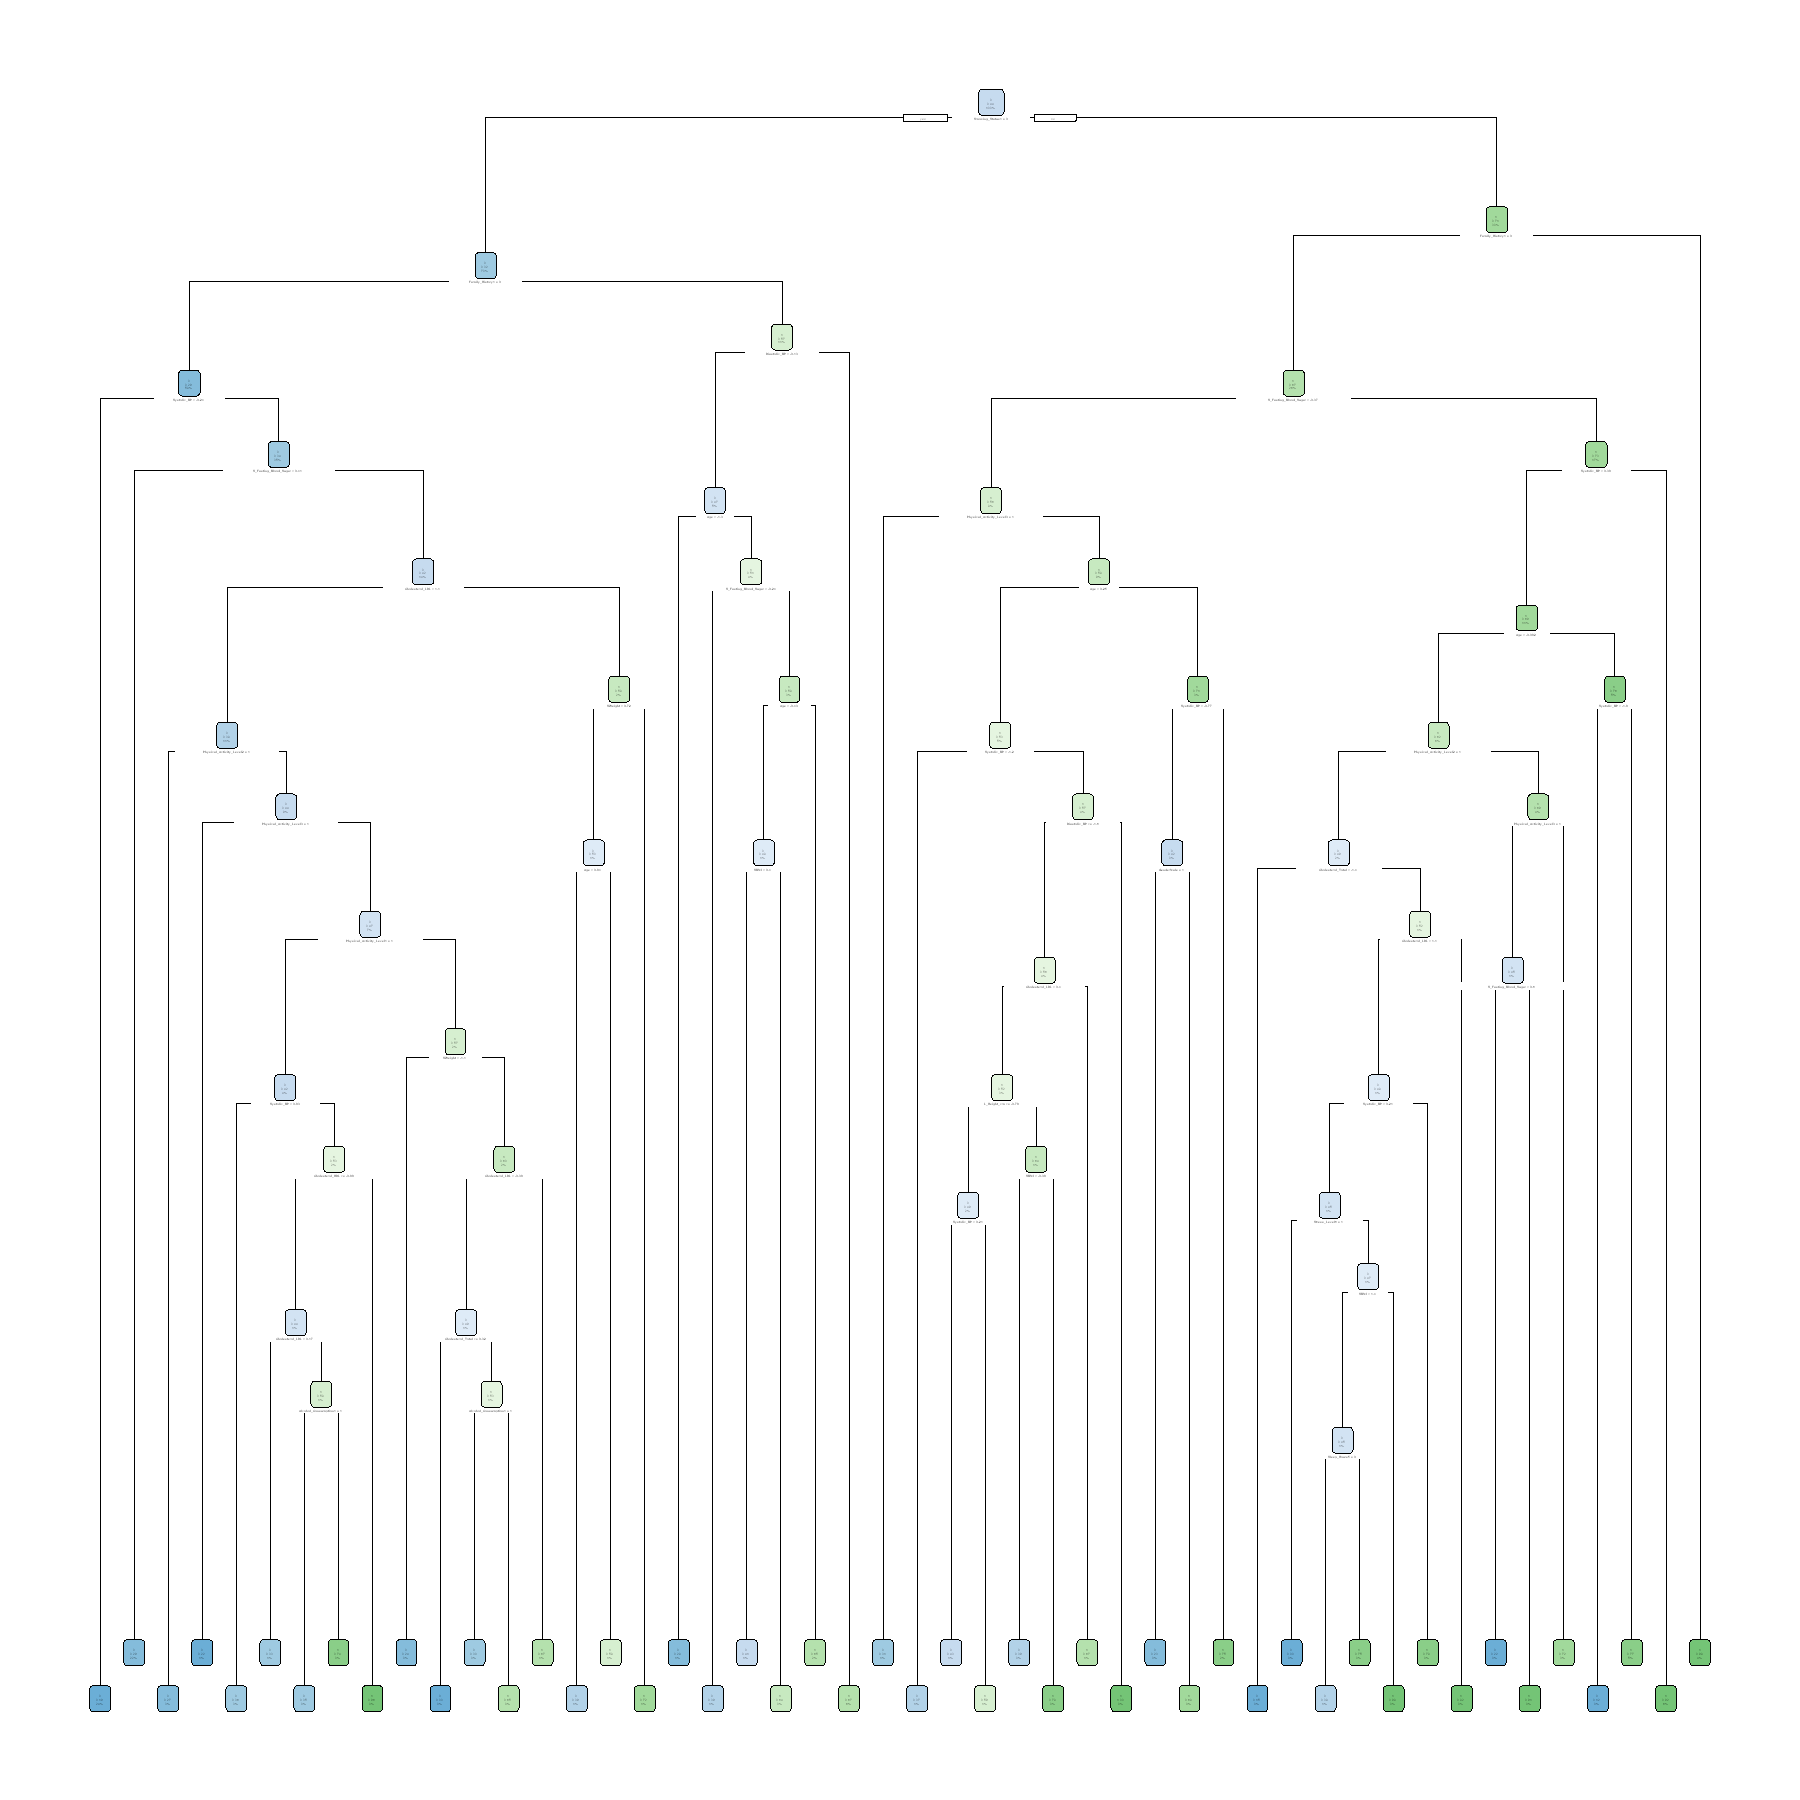

In [42]:
set.seed(123)
ctrl <- trainControl(method = "cv",number = 10) 
tree.info <- train(Heart_Disease_Risk~.,data=dataTrain,method = "rpart",trControl = ctrl,tuneLength =20,metric="Accuracy",parms = list(split = "information"))
print(paste("Valeur de cp retenue = ",tree.info$bestTune,sep=""))
cat("La variable à la racine est :", as.character(tree.info$finalModel$frame$var[1]))
rpart.plot(tree.info$finalModel)

Pour les deux arbres de décision, la variable située à la racine est spécifiquement Smoking_Status1, ce qui indique que l'arbre se sépare immédiatement entre les patients fumeurs (modalité 1) et non-fumeurs. Ce résultat est parfaitement cohérent avec les conclusions de nos modèles de régression logistique et confirme la forte relation entre le tabagisme et le risque cardiaque.

**Comparaison de l'erreur de classification des deux arbres sur l'échantillon  de test**

In [61]:
pred.tree.gini = predict(tree.gini, newdata = dataTest)
table.gini = confusionMatrix(pred.tree.gini, dataTest$Heart_Disease_Risk)$table

pred.tree.info = predict(tree.info, newdata = dataTest)
table.info = confusionMatrix(pred.tree.info, dataTest$Heart_Disease_Risk)$table

print(table.gini)
print(table.info)

          Reference
Prediction    0    1
         0 1339  518
         1  353  790
          Reference
Prediction    0    1
         0 1385  527
         1  307  781


In [ ]:
se_gini <- table.gini["1", "1"] / sum(table.gini[, "1"])
se_info <- table.info["1", "1"] / sum(table.info[, "1"])

cat("Sensibilité Gini:", round(se_gini * 100, 2), "%\n")
cat("Sensibilité Entropie :", round(se_info * 100, 2), "%\n")

Sensibilité Gini: 60.4 %
Sensibilité Entropie : 59.71 %


Les sensibilités sont quasi-identiques ce qui montre qu'il est très dur de choisir le meilleur modèle entre ces deux arbres. Il serait donc faux de déclarer un critère supérieur à l'autre. D'autant plus que les arbres de classification sont connus pour leur forte variance: le moindre changement dans le tirage aléatoire des blocs de la validation croisée modifie la structure des branches.

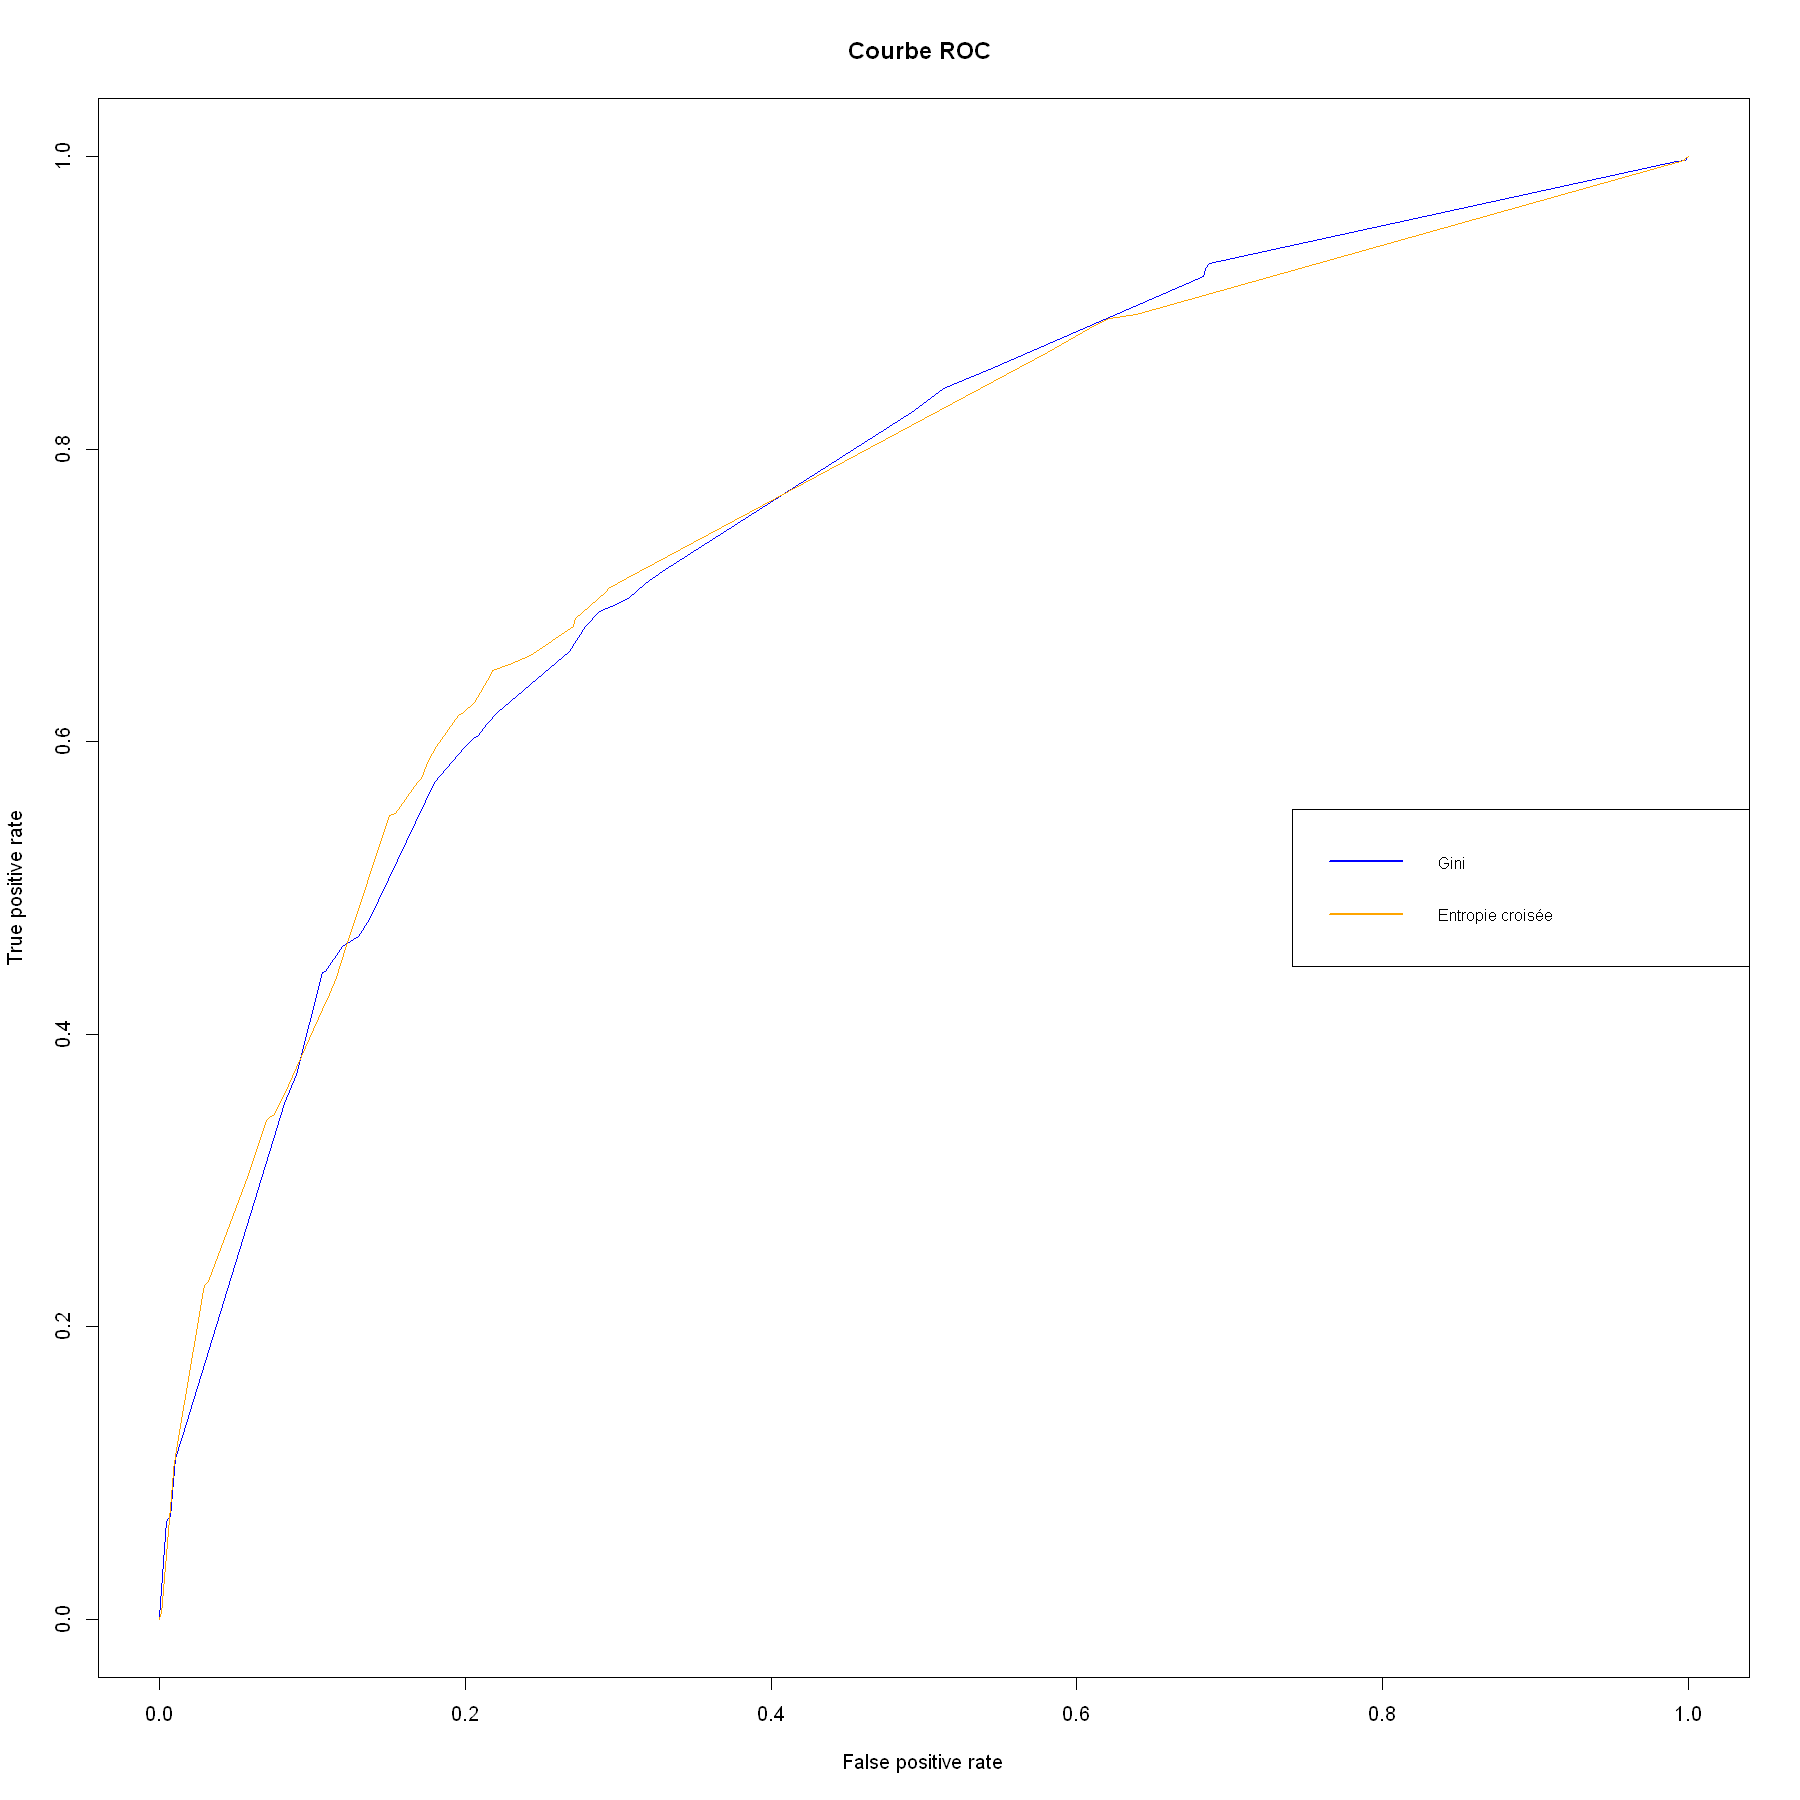

In [72]:
prob.tree.gini <- predict(tree.gini, newdata = dataTest, type = "prob")[,2] 
pred_rocr_tree.gini <- prediction(prob.tree.gini, dataTest$Heart_Disease_Risk)
perf.tree.gini <- performance(pred_rocr_tree.gini, "tpr", "fpr")

prob.tree.info <- predict(tree.info, newdata = dataTest, type = "prob")[,2] 
pred_rocr_tree.info <- prediction(prob.tree.info, dataTest$Heart_Disease_Risk)
perf.tree.info <- performance(pred_rocr_tree.info, "tpr", "fpr")

plot(perf.tree.gini, col = "blue" ,main = "Courbe ROC ")
plot(perf.tree.info,col="orange",add=TRUE)

legend("right", legend=c("Gini", "Entropie croisée"),
       col=c("blue","orange"), text.font=1, lwd = 2,cex=0.8)

Le graphique montre que les courbes ROC obtenues avec l'indice de Gini (en bleu) et l'entropie croisée (en orange) se chevauchent sur presquetout l'échantillon de test. Leurs aires sous la courbe sont visiblement très proches. Ce résultat confirme l'analyse des matrices de confusion: le choix du critère d'hétérogénéité n'a pas d'impact significatif sur la capacité globale du modèle à prédire le risque cardiaque.

Au final, nous choisissons de retenir l'arbre obtenu avec le critère de gini pour la comparaison finale, en raison de sa sensibilité très légèrement supérieure.

## Forêt aléatoire

Dans cette partie nous allon itiliser une forêt aléatoire. Le principe est de combiner plusieurs arbres presques indépendants (grâce à une sélection de variables aléatoire) pour obtenir une prédiction globale par vote de majorité. Son avantage par rapport à un arbre unique est la réduction de la variance car comme nous l'avons évoqué, un arbre seul est très instable et sensible au hasard. En faisant la moyenne de centaines d'arbres, la forêt compense les erreurs individuelles de chacun, ce qui évite le sur-apprentissage et rend le modèle beaucoup plus robuste et précis.

Lors de l'implémentation nous devons calibrer deux paramètres:
- Le nombre d'arbres: plus il y en a, plus le modèle est stable, mais complexe.
- Le nombre de variables sélectionnées pour chaque division. Pour un problème de classification comme le nôtre, on choisit une valeur proche de $\sqrt{p}$, où $p$ représente le nombre total de variables prédictives. C'est d'ailleurs la valeur par défaut de l'algorithme. Dans notre cas, avec $p = 17$, la valeur théorique $\sqrt{17} \approx 4.12$ est arrondie à 4.

In [37]:
library(randomForest)

In [94]:
set.seed(123)
rf=randomForest(Heart_Disease_Risk~.,data=dataTrain,xtest=dataTest[,-14],ytest=dataTest[,"Heart_Disease_Risk"],ntree=500,do.trace=50,importance=TRUE)
rf$importance

ntree      OOB      1      2|    Test      1      2
   50:  28.68% 21.79% 37.58%|  27.47% 20.27% 36.77%
  100:  27.79% 20.86% 36.75%|  27.30% 19.98% 36.77%
  150:  27.53% 20.85% 36.18%|  27.23% 19.80% 36.85%
  200:  27.60% 20.72% 36.51%|  26.73% 19.03% 36.70%
  250:  27.62% 20.74% 36.51%|  26.93% 19.56% 36.47%
  300:  27.45% 20.48% 36.47%|  26.83% 19.62% 36.16%
  350:  27.46% 20.52% 36.43%|  26.70% 19.27% 36.31%
  400:  27.47% 20.49% 36.49%|  26.83% 19.50% 36.31%
  450:  27.35% 20.36% 36.39%|  26.77% 19.39% 36.31%
  500:  27.33% 20.33% 36.39%|  26.67% 19.44% 36.01%


,0,1,MeanDecreaseAccuracy,MeanDecreaseGini
Age,8.687523e-03,5.466869e-03,7.281701e-03,407.56450
Gender,1.144069e-03,-8.709588e-05,6.071418e-04,39.30391
Systolic_BP,1.341087e-02,9.235740e-03,1.159547e-02,418.52978
Diastolic_BP,8.580021e-03,3.721576e-03,6.459629e-03,341.29865
Cholesterol_Total,6.743315e-03,2.720093e-03,4.983992e-03,381.00497
Cholesterol_LDL,5.992669e-03,5.298881e-03,5.689109e-03,377.73425
Cholesterol_HDL,1.551524e-03,2.755781e-04,9.943672e-04,311.72906
Smoking_Status,5.115946e-02,6.577301e-02,5.752395e-02,710.99579
Alcohol_Consumption,2.015830e-04,-4.838887e-04,-9.690339e-05,98.42713
Physical_Activity_Level,8.432524e-03,9.746743e-03,9.004920e-03,221.71705


Le modèle de forêt aléatoire présente une performance stable avec un taux d'erreur Out Of Bag (OOB) qui se stabilise autour de 27,33 % à 500 arbres. L'observation des résultats montre que l'erreur sur l'échantillon de test converge et se stabilise dès 200 arbres (passant de 27,47 % à 26,73 % avant de stagner). 

On remarque en comparant les colonnes d'erreur 1 et 2 que le modèle à beaucoup plus de mal à détecter une personne avec risque cardiaque qu'une personne sans (une erreur de 36% contre 19% sur l'échantillon de test).

L'analyse de l'importance des variables montre que le statut tabagique (Smoking_Status) est le prédicteur le plus puissant du risque cardiaque avec le score Mean Decrease Accuracy (MDA) le plus élevé ($5,75 \times 10^{-2}$). Il est suivi par les antécédents familiaux (Family_History : $1,67 \times 10^{-2}$) et la pression artérielle systolique (Systolic_BP : $1,15 \times 10^{-2}$). 

À l'inverse, la variable liée à la consommation d'alcool (Alcohol_Consumption) n'apporte aucune contribution utile au modèle, affichant même un score MDA négatif ($-9,69 \times 10^{-5}$), ce qui indique que son inclusion tend à légèrement dégrader la qualité des prédictions.

Pour mieux visuellement étudier l'importance des variables dans le modèle, nous allons afficher les MDA des variables dans un graphique:

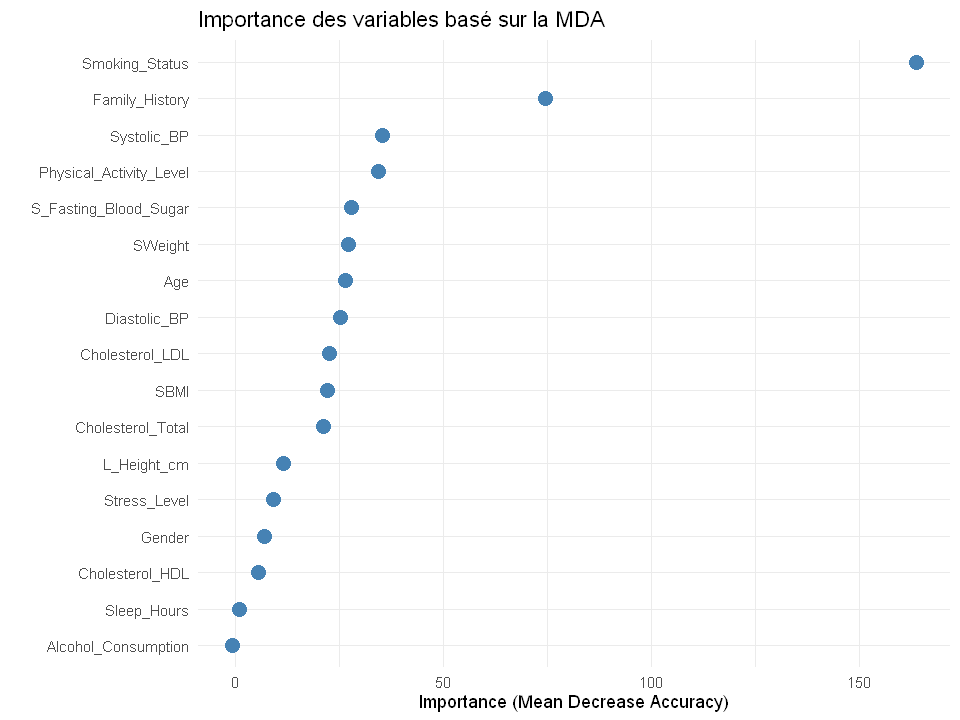

In [79]:
options(repr.plot.width = 8, repr.plot.height = 6)

imp_var <- as.data.frame(importance(rf))
imp_var$Variable <- rownames(imp_data)

ggplot(imp_var, aes(x = reorder(Variable, MeanDecreaseAccuracy), y = MeanDecreaseAccuracy)) +
  geom_point(size = 4, color = "steelblue") +  
  coord_flip() +               
  theme_minimal() +
  labs(
    title = "Importance des variables basé sur la MDA",
    x = "",
    y = "Importance (Mean Decrease Accuracy)"
  )

Ce graphique confirme nos conclusions précédentes quant à l'importance dominante des variables Smoking_Status et Family_History.

In [95]:
pred.rf=rf$test$predicted
table.rf = table(pred.rf,dataTest[,"Heart_Disease_Risk"])
confusionMatrix(pred.rf,dataTest[,"Heart_Disease_Risk"],positive='1')

Confusion Matrix and Statistics

          Reference
Prediction    0    1
         0 1363  471
         1  329  837
                                          
               Accuracy : 0.7333          
                 95% CI : (0.7171, 0.7491)
    No Information Rate : 0.564           
    P-Value [Acc > NIR] : < 2.2e-16       
                                          
                  Kappa : 0.451           
                                          
 Mcnemar's Test P-Value : 6.193e-07       
                                          
            Sensitivity : 0.6399          
            Specificity : 0.8056          
         Pos Pred Value : 0.7178          
         Neg Pred Value : 0.7432          
             Prevalence : 0.4360          
         Detection Rate : 0.2790          
   Detection Prevalence : 0.3887          
      Balanced Accuracy : 0.7227          
                                          
       'Positive' Class : 1               
                        

L'analyse des performances de notre modèle de forêt aléatoire met en lumière plusieurs indicateurs clés. Tout d'abord, l'Accuracy s'élève à 0,7333, ce qui signifie que le modèle formule une prédiction correcte dans 73,33 % des cas. Pour évaluer la pertinence de ce score, on le compare au NIR,représente le score qu'obtiendrait un modèle naïf prédisant systématiquement la classe la plus fréquente. Ici il vaut 0,5640 ce qui indique que notre modèle est significativement plus performant qu'un simple pronostic basé sur la majorité.

Lorsque l'on détaille le comportement du modèle par classe, on observe un fort déséquilibre entre la spécificité et la sensibilité. La spécificité atteint 0,8056, ce qui montre que l'algorithme est particulièrement efficace pour identifier les personnes sans risque cardiaque. En revanche, la sensibilité s'avère plus faible avec une valeur de 0,6399. Cela indique que le modèle ne parvient à détecter que 63,99 % des individus ayant un risque cardiaque. Comme nous l'avons évoqué, ce comportement pose un problème dans un contexte médical.

Nous allon maintenant comparer la forêt aléatoire avec nos arbres simples via leur courbe ROC.

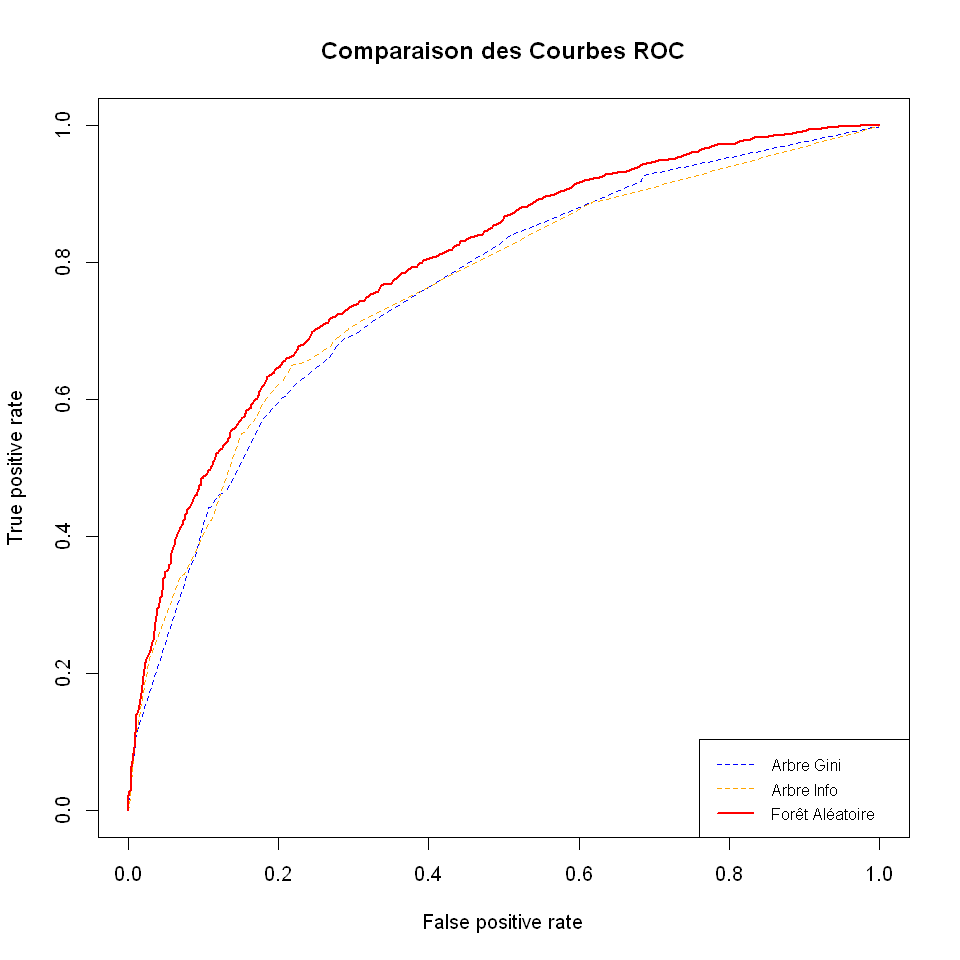

In [96]:
options(repr.plot.width = 8, repr.plot.height = 8)

prob.rf <- rf$test$votes[,2]
pred_rocr_rf <- prediction(prob.rf, dataTest$Heart_Disease_Risk)
perf.rf <- performance(pred_rocr_rf, "tpr", "fpr")

plot(perf.tree.gini, col = "blue", lty = 2, main = "Comparaison des Courbes ROC")
plot(perf.tree.info, col = "orange", lty = 2, add = TRUE)
plot(perf.rf, col = "red", lwd = 2, add = TRUE) 

legend("bottomright", 
       legend = c("Arbre Gini", "Arbre Info", "Forêt Aléatoire"),
       col = c("blue", "orange", "red"), 
       lty = c(2, 2, 1), 
       lwd = c(1, 1, 2),
       cex = 0.8)

Le graphique de comparaison des courbes ROC confirme visuellement la supériorité de cette approche par forêt aléatoire. La courbe rouge se situe systématiquement au-dessus de celles des deux arbres de décision simples, montrant une aire sous la courbe nettement plus élevée. On en conclut que la forêt aléatoire est non seulement plus robuste face à la variance, mais surtout globalement plus performante pour prédire la variable Heart_Disease_Risk.

## Le Gradient Boosting

Le Boosting construit des arbres les uns après les autres, contrairement aux forêts aléatoires qui travaillent en parallèle. À chaque itération, l'algorithme construit un nouvel arbre très simple en se focalisant spécifiquement sur les erreurs commises par le précédent. Plus précisement pour le Gradient Boosting, l'algorithme ajuste le poids des observations mal classées en suivant la direction du gradient de la fonction de perte, ce qui pousse chaque nouvel arbre à descendre vers l'erreur minimale. La prédiction finale résulte de la combinaison pondérée de tous ces arbres.

La configuration de notre modèle repose sur trois hyperparamètres: le nombre d'arbres (n.trees), le learning rate ($\nu$) et le nombre minimal d'observations par nœud (n.minobsinnode).

In [39]:
library(gbm)

On a d'abord besoin de transformer la variable Heart_Disease_Risk en format numérique:

In [100]:
dataTrain2=dataTrain
dataTrain2[,"Heart_Disease_Risk"]=as.numeric(dataTrain[,"Heart_Disease_Risk"])-1

La stratégie de calibration des paramètres consiste à fixer un learning rate faible (on choisit $\nu = 0.03$) afin d'attribuer un poids réduit à chaque nouvel arbre. En ralentissant la vitesse de convergence, on évite que l'algorithme ne dépasse l'optimum. Nous calibrons ensuite la valeur optimale de n.trees par une validation croisée à 10 folds. En surveillant l'erreur de généralisation, cette méthode applique un arrêt dès que le modèle a convergé, stoppant l'apprentissage juste avant que l'erreur ne remonte afin d'éviter le sur-ajustement. En outre, on choisit n.minobsinnode=5 pour empêchant les arbres individuels de créer des règles trop isolées.

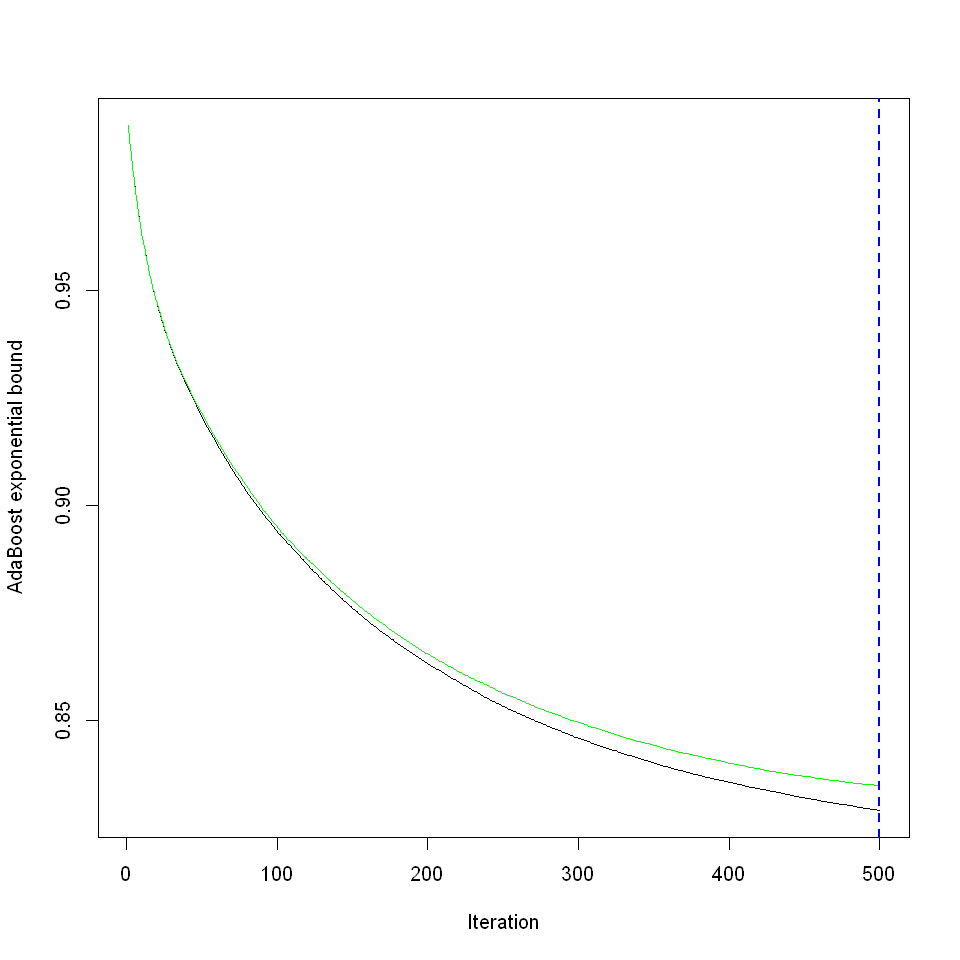

In [92]:
set.seed(123)
boost=gbm(Heart_Disease_Risk~.,data=dataTrain2,distribution="adaboost",n.trees=500, cv.folds=10,n.minobsinnode = 5,shrinkage=0.03,verbose=FALSE)
best.ited=gbm.perf(boost,method="cv")

La courbe noire représente l'évolution de l'erreur d'entraînement, elle sera toujours décroissante. La courbe verte est calculée sur les données non vu pendant l'entraînement (validation croisée).

La ligne bleue pointillée marque le moment où la courbe verte arrête de descendre de façon significative et donc le nombre optimal d'itération pour avoir un modèle bien entraîné sans surajustement. Cependant, ici la ligne bleue se situant à la limite maximale des 500 itérations, le modèle n'a pas encore atteint son optimum de performance. Cela est du au fait que nous avons choisit un learning rate très faible. Nous avons poussé le modèle jusqu'à $n.trees = 1000$ arbres pour voir apparaître le vrai nombre optimal d'arbres.

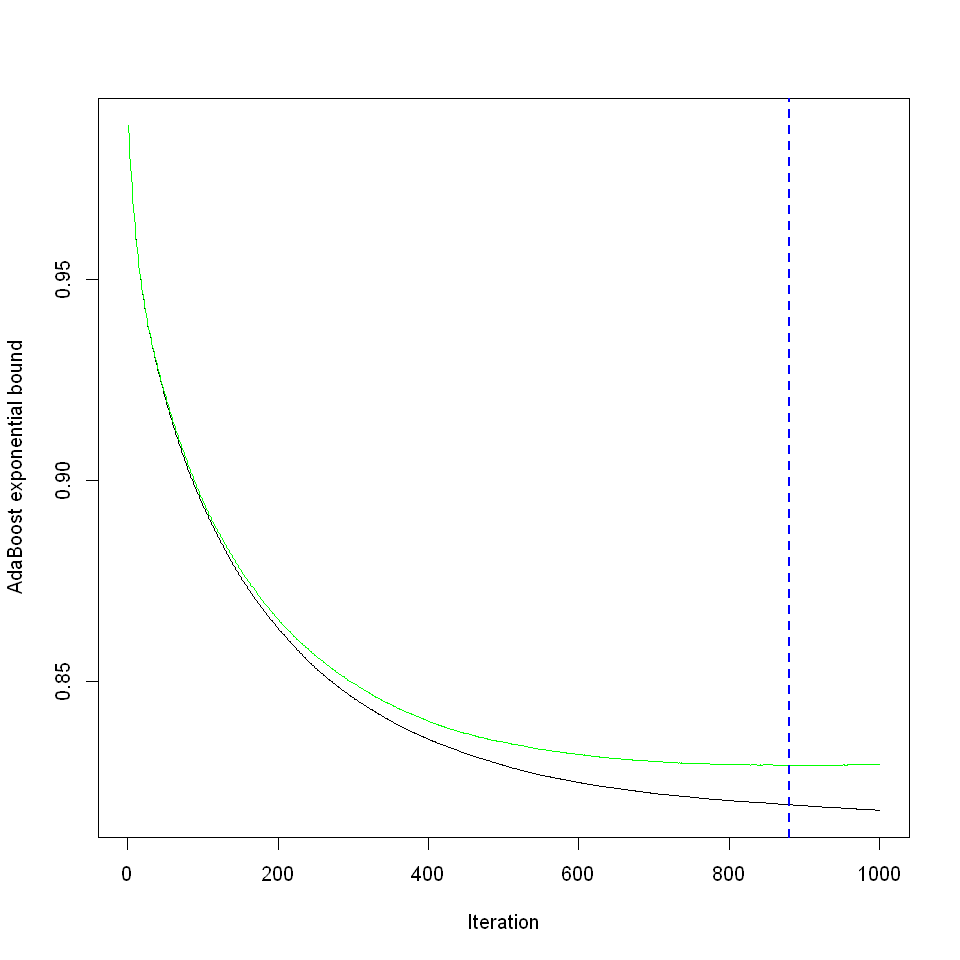

In [104]:
set.seed(123)
options(repr.plot.width = 8, repr.plot.height = 8)
boost=gbm(Heart_Disease_Risk~.,data=dataTrain2,distribution="adaboost",n.trees=1000, cv.folds=10,n.minobsinnode = 5,shrinkage=0.03,verbose=FALSE)
best.ited=gbm.perf(boost,method="cv")

En augmentant le nombre d'itération on voit bien le moment ou la courbe verte stagne et remonte (surajustement). La ligne bleu est donc située optimalement.

### Erreur de prédiction avec matrice de confusion et courbe ROC

In [112]:
pred.boost=predict(boost,newdata=dataTest,n.trees=best.ited)
table.boost=table(as.factor(sign(pred.boost)),dataTest[,"Heart_Disease_Risk"])
print(table.boost)

    
        0    1
  -1 1390  491
  1   302  817


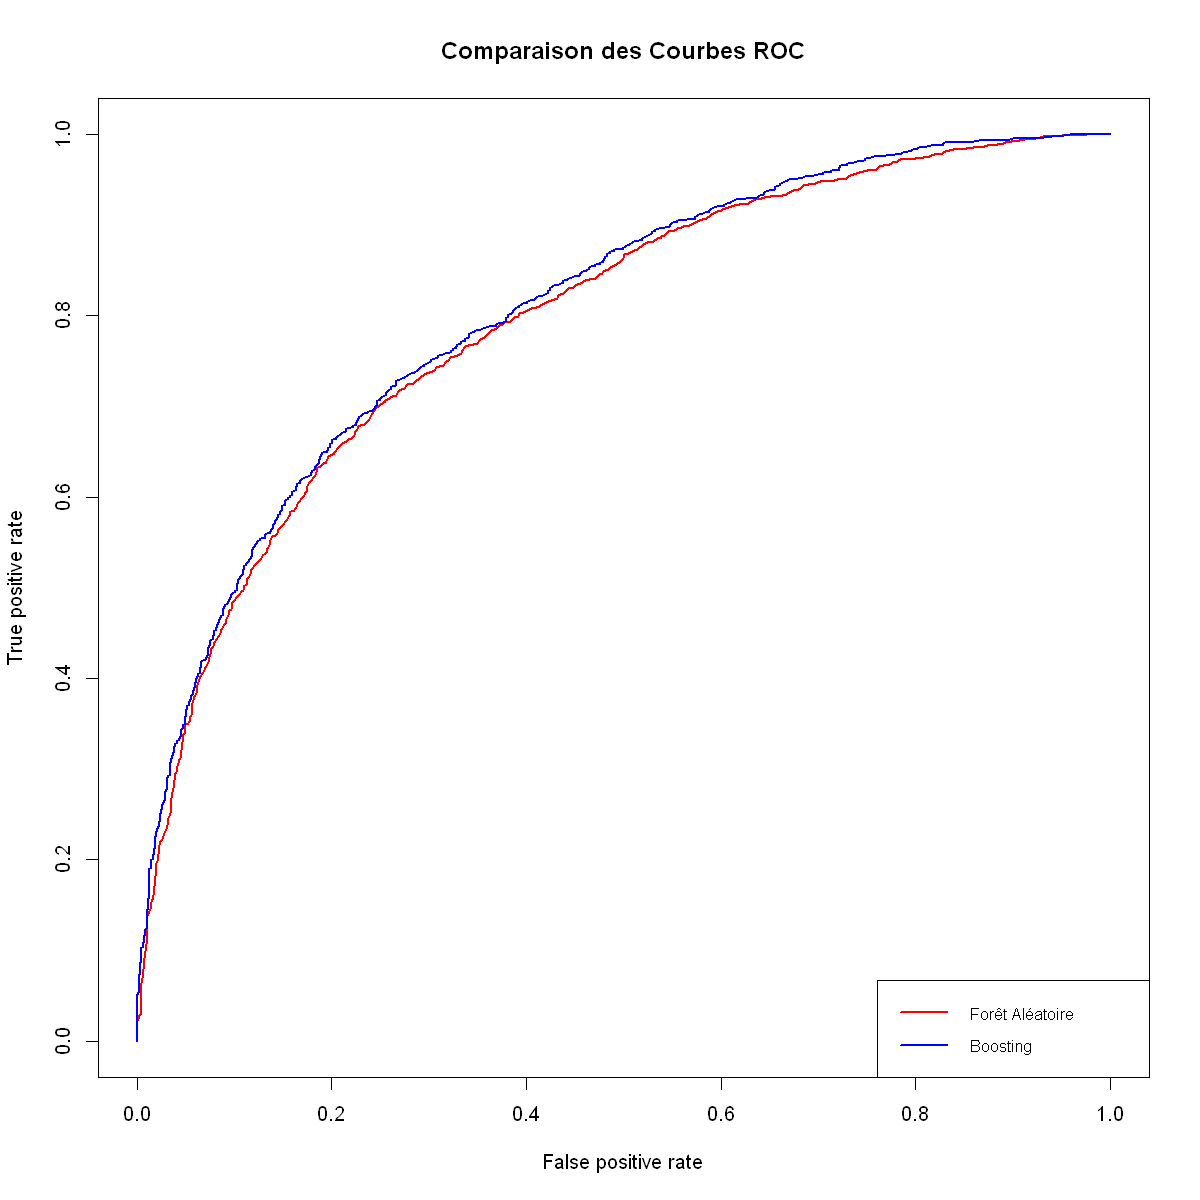

In [114]:
pred_rocr_boost <- prediction(pred.boost, dataTest$Heart_Disease_Risk)
perf.boost <- performance(pred_rocr_boost, "tpr", "fpr")


plot(perf.rf, col = "red", lwd = 2,  main = "Comparaison des Courbes ROC") 
plot(perf.boost, col = "blue", lwd = 2,  add=TRUE) 

legend("bottomright", 
       legend = c( "Forêt Aléatoire", "Boosting"),
       col = c("red", "blue"),  
       lwd = 2,
       cex = 0.8)

La comparaison des courbes ROC montre que le Boosting (en bleu) et la Forêt Aléatoire (en rouge) affichent des performances proches, avec une aire sous la courbe du Boosting qui semble plus grande.

La matrice de confusion du Boosting confirme une bonne détection des individus sains (1390), mais révèle qu'il se heurte au même plafond que la forêt concernant la sensibilité, laissant s'échapper 491 faux négatifs.

## Réseau de neurones (MLP)

Dans cette partie, nous utilisons un réseau de neurones de type Perceptron Multicouche (MLP) comportant une unique couche cachée. Notre but étant de prédire la variable binaire Heart_Disease_Risk, l'estimation des paramètres internes du modèle (les poids et les biais) se fait par la minimisation de l'entropie croisée via l'algorithme de rétropropagation. De plus, la couche de sortie utilise une fonction de transfert sigmoïde, qui compresse le résultat entre $0$ et $1$. Cela permet d'interpréter directement la sortie du réseau comme la probabilité pour un patient d'appartenir à la classe cible (présenter un risque cardiaque).

Contrairement aux paramètres internes calculés automatiquement, la structure de ce réseau repose sur deux hyperparamètres clés que l'utilisateur doit fixer à l'avance:

- Le nombre de neurones sur la couche cachée ("size"): il définit la complexité architecturale du modèle. Un nombre trop faible de neurones empêchera le réseau de capter les relations complexes entre les variables, tandis qu'un nombre trop élevé risque d'entraîner un sur-apprentissage.

- Le paramètre de régularisation $L_2$ ("decay"): il pénalise les poids trop importants dans la fonction perte. Il permet donc d'empêcher le modèle à faire du surapprentissage.

Pour déterminer la combinaison optimale de ces hyperparamètres, nous mettons en œuvre une méthode de validation croisée par recherche via la fonction tune.nnet.

In [40]:
library(nnet)

Pour optimiser le réseau de neurones, nous effectuons donc une recherche par grille sur les deux hyperparamètres (size et decay). Afin d'éviter le sur-apprentissage, nous faisons le choix de limiter le nombre maximal d'itérations à $maxit = 100$. De plus, pour des raisons de temps d'éxecution, cette phase de tuning est réalisée sur un sous-échantillon représentatif de nos données (le même que pour les SVM). Enfin, l'argument linout = FALSE impose une fonction d'activation de sortie sigmoïde pour notre objectif de classification binaire.

In [71]:
tuning_nnet = tune.nnet(Heart_Disease_Risk ~ ., 
                         data = dataTrain_tuning, 
                         size = c(3, 4, 5, 10),   
                         decay = c(0, 1, 2, 3, 4),
                         maxit = 100,            
                         linout = FALSE)

In [73]:
print(tuning_nnet$best.parameters)

  size decay
9    3     2


L'exécution de la grille d'optimisation sélectionne l'architecture size = 3 et decay = 2. Ce résultat s'explique par la logique même de la validation croisée. Pour minimiser l'entropie croisée sur les folds de données non vus lors de l'entraînement, le modèle doit se protéger du sur-apprentissage. Il limite donc sa complexité en choisissant un petit nombre de neurones (3), ce qui l'empêche de mémoriser les données et d'autre part, il impose une forte pénalisation des poids (decay = 2) pour contraindre ses coefficients. Cela lui permet d'obtenir le modèle le plus stable, offrant la plus faible erreur de prédiction sur de futurs patients. Nous allons maintenant l'entraîner sur le jeu d'entraînement entier.

In [74]:
nnet_final <- nnet(Heart_Disease_Risk ~ ., 
                   data = dataTrain, 
                   size = 3, 
                   decay = 2, 
                   maxit = 100,
                   linout = FALSE, 
                   trace = FALSE)

### Erreur de prédiction avec matrice de confusion

In [75]:
#Probabilités prédites
pred_prob_nnet <- predict(nnet_final, newdata = dataTest, type = "raw")

#Classes prédites
pred_class_nnet <- as.factor(ifelse(pred_prob_nnet > 0.5, "1", "0"))

table.nnet <- table(pred_class_nnet, dataTest[,"Heart_Disease_Risk"])

print(table.nnet)

               
pred_class_nnet    0    1
              0 1376  467
              1  316  841


## Comparaison des différents modèles pour la prédiction du risque cardiaque

Nous choisissons de confronter les meilleurs modèles sélectionnés au sein de chaque catégorie:
- La régression logistique sans interaction (optimisée par le critère BIC)
- Le modèle SVM à noyau linéaire
- L'arbre de décision basé sur le critère de Gini
- La forêt aléatoire
- Le boosting
- Le réseau de neurones optimal

Afin d'évaluer ces algorithmes sous tous leurs angles, nous comparerons leurs courbes ROC, leurs aires sous la courbe (AUC) et leur exactitude globale (Accuracy) pour mesurer leur performance générale. Mais, dans un contexte de données médicales, les conséquences d'un faux négatif sont plus lourdes que celles d'un faux positif. C'est pour cela nous nous intéresserons aussi à la sensibilité et au score F1. Si cette sensibilité reste prioritaire pour maximiser la détection des patients à risque cardiaque, le score F1 est indispensable pour s'assurer que le modèle n'obtient pas ce bon résultat au prix d'un grand nombre de fausses alertes (faux positifs).

### Visualisation via les courbes ROC et calcul de l'aire sous les courbes (AUC)

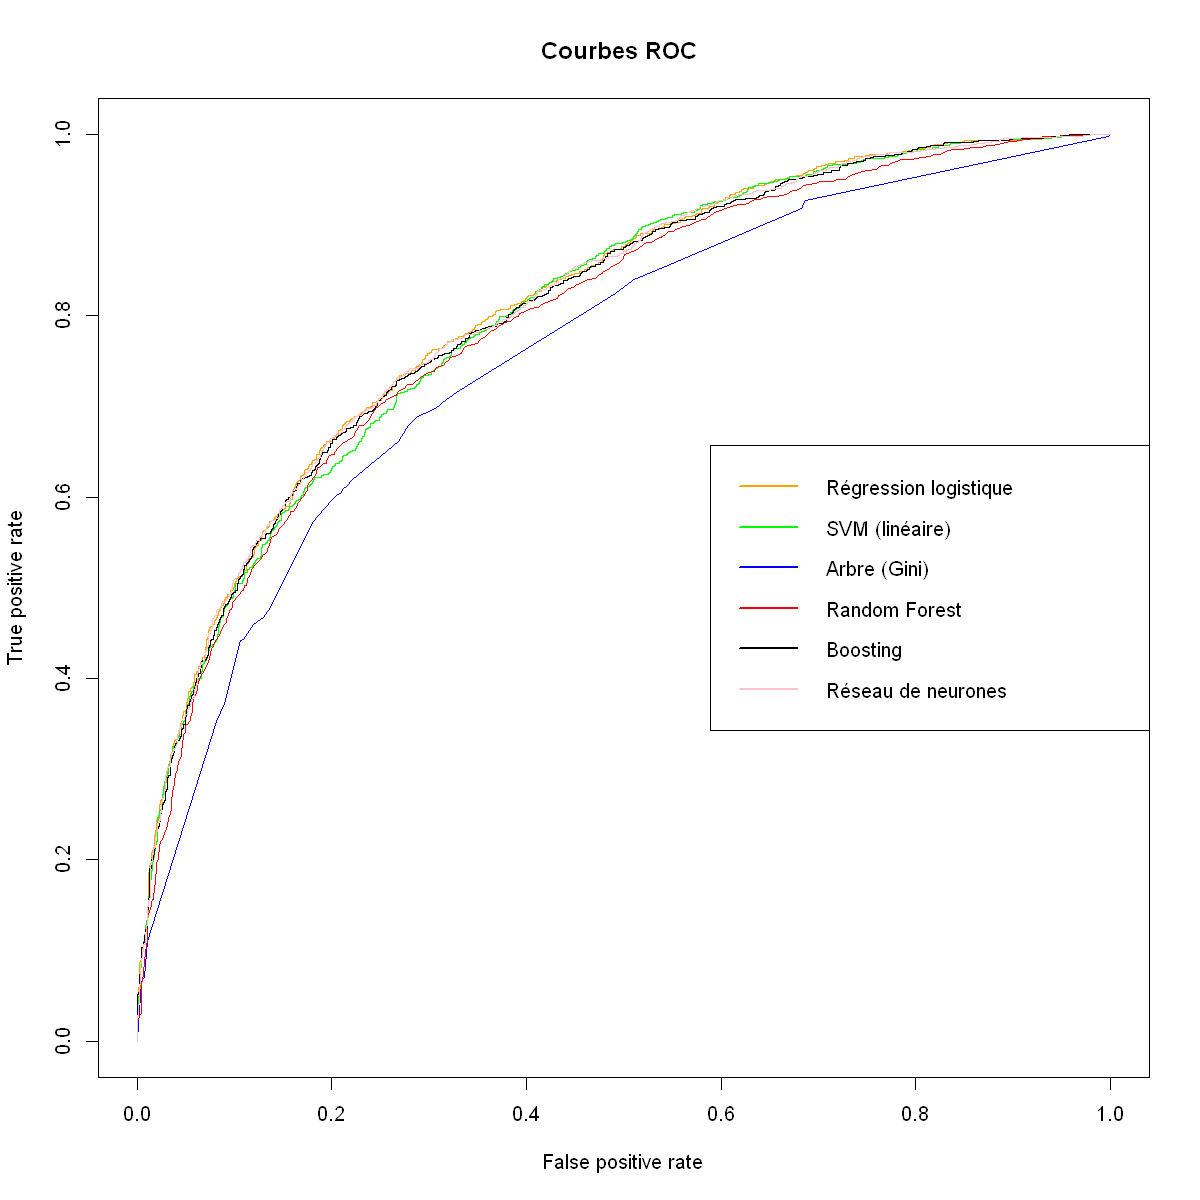

In [139]:
options(repr.plot.width = 10, repr.plot.height = 10)

#Calculs préliminaires pour le réseau de neurone
pred_roc.nnet <- prediction(pred_prob_nnet, dataTest$Heart_Disease_Risk)
perf.nnet <- performance(pred_roc.nnet, "tpr", "fpr")


plot(perflogit.BIC,col="orange",lty=1,main = "Courbes ROC ") 
plot(perf.linear, col = "green", add = TRUE)
plot(perf.tree.gini,col="blue",add=TRUE)
plot(perf.rf, col = "red", add = TRUE)
plot(perf.boost, col = "black",  add=TRUE) 
plot(perf.nnet, col = "pink",  add=TRUE) 

legend("right", legend=c( "Régression logistique", "SVM (linéaire)","Arbre (Gini)", "Random Forest","Boosting","Réseau de neurones"),
       col=c("orange","green","blue","red","black","pink"),lwd = 2)

In [140]:
# Ajout des prédictions de probabilités pour le réseau de neurone
pred_rocr.nnet <- prediction(pred_prob_nnet, dataTest$Heart_Disease_Risk)

auc.reglogBIC <- as.numeric(performance(predlogit.BIC, "auc")@y.values)
auc.SVM <- as.numeric(performance(pred_obj.linear, "auc")@y.values)
auc.tree.gini <- as.numeric(performance(pred_rocr_tree.gini, "auc")@y.values)
auc.rf <- as.numeric(performance(pred_rocr_rf, "auc")@y.values)
auc.boosting <- as.numeric(performance(pred_rocr_boost, "auc")@y.values)
auc.nnet <- as.numeric(performance(pred_rocr.nnet, "auc")@y.values)


cat("Comparaisons des aires sous la courbe (AUC): \n")
cat("Régression logistique: ", round(auc.reglogBIC, 4), "\n")
cat("SVM: ", round(auc.SVM, 4), "\n")
cat("Arbre: ", round(auc.tree.gini, 4), "\n")
cat("Random Forest: ", round(auc.rf, 4), "\n")
cat("Boosting: ", round(auc.boosting, 4), "\n")
cat("Réseau de neurones: ", round(auc.nnet, 4), "\n")

Comparaisons des aires sous la courbe (AUC): 
Régression logistique:  0.8096 


SVM:  0.8038 
Arbre:  0.7582 
Random Forest:  0.7949 
Boosting:  0.8053 
Réseau de neurones:  0.8075 


L'analyse des courbes ROC montre un comportement globalement homogène de la part de l'ensemble de nos modèles. La quasi-totalité des courbes se chevauchent de manière très étroite tout au long de l'espace de décision.

Une seule exception notable se détache: l'arbre de décision seul (courbe bleue). Sa trajectoire reste systématiquement en retrait, sous le bloc des autres courbes.

Les 5 autres modèles affiche des AUC très proches, l'analyse de la sensibilité et du score F1 sera indispensable poir départager les modèles.

Les résultats révèlent tout de même que la régression logistique rivalise avec (et surpasse même de très peu) les algorithmes de pointe plus complexes. L'absence de gain de performance significatif par les approches non-linéaires (Boosting, MLP) démontre que les relations entre les facteurs de risque et le risque cardiaque sont essentiellement linéaires dans ce jeu de données.

### Accuracy

In [141]:
acc.reglogBIC <- sum(diag(table.BIC)) / sum(table.BIC)
acc.SVM <- sum(diag(table.linear)) / sum(table.linear)
acc.tree.gini <- sum(diag(table.gini)) / sum(table.gini)
acc.rf <- sum(diag(table.rf)) / sum(table.rf)
acc.boosting  <- sum(diag(table.boost)) / sum(table.boost)
acc.nnet  <- sum(diag(table.nnet)) / sum(table.nnet)


cat("Comparaisons de l'exactitude globale (Accuracy): \n")
cat("Régression logistique : ", round(acc.reglogBIC * 100, 2), "%\n")
cat("SVM                   : ", round(acc.SVM * 100, 2), "%\n")
cat("Arbre                 : ", round(acc.tree.gini * 100, 2), "%\n")
cat("Random Forest         : ", round(acc.rf * 100, 2), "%\n")
cat("Boosting              : ", round(acc.boosting * 100, 2), "%\n")
cat("Réseau de neurones    : ", round(acc.nnet * 100, 2), "%\n")

Comparaisons de l'exactitude globale (Accuracy): 
Régression logistique :  74.1 %


SVM                   :  72.87 %
Arbre                 :  70.97 %
Random Forest         :  73.33 %
Boosting              :  73.57 %
Réseau de neurones    :  73.9 %


On retrouve les mêmes conclusions pour les scores d'Accuracy qui sont proches pour tous les modèles, ce qui confirme que cette métrique globale ne permet pas de les départager et qu'il faut analyser la sensibilité et le score F1.

### Sensibilité et score F1

In [142]:
#Calcul sensibilité des modèles (seulement de ceux que l'on a pas déjà calculé)
se.SVM       <- table.linear["1", "1"]     / sum(table.linear[, "1"])
se.rf        <- table.rf["1", "1"]         / sum(table.rf[, "1"])
se.boosting  <- table.boost["1", "1"]      / sum(table.boost[, "1"])
se.nnet  <- table.nnet["1", "1"]      / sum(table.nnet[, "1"])


#Calcul score F1
# Formule F1 : 2 * (Précision * Sensibilité) / (Précision + Sensibilité)

p.reglogBIC  <- table.BIC["TRUE", "1"] / sum(table.BIC["TRUE", ])
f1.reglogBIC <- 2 * (p.reglogBIC * se_reglog.BIC) / (p.reglogBIC + se_reglog.BIC)

p.SVM  <- table.linear["1", "1"] / sum(table.linear["1", ])
f1.SVM <- 2 * (p.SVM * se.SVM) / (p.SVM + se.SVM)

p.tree.gini  <- table.gini["1", "1"] / sum(table.gini["1", ])
f1.tree.gini <- 2 * (p.tree.gini* se_gini) / (p.tree.gini + se_gini)

p.rf  <- table.rf["1", "1"] / sum(table.rf["1", ])
f1.rf <- 2 * (p.rf * se.rf) / (p.rf + se.rf)

p.boosting  <- table.boost["1", "1"] / sum(table.boost["1", ])
f1.boosting <- 2 * (p.boosting * se.boosting) / (p.boosting + se.boosting)

p.nnet <- table.nnet["1", "1"] / sum(table.nnet["1", ])
f1.nnet <- 2 * (p.nnet * se.nnet) / (p.nnet + se.nnet)


cat("COMPARAISON DE LA SENSIBILITÉ\n")
cat("Régression logistique : ", round(se_reglog.BIC * 100, 2), "%\n")
cat("SVM                   : ", round(se.SVM * 100, 2), "%\n")
cat("Arbre                 : ", round(se_gini * 100, 2), "%\n")
cat("Random Forest         : ", round(se.rf * 100, 2), "%\n")
cat("Boosting              : ", round(se.boosting * 100, 2), "%\n")
cat("Réseau de neurones    : ", round(se.nnet * 100, 2), "%\n")

cat("\nCOMPARAISON DU SCORE F1\n")
cat("Régression logistique : ", round(f1.reglogBIC * 100, 2), "%\n")
cat("SVM                   : ", round(f1.SVM * 100, 2), "%\n")
cat("Arbre                 : ", round(f1.tree.gini * 100, 2), "%\n")
cat("Random Forest         : ", round(f1.rf * 100, 2), "%\n")
cat("Boosting              : ", round(f1.boosting * 100, 2), "%\n")
cat("Réseau de neurones    : ", round(f1.nnet * 100, 2), "%\n")

COMPARAISON DE LA SENSIBILITÉ
Régression logistique :  63.61 %
SVM                   :  62.46 %
Arbre                 :  60.4 %
Random Forest         :  63.99 %
Boosting              :  62.46 %
Réseau de neurones    :  64.3 %

COMPARAISON DU SCORE F1


Régression logistique :  68.17 %
SVM                   :  66.75 %
Arbre                 :  64.46 %
Random Forest         :  67.66 %
Boosting              :  67.33 %
Réseau de neurones    :  68.24 %


L’analyse conjointe de la sensibilité et du score F1 révèle encore une grande homogénéité des performances entre les modèles, à l'exception notable de l’Arbre de décision unique, qui reste en retrait (Sensibilité de 60,40 % et F1 de 64,46 %).

Pour l'ensemble des autres modèles, les résultats sont très proches. Le réseau de neurones affiche la sensibilité la plus élevée (64,30 %), suivi de très près par le Random Forest (63,99 %) et la régression logistique (63,61 %). Cette proximité se confirme sur le score F1, où le réseau de neurones (68,24 %) et la régression logistique (68,17 %) obtiennent des résultats quasi-identiques.

On en conclut que d'après ces critères, ces modèles cités se valent en termes de capacité brute à identifier les patients à risque cardiaque. Les algorithmes de Machine Learning non linéaires plus complexes n'apportent aucun gain prédictif réel par rapport à une approche plus traditionnelle.

## Conclusion

Au final, les deux modèles affichant les scores les plus élevés pour tous les critères sont la régression logistique et le réseau de neurones. Face à des performances quasiment identiques, la régression logistique est le choix optimal pour sa simplicité et sa transparence.

En effet, le réseau de neurones fonctionne comme une boîte noire : ses calculs internes sont impossibles à expliquer et il est difficile de savoir quelle variable a eu de l'importance. À l'inverse, la régression logistique permet de comprendre précisément l'impact de chaque facteur de risque (âge, tension, cholestérol) grâce aux Odds Ratios.


# 5. Prédiction du Cholestérol LDL 

Cette section est dédiée à la prédiction de la variable quantitative `Cholesterol_LDL`. Conformément aux consignes, la variable `Heart_Disease_Risk` est exclue des prédicteurs. Contrairement à la classification binaire précédente, nous traitons ici un problème de régression.

Le cadre de modélisation préserve la configuration établie lors de l'analyse exploratoire :
* **Variables quantitatives :** Transformations maintenues ($\sqrt{\text{BMI}}$, $\sqrt{\text{Weight\_kg}}$, $\sqrt{\text{Fasting\_Blood\_Sugar}}$ et $\log(\text{Height\_cm})$).
* **Variables qualitatives :** Déjà encodées sous forme de facteurs (`factor`).

## 5.1 Analyse de la variable cible Cholesterol_LDL

Avant la modélisation, examinons la distribution du taux de cholestérol LDL pour vérifier sa forme et identifier d'éventuelles transformations utiles.

[1] "Moyenne : 140.36 | Ecart-type : 17.91 | Asymétrie : -0.014"

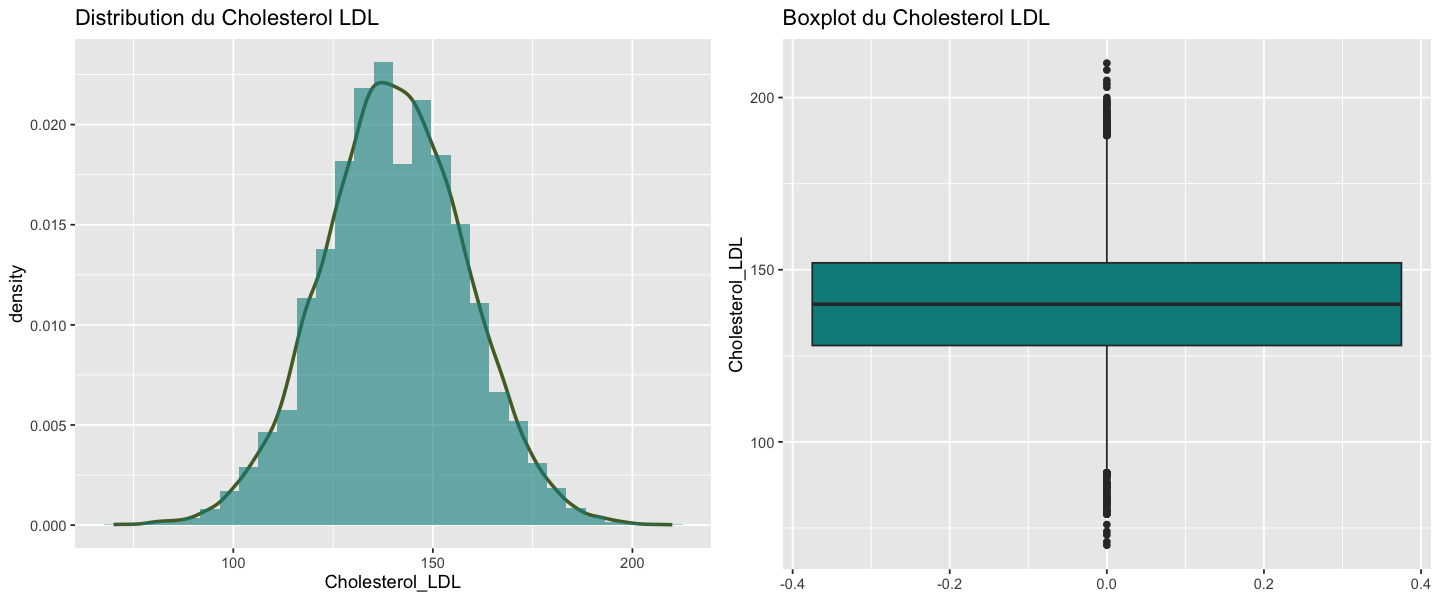

In [8]:
options(repr.plot.width = 12, repr.plot.height = 5)
g_ldl1 = ggplot(data, aes(x = Cholesterol_LDL)) + 
    geom_density(linewidth=1, col="darkolivegreen") + 
    geom_histogram(alpha=0.6, aes(y=after_stat(density)), bins=30, fill="darkcyan") +
    ggtitle("Distribution du Cholesterol LDL")
g_ldl2 = ggplot(data, aes(y = Cholesterol_LDL)) + geom_boxplot(fill="darkcyan") + 
    ggtitle("Boxplot du Cholesterol LDL")
grid.arrange(g_ldl1, g_ldl2, ncol=2)

# Remplacement de moments::skewness par e1071::skewness
paste("Moyenne :", round(mean(data$Cholesterol_LDL),2), 
      "| Ecart-type :", round(sd(data$Cholesterol_LDL),2),
      "| Asymétrie :", round(e1071::skewness(data$Cholesterol_LDL),3))

La distribution de `Cholesterol_LDL` est approximativement symétrique en forme de cloche, centrée autour de 140 mg/dL avec une asymétrie proche de zéro. Aucune transformation supplémentaire n'est nécessaire pour cette variable cible : elle peut être modélisée directement par régression.

## 5.2 Corrélations avec la cible

Pour identifier les variables quantitatives les plus liées au LDL, nous examinons les corrélations avec les autres variables numériques.

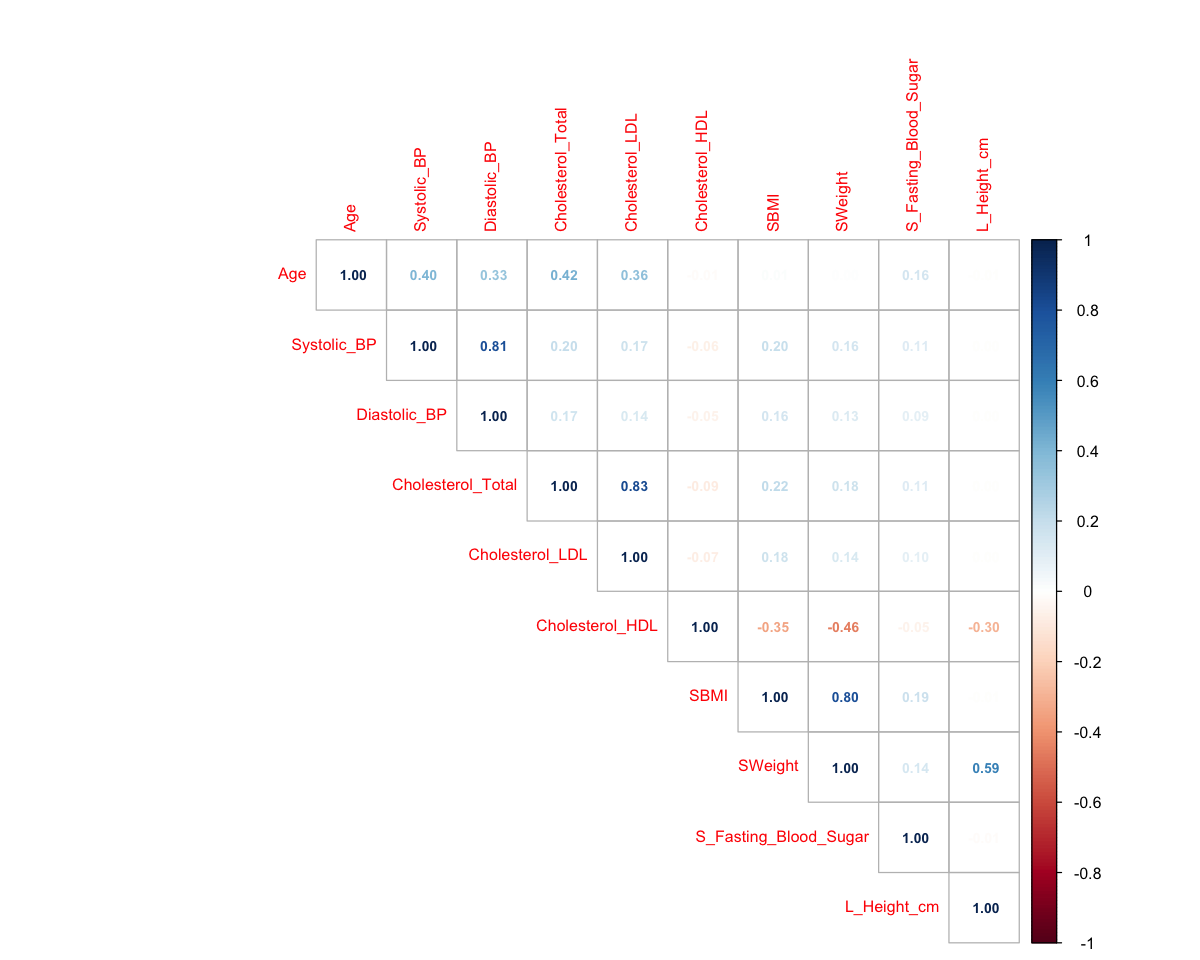

In [9]:
options(repr.plot.width = 10, repr.plot.height = 8)
data_num = data %>% select(where(is.numeric))
corrplot(cor(data_num), method="number", type="upper", tl.cex=0.8, number.cex=0.7)

Cette matrice de corrélation révèle trois liens positifs très forts : entre le cholestérol total et le LDL (0,83), les pressions artérielles systolique et diastolique (0,81), ainsi que l'IMC et le poids transformés (0,80). À l'inverse, le "bon" cholestérol (HDL) présente une corrélation négative modérée avec ces mêmes indicateurs de corpulence (-0,46 pour le poids et -0,35 pour l'IMC).

## 5.3 Division du jeu de données et normalisation

Comme pour la prédiction du risque cardiaque, nous divisons les données en 80% d'apprentissage et 20% de test. La variable `Heart_Disease_Risk` est retirée des prédicteurs conformément à la consigne. Nous normalisons ensuite les variables quantitatives pour mettre toutes les variables sur la même échelle. La moyenne et l'écart-type de la normalisation sont calculés sur l'échantillon d'apprentissage uniquement, puis appliqués à l'échantillon test pour éviter toute fuite d'information.

In [10]:
# On retire Heart_Disease_Risk des prédicteurs 
data_ldl = data %>% select(-Heart_Disease_Risk)

set.seed(131)
trainIndex_ldl = createDataPartition(data_ldl$Cholesterol_LDL, p=0.8, list=FALSE)
dataTrain0_ldl = data_ldl[ trainIndex_ldl,]
dataTest0_ldl  = data_ldl[-trainIndex_ldl,]

paste("Taille apprentissage :", nrow(dataTrain0_ldl), "| Taille test :", nrow(dataTest0_ldl))

[1] "Taille apprentissage : 12002 | Taille test : 2998"

In [11]:
# Identification des colonnes quantitatives à normaliser 
is_quanti = sapply(dataTrain0_ldl, is.numeric)
cols_quanti = which(is_quanti)

# Normalisation des variables quantitatives sur le train
dataTrain_ldl = dataTrain0_ldl
dataTrain_ldl[, cols_quanti] = scale(dataTrain0_ldl[, cols_quanti])

# Application sur le test avec la moyenne et l'écart-type de l'apprentissage
dataTest_ldl = dataTest0_ldl
dataTest_ldl[, cols_quanti] = scale(dataTest0_ldl[, cols_quanti],
    center = sapply(dataTrain0_ldl[, cols_quanti], mean),
    scale  = sapply(dataTrain0_ldl[, cols_quanti], sd))

summary(dataTrain_ldl$Cholesterol_LDL)

    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
-3.92270 -0.68691 -0.01744  0.00000  0.65203  3.77624 

Le jeu de données est divisé selon un ratio classique et robuste : environ 80 % pour l'entraînement et 20 % pour le test.
Par ailleurs, les statistiques confirment que la variable a été correctement normalisée (centrée-réduite) : sa moyenne est exactement de 0 et sa distribution est globalement symétrique, la médiane (-0,017) étant très proche de zéro.

## 5.4 Régression linéaire avec pénalisation Lasso

Nous commençons par une régression linéaire avec pénalisation L1 (Lasso). Cette approche présente deux avantages : elle effectue une sélection de variables automatique (les coefficients des variables non pertinentes sont mis à zéro), et elle reste très interprétable grâce à ses coefficients linéaires. L'hyperparamètre $\lambda$ (force de la pénalisation) est calibré par validation croisée.

[1] "lambda.min = 0.0087 | lambda.1se = 0.0672"

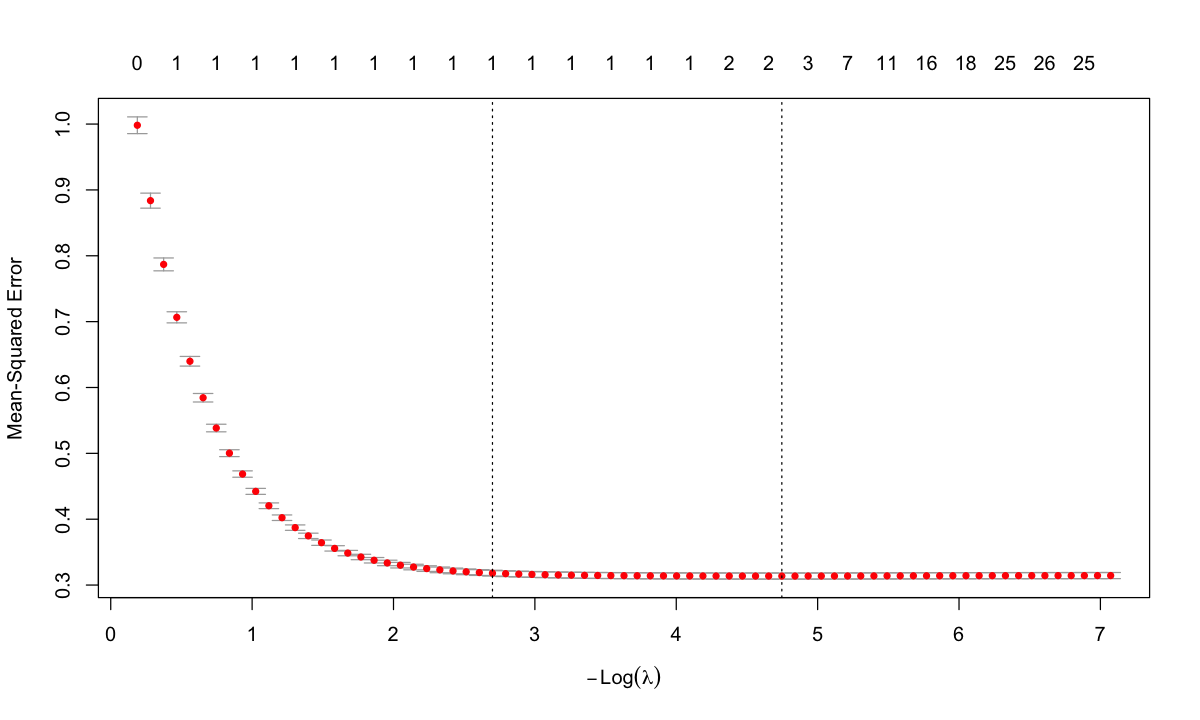

In [12]:
# Préparation des matrices pour glmnet
x_train_ldl = model.matrix(Cholesterol_LDL ~ . - 1, data = dataTrain_ldl)
y_train_ldl = dataTrain_ldl$Cholesterol_LDL
x_test_ldl  = model.matrix(Cholesterol_LDL ~ . - 1, data = dataTest_ldl)
y_test_ldl  = dataTest_ldl$Cholesterol_LDL

set.seed(123)
lasso.cv = cv.glmnet(x_train_ldl, y_train_ldl, alpha=1, family="gaussian", nfolds=10)

options(repr.plot.width = 10, repr.plot.height = 6)
plot(lasso.cv)
paste("lambda.min =", round(lasso.cv$lambda.min, 4),
      "| lambda.1se =", round(lasso.cv$lambda.1se, 4))

Ce graphique illustre la recherche de la pénalité optimale pour le modèle Lasso par validation croisée.

La ligne de droite (lambda.min = 0.0087) indique la valeur minimisant l'erreur avec seulement 2 à 3 variables conservées. La ligne de gauche (lambda.1se = 0.0672) propose un modèle encore plus parcimonieux en ne gardant qu'une seule variable (très probablement le cholestérol total), sans dégrader significativement la performance.

In [13]:
# Coefficients du modèle Lasso optimal
lasso.coef = coef(lasso.cv, s = "lambda.min")
lasso.coef.df = data.frame(Variable = rownames(lasso.coef), Coefficient = as.numeric(lasso.coef))
lasso.coef.df = lasso.coef.df[lasso.coef.df$Variable != "(Intercept)", ]
lasso.coef.df = lasso.coef.df[order(-abs(lasso.coef.df$Coefficient)), ]
print(lasso.coef.df)

                   Variable Coefficient
7         Cholesterol_Total  0.81839029
2                       Age  0.00352986
3              GenderFemale  0.00000000
4                GenderMale  0.00000000
5               Systolic_BP  0.00000000
6              Diastolic_BP  0.00000000
8           Cholesterol_HDL  0.00000000
9           Smoking_Status1  0.00000000
10     Alcohol_Consumption1  0.00000000
11     Alcohol_Consumption2  0.00000000
12 Physical_Activity_Level1  0.00000000
13 Physical_Activity_Level2  0.00000000
14 Physical_Activity_Level3  0.00000000
15          Family_History1  0.00000000
16            Stress_Level2  0.00000000
17            Stress_Level3  0.00000000
18            Stress_Level4  0.00000000
19            Stress_Level5  0.00000000
20            Stress_Level6  0.00000000
21            Stress_Level7  0.00000000
22            Stress_Level8  0.00000000
23            Stress_Level9  0.00000000
24           Stress_Level10  0.00000000
25             Sleep_Hours5  0.00000000


Ce résultat illustre la sélection stricte opérée par le modèle Lasso, qui a ramené à zéro la quasi-totalité des variables pour les exclure. Ainsi, le cholestérol total domine massivement la prédiction (coefficient de 0,82), tandis que l'âge est la seule autre variable conservée mais avec un impact marginal (0,003).

In [14]:
# Prédiction et métriques sur le test
pred.lasso = as.numeric(predict(lasso.cv, newx = x_test_ldl, s = "lambda.min"))

mse.lasso = mean((y_test_ldl - pred.lasso)^2)
mae.lasso = mean(abs(y_test_ldl - pred.lasso))
r2.lasso  = 1 - sum((y_test_ldl - pred.lasso)^2) / sum((y_test_ldl - mean(y_test_ldl))^2)

paste("Lasso | MSE =", round(mse.lasso,2), "| MAE =", round(mae.lasso,2), "| R² =", round(r2.lasso,4))

[1] "Lasso | MSE = 0.3 | MAE = 0.44 | R² = 0.6965"

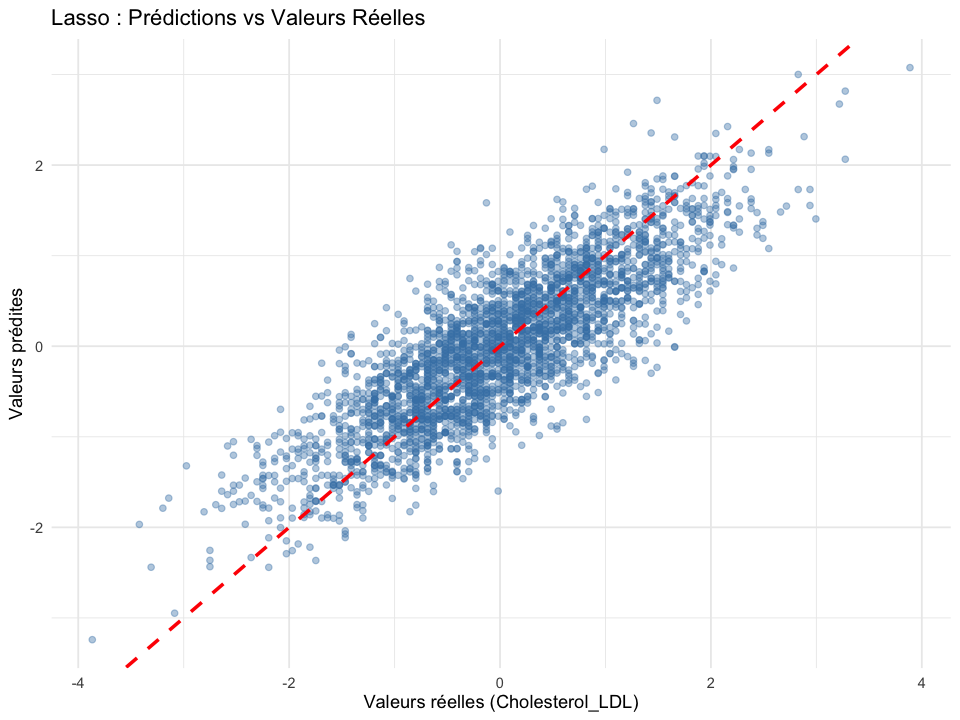

In [15]:
# Visualisation : prédictions vs valeurs réelles
options(repr.plot.width = 8, repr.plot.height = 6)
df_lasso = data.frame(Reel = y_test_ldl, Predit = pred.lasso)
ggplot(df_lasso, aes(x = Reel, y = Predit)) + 
    geom_point(alpha=0.4, color="steelblue") +
    geom_abline(slope=1, intercept=0, color="red", linetype="dashed", linewidth=1) +
    labs(title = "Lasso : Prédictions vs Valeurs Réelles",
         x = "Valeurs réelles (Cholesterol_LDL)",
         y = "Valeurs prédites") +
    theme_minimal()

Les prédictions s'alignent correctement autour de la diagonale idéale (ligne rouge), ce qui montre que le modèle Lasso est globalement bien calibré. Le R^2 confirme cette impression visuelle : le modèle parvient à expliquer près de 70 % de la variance du LDL, bien que la dispersion des points reflète l'erreur résiduelle (MAE de 0,44).

## 5.5 SVR — Support Vector Regression

La SVR (Support Vector Regression) est l'extension des SVM aux problèmes de régression. Le principe est de trouver une fonction qui s'ajuste au plus près des données dans une marge d'erreur $\varepsilon$, tout en restant aussi régulière que possible. Nous testons d'abord un noyau linéaire puis des noyaux non-linéaires (RBF et polynomial) pour voir si la relation entre les prédicteurs et le LDL est mieux capturée par une frontière courbe.

### Noyau linéaire

In [17]:
set.seed(123)
idx_sample = sample(1:nrow(dataTrain_ldl), 3000)
dataTrain_sample = dataTrain_ldl[idx_sample, ]

svr.lin.tune = tune.svm(Cholesterol_LDL ~ ., data = dataTrain_sample, kernel = "linear",
                        cost = c(0.5, 1, 5, 10),
                        epsilon = c(0.01, 0.1, 0.5),
                        tunecontrol = tune.control(cross = 5))
print(svr.lin.tune$best.parameters)

svr.lin.best = svm(Cholesterol_LDL ~ ., data = dataTrain_ldl, kernel = "linear",
                   cost = svr.lin.tune$best.parameters$cost,
                   epsilon = svr.lin.tune$best.parameters$epsilon)

  cost epsilon
9  0.5     0.5


In [18]:
pred.svr.lin = predict(svr.lin.best, newdata = dataTest_ldl)
mse.svr.lin = mean((y_test_ldl - pred.svr.lin)^2)
mae.svr.lin = mean(abs(y_test_ldl - pred.svr.lin))
r2.svr.lin  = 1 - sum((y_test_ldl - pred.svr.lin)^2) / sum((y_test_ldl - mean(y_test_ldl))^2)
paste("SVR linéaire | MSE =", round(mse.svr.lin,2), "| MAE =", round(mae.svr.lin,2), "| R² =", round(r2.svr.lin,4))

[1] "SVR linéaire | MSE = 0.3 | MAE = 0.44 | R² = 0.6942"

Les paramètres optimaux retenus (coût = 0,5 et epsilon = 0,5) montrent que le modèle trouve un bon équilibre en autorisant une marge d'erreur modérée sans trop complexifier la fonction. Par ailleurs, ces performances (R^2≈0,69) sont quasi identiques à celles du Lasso, ce qui confirme que la relation sous-jacente pour prédire le LDL est fondamentalement linéaire.

### Noyau gaussien (RBF) et polynomial

In [22]:
set.seed(123)

idx_sample <- sample(1:nrow(dataTrain_ldl), 3000)
dataTrain_sample <- dataTrain_ldl[idx_sample, ]

svr.rbf.tune = tune.svm(Cholesterol_LDL ~ ., data = dataTrain_sample, kernel = "radial",
                        cost = c(1, 5, 10),
                        gamma = c(0.01, 0.05, 0.1),
                        epsilon = c(0.1),
                        tunecontrol = tune.control(cross = 5))

print(svr.rbf.tune$best.parameters)

svr.rbf.best = svm(Cholesterol_LDL ~ ., data = dataTrain_ldl, kernel = "radial",
                   cost = svr.rbf.tune$best.parameters$cost,
                   gamma = svr.rbf.tune$best.parameters$gamma,
                   epsilon = svr.rbf.tune$best.parameters$epsilon)

pred.svr.rbf = predict(svr.rbf.best, newdata = dataTest_ldl)
mse.svr.rbf = mean((y_test_ldl - pred.svr.rbf)^2)
mae.svr.rbf = mean(abs(y_test_ldl - pred.svr.rbf))
r2.svr.rbf  = 1 - sum((y_test_ldl - pred.svr.rbf)^2) / sum((y_test_ldl - mean(y_test_ldl))^2)

paste("SVR RBF | MSE =", round(mse.svr.rbf,2), "| MAE =", round(mae.svr.rbf,2), "| R² =", round(r2.svr.rbf,4))

  gamma cost epsilon
1  0.01    1     0.1


[1] "SVR RBF | MSE = 0.31 | MAE = 0.44 | R² = 0.6915"

Comme pour le SVR linéaire, les résultats (MSE = 0.31, MAE = 0.44, R^2= 0.6915) sont quasiment identiques à ceux du Lasso. Cela renforce l'idée que l'ajout de non-linéarité via le noyau RBF n'apporte pas de gain de performance significatif sur ces données, car la relation principale est linéaire (dominée par le cholestérol total).

## 5.6 Arbre de décision CART

Nous passons aux méthodes basées sur les arbres avec CART (Classification And Regression Trees). Cette méthode partitionne récursivement l'espace des prédicteurs selon des règles binaires. Le principal hyperparamètre à régler est `cp` (complexity parameter), qui contrôle l'élagage et donc le compromis biais-variance.

In [23]:
set.seed(123)
ctrl_reg = trainControl(method = "cv", number = 10)
tree.cart = train(Cholesterol_LDL ~ ., data = dataTrain_ldl, method = "rpart",
                  trControl = ctrl_reg, tuneLength = 20, metric = "RMSE")
paste("Valeur de cp retenue :", round(tree.cart$bestTune$cp, 5))

Warning message in nominalTrainWorkflow(x = x, y = y, wts = weights, info = trainInfo, :
“There were missing values in resampled performance measures.”


[1] "Valeur de cp retenue : 0.00039"

Le paramètre de complexité (cp) retenu est très petit (0,00039), ce qui indique que l'algorithme a choisi de construire un arbre très profond et complexe pour tenter de capturer au maximum les moindres nuances de tes données.

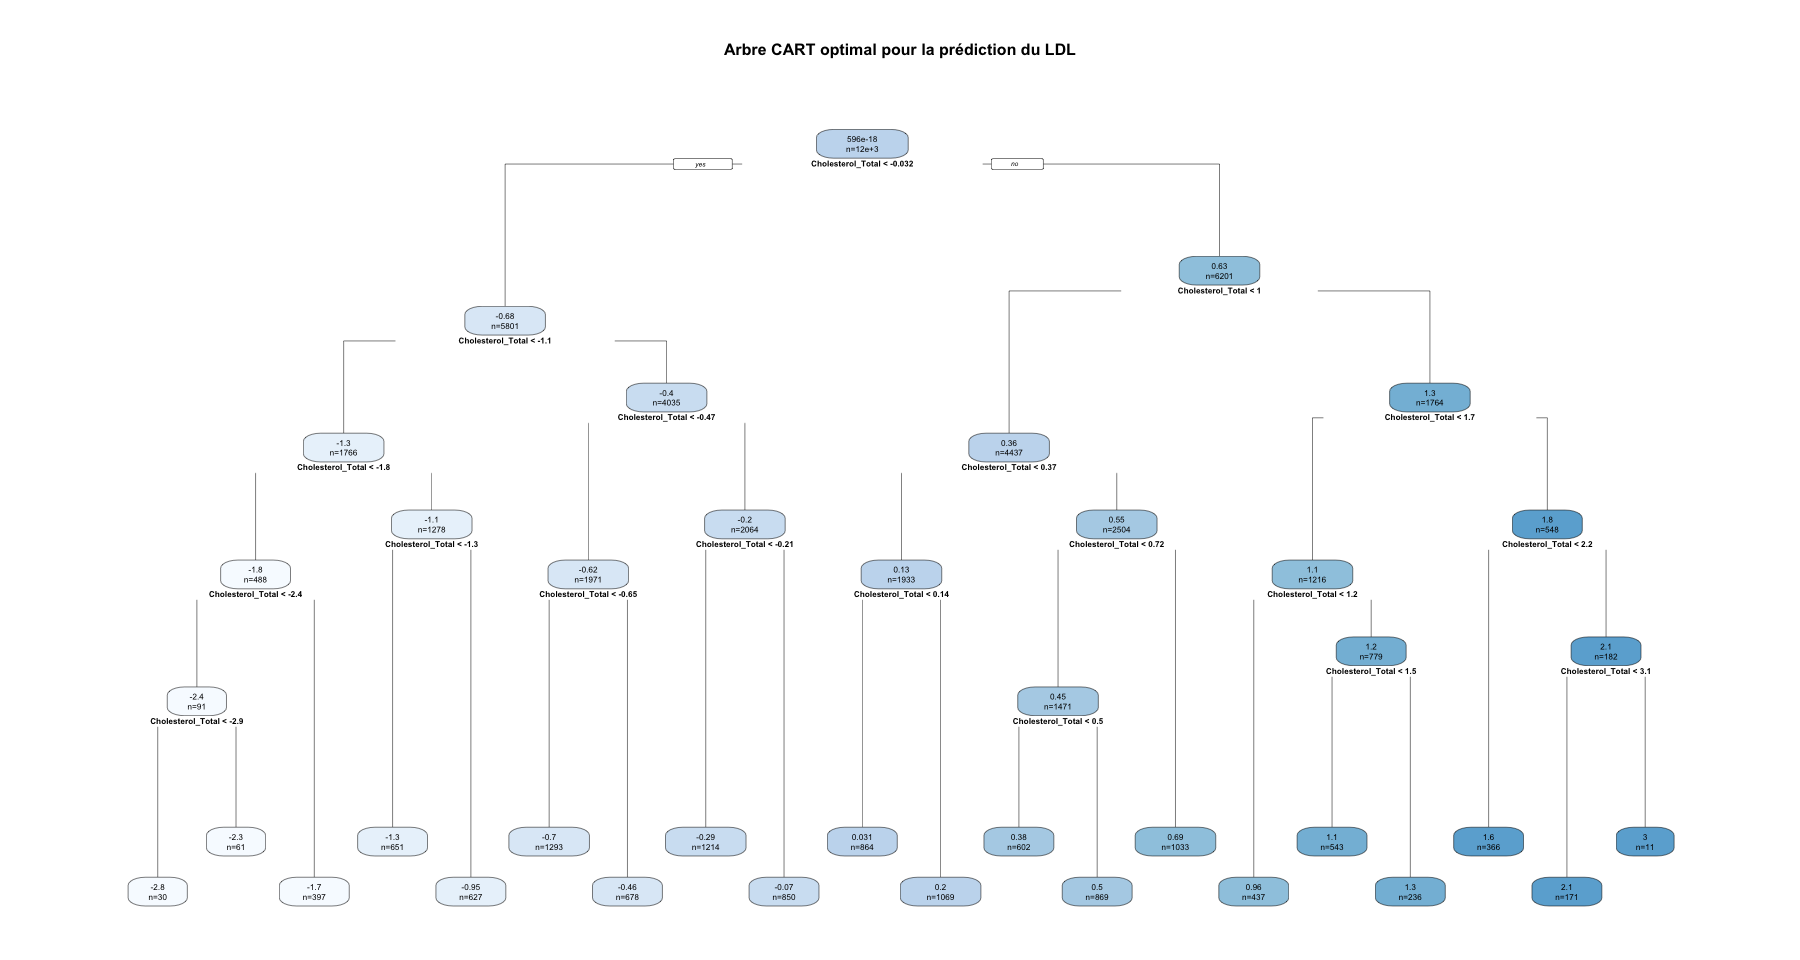

In [24]:
options(repr.plot.width = 15, repr.plot.height = 8)
rpart.plot(tree.cart$finalModel, type = 2, extra = 1, fallen.leaves = TRUE,
           main = "Arbre CART optimal pour la prédiction du LDL")

Cet arbre le démontre de façon spectaculaire : absolument tous les nœuds de décision s'appuient sur l'unique variable Cholesterol_Total. L'algorithme CART tente simplement de recréer la forte relation linéaire sous-jacente en découpant cette variable en une multitude de petits paliers, ignorant totalement le reste des données cliniques.

In [25]:
pred.cart = predict(tree.cart, newdata = dataTest_ldl)
mse.cart = mean((y_test_ldl - pred.cart)^2)
mae.cart = mean(abs(y_test_ldl - pred.cart))
r2.cart  = 1 - sum((y_test_ldl - pred.cart)^2) / sum((y_test_ldl - mean(y_test_ldl))^2)
paste("CART | MSE =", round(mse.cart,2), "| MAE =", round(mae.cart,2), "| R² =", round(r2.cart,4))

[1] "CART | MSE = 0.31 | MAE = 0.44 | R² = 0.6922"

Les performances de l'arbre CART sont quasiment identiques à celles du Lasso et du SVR (R^2≈69 %). Cela confirme qu'un modèle basé sur des paliers de décisions n'est pas plus efficace qu'une simple droite de régression linéaire pour ce jeu de données.

## 5.7 Forêt aléatoire (Random Forest)

La forêt aléatoire agrège un grand nombre d'arbres construits sur des échantillons bootstrap, avec en plus une sélection aléatoire de variables à chaque nœud. Ces deux sources d'aléatoire réduisent la variance par rapport à un seul arbre tout en conservant un faible biais. Les hyperparamètres clés sont `mtry` (nombre de variables tirées à chaque nœud) et `ntree` (nombre d'arbres).

In [27]:
set.seed(123)

idx_sample_rf <- sample(1:nrow(dataTrain_ldl), 3000)
dataTrain_sample_rf <- dataTrain_ldl[idx_sample_rf, ]

p_ldl = ncol(dataTrain_ldl) - 1
mtry_grid = c(floor(p_ldl/3), floor(p_ldl/2), floor(sqrt(p_ldl)))

rf.tune = train(Cholesterol_LDL ~ ., data = dataTrain_sample_rf, method = "rf",
                tuneGrid = expand.grid(mtry = mtry_grid),
                trControl = trainControl(method = "cv", number = 5),
                ntree = 200, metric = "RMSE")

print(rf.tune$bestTune)

rf.best = randomForest(Cholesterol_LDL ~ ., data = dataTrain_ldl,
                       mtry = rf.tune$bestTune$mtry, ntree = 500, importance = TRUE)

  mtry
3    8


In [28]:
pred.rf = predict(rf.best, newdata = dataTest_ldl)
mse.rf = mean((y_test_ldl - pred.rf)^2)
mae.rf = mean(abs(y_test_ldl - pred.rf))
r2.rf  = 1 - sum((y_test_ldl - pred.rf)^2) / sum((y_test_ldl - mean(y_test_ldl))^2)
paste("Random Forest | MSE =", round(mse.rf,2), "| MAE =", round(mae.rf,2), "| R² =", round(r2.rf,4))

[1] "Random Forest | MSE = 0.31 | MAE = 0.45 | R² = 0.684"

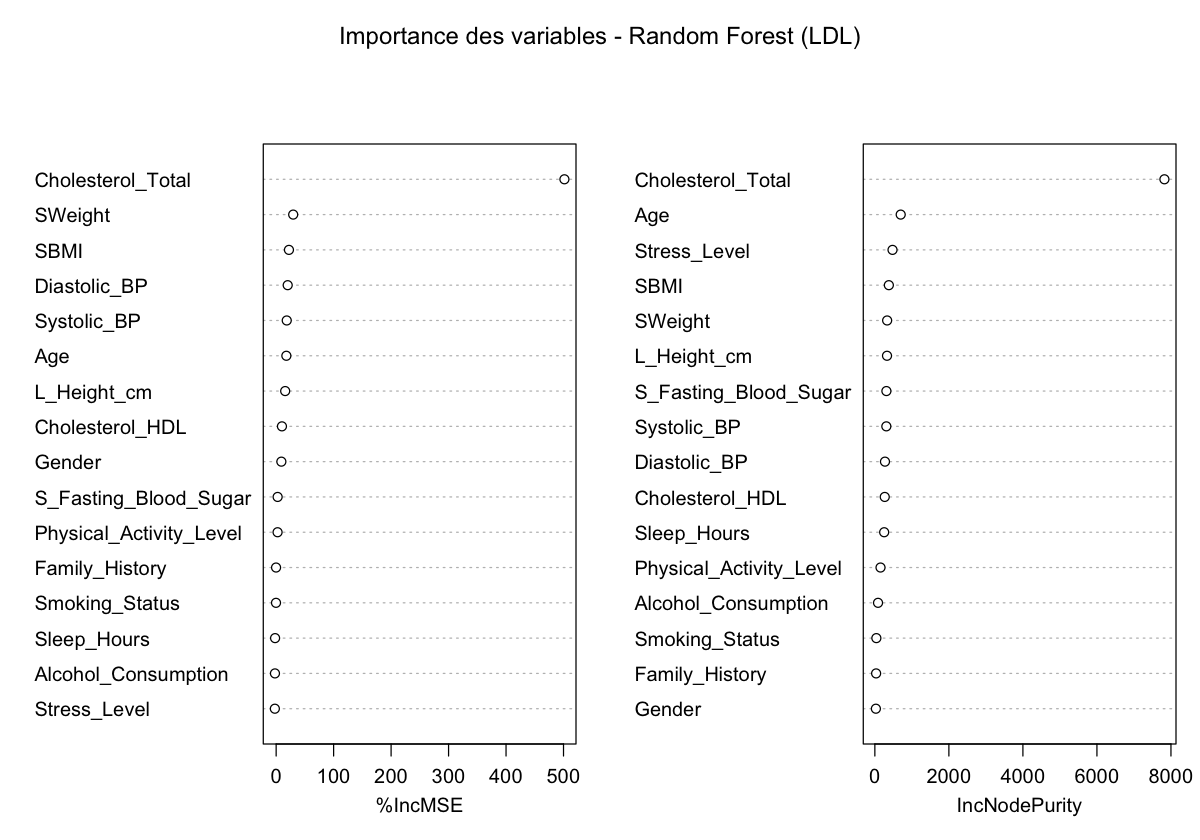

In [29]:
# Importance des variables
options(repr.plot.width = 10, repr.plot.height = 7)
varImpPlot(rf.best, main = "Importance des variables - Random Forest (LDL)")

Le Random Forest affiche des performances (R^2≈0,68, MSE = 0,31) équivalentes au modèle Lasso, démontrant qu'aucune plus-value n'est apportée par la complexité de l'algorithme. L'importance des variables confirme une domination totale de Cholesterol_Total, masquant les autres facteurs cliniques et rendant les modèles ensemblistes superflus au regard de la simplicité et de l'interprétabilité du modèle linéaire.

## 5.8 Gradient Boosting

Le Gradient Boosting construit séquentiellement des arbres en se concentrant à chaque étape sur les résidus du modèle précédent. Comme pour la classification, on règle ici principalement le **learning rate** ($\nu$, contrôle de la vitesse d'apprentissage), la **profondeur** des arbres, et le **nombre d'itérations** (déterminé automatiquement par validation croisée pour éviter le surapprentissage).

[1] "Nombre optimal d'arbres : 204"

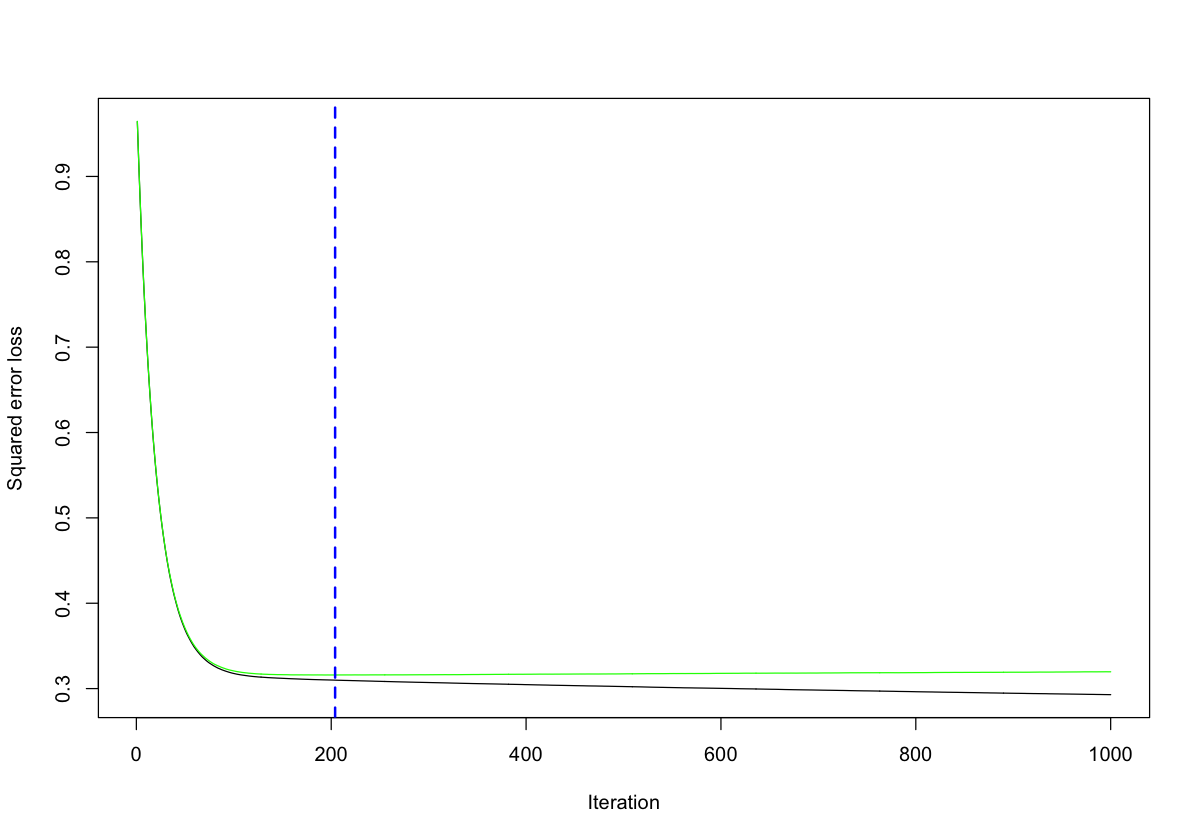

In [30]:
set.seed(123)
boost.ldl = gbm(Cholesterol_LDL ~ ., data = dataTrain_ldl,
                distribution = "gaussian",
                n.trees = 1000,
                interaction.depth = 3,
                shrinkage = 0.03,
                cv.folds = 5,
                n.minobsinnode = 10,
                verbose = FALSE)

best.iter.ldl = gbm.perf(boost.ldl, method = "cv")
paste("Nombre optimal d'arbres :", best.iter.ldl)

Le graphique montre l'évolution de l'erreur quadratique lors de l'entraînement du modèle de Gradient Boosting (Boosting) :
- La courbe noire représente l'erreur sur le jeu d'entraînement, qui décroît continuellement.
- La courbe verte représente l'erreur en validation croisée, qui stagne après l'itération optimale située à 204 arbres (ligne bleue pointillée).

Au-delà de ce point, le modèle commence à surapprendre (overfitting), ce qui justifie l'arrêt à 204 itérations pour garantir une meilleure généralisation.

In [31]:
pred.boost = predict(boost.ldl, newdata = dataTest_ldl, n.trees = best.iter.ldl)
mse.boost = mean((y_test_ldl - pred.boost)^2)
mae.boost = mean(abs(y_test_ldl - pred.boost))
r2.boost  = 1 - sum((y_test_ldl - pred.boost)^2) / sum((y_test_ldl - mean(y_test_ldl))^2)
paste("Gradient Boosting | MSE =", round(mse.boost,2), "| MAE =", round(mae.boost,2), "| R² =", round(r2.boost,4))

[1] "Gradient Boosting | MSE = 0.3 | MAE = 0.44 | R² = 0.6936"

,var,rel.inf
,<chr>,<dbl>
Cholesterol_Total,Cholesterol_Total,99.251204486
Stress_Level,Stress_Level,0.173944920
Age,Age,0.120515046
SWeight,SWeight,0.100345660
L_Height_cm,L_Height_cm,0.084692600
SBMI,SBMI,0.055040177
Systolic_BP,Systolic_BP,0.054599588
Cholesterol_HDL,Cholesterol_HDL,0.050409394
S_Fasting_Blood_Sugar,S_Fasting_Blood_Sugar,0.042716415


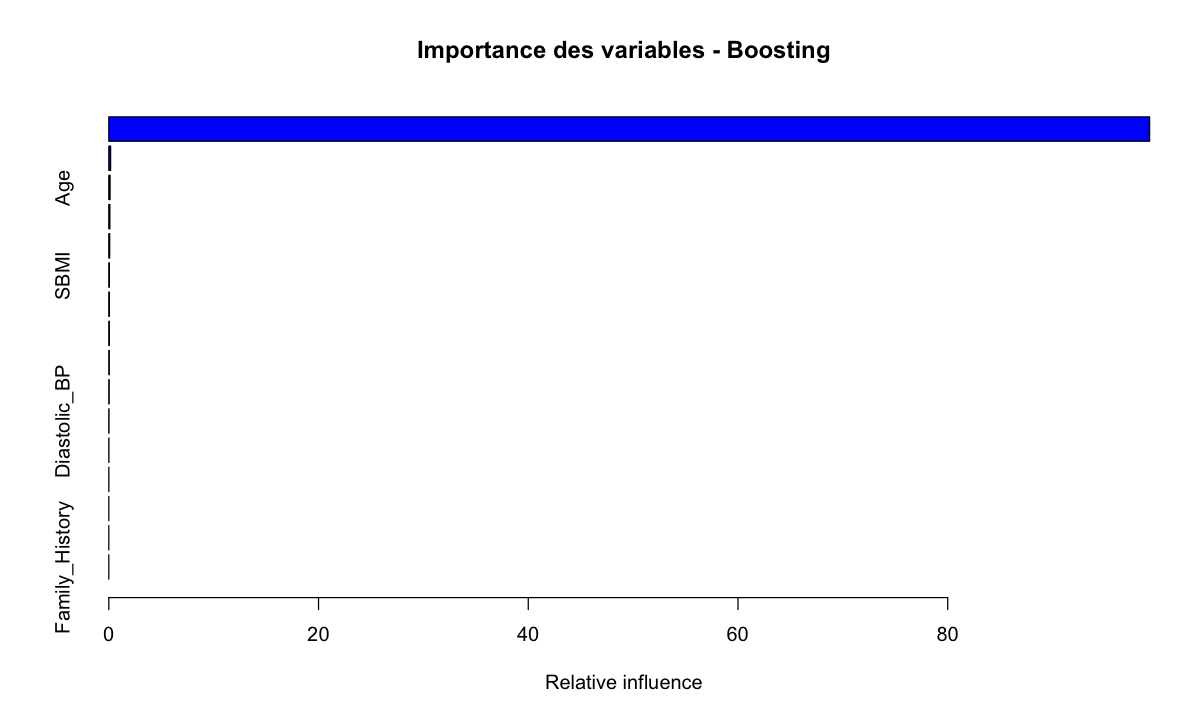

In [32]:
# Importance des variables (Gradient Boosting)
options(repr.plot.width = 10, repr.plot.height = 6)
summary(boost.ldl, n.trees = best.iter.ldl, main = "Importance des variables - Boosting")

Le Gradient Boosting affiche des performances (R^2≈0,69) strictement identiques aux modèles précédents, confirmant l'absence de gain lié à la complexité algorithmique. L'analyse d'importance est sans appel : Cholesterol_Total capte 99,25 % du pouvoir prédictif, reléguant toutes les autres variables à une influence marginale. Ce résultat clôt définitivement la démonstration qu'aucun modèle complexe ne surpasse l'approche linéaire simple sur ce jeu de données.

Ce graphique montre que la variable Cholesterol_Total représente quasiment la totalité (plus de 99 %) de l'importance prédictive dans le modèle de Gradient Boosting. Toutes les autres variables ont une influence négligeable, confirmant que le taux de LDL est ici quasi exclusivement déterminé par le cholestérol total, rendant les autres paramètres cliniques superflus pour la prédiction.

## 5.9 Réseau de neurones (MLP)

Pour finir, nous implémentons un perceptron multicouche (MLP) — un réseau de neurones simple à une seule couche cachée. Cette architecture est entraînée par rétropropagation du gradient. L'hyperparamètre principal à régler est la taille de la couche cachée.

In [33]:
set.seed(123)

idx_sample_nnet = sample(1:nrow(dataTrain_ldl), 3000)
dataTrain_sample_nnet = dataTrain_ldl[idx_sample_nnet, ]

nnet.grid = expand.grid(size = c(3, 5, 7, 10), decay = c(0.001, 0.01, 0.1))

nnet.tune = train(Cholesterol_LDL ~ ., data = dataTrain_sample_nnet, method = "nnet",
                  tuneGrid = nnet.grid,
                  trControl = trainControl(method = "cv", number = 5),
                  linout = TRUE, trace = FALSE, maxit = 500, metric = "RMSE")

print(nnet.tune$bestTune)

nnet.best = train(Cholesterol_LDL ~ ., data = dataTrain_ldl, method = "nnet",
                  tuneGrid = nnet.tune$bestTune,
                  trControl = trainControl(method = "none"), # Pas besoin de CV ici
                  linout = TRUE, trace = FALSE, maxit = 500, metric = "RMSE")

pred.nnet = predict(nnet.best, newdata = dataTest_ldl)
mse.nnet = mean((y_test_ldl - pred.nnet)^2)
mae.nnet = mean(abs(y_test_ldl - pred.nnet))
r2.nnet  = 1 - sum((y_test_ldl - pred.nnet)^2) / sum((y_test_ldl - mean(y_test_ldl))^2)

paste("Réseau de neurones | MSE =", round(mse.nnet,2), "| MAE =", round(mae.nnet,2), "| R² =", round(r2.nnet,4))

  size decay
2    3  0.01


[1] "Réseau de neurones | MSE = 0.31 | MAE = 0.44 | R² = 0.6889"

Le réseau de neurones retient une architecture modeste avec 3 neurones dans la couche cachée et un taux de régularisation (decay) de 0,01.

Ses performances (R^2≈0,69, MSE = 0,31) sont en parfaite cohérence avec celles des modèles précédents. Cette stabilité confirme que la relation entre les variables et le taux de LDL est quasi-linéaire, rendant inutile la complexité supplémentaire d'un réseau de neurones pour ce problème spécifique.

Le réseau de neurones obtient des performances comparables aux autres modèles, sans amélioration notable. Sur ce jeu de données, la relation entre les prédicteurs et le LDL est suffisamment linéaire pour qu'un modèle non-linéaire complexe n'apporte pas d'avantage significatif.

## 5.10 Comparaison des modèles

Nous regroupons l'ensemble des performances obtenues sur l'échantillon test pour comparer les modèles selon trois métriques : MSE (erreur quadratique moyenne), MAE (erreur absolue moyenne) et R² (proportion de variance expliquée).

In [35]:
recap_ldl = data.frame(
    Modele = c("Lasso", "SVR linéaire", "SVR RBF", "CART", "Random Forest", "Gradient Boosting", "Réseau de neurones"),
    MSE = c(mse.lasso, mse.svr.lin, mse.svr.rbf, mse.cart, mse.rf, mse.boost, mse.nnet),
    MAE = c(mae.lasso, mae.svr.lin, mae.svr.rbf, mae.cart, mae.rf, mae.boost, mae.nnet),
    R2  = c(r2.lasso, r2.svr.lin, r2.svr.rbf, r2.cart, r2.rf, r2.boost, r2.nnet)
)
recap_ldl = recap_ldl[order(-recap_ldl$R2), ]
print(recap_ldl, row.names = FALSE)

             Modele       MSE       MAE        R2
              Lasso 0.3016619 0.4371225 0.6965313
       SVR linéaire 0.3039507 0.4390174 0.6942288
  Gradient Boosting 0.3046243 0.4397544 0.6935512
               CART 0.3060043 0.4397747 0.6921629
            SVR RBF 0.3066957 0.4416391 0.6914674
      Random Forest 0.3141531 0.4473437 0.6839653
 Réseau de neurones 0.3276277 0.4595591 0.6704100


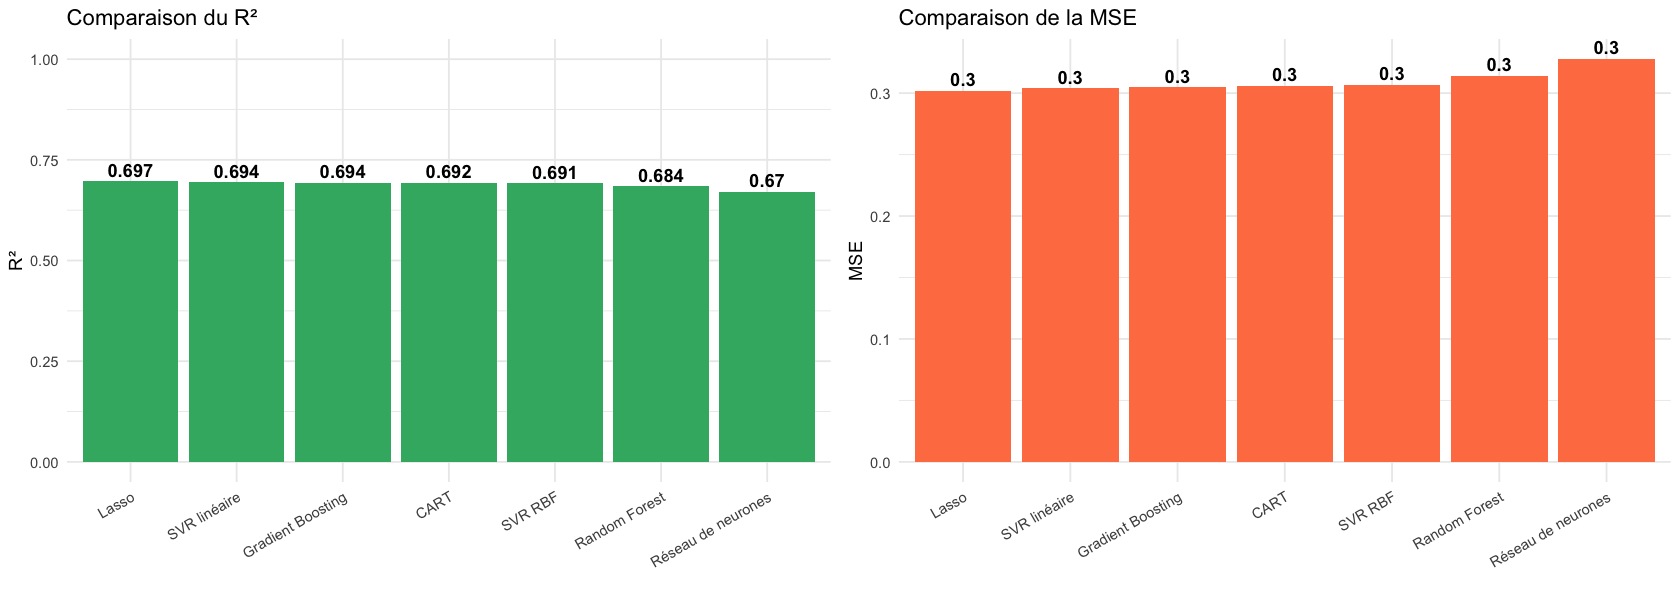

In [36]:
# Visualisation comparative R² et MSE
options(repr.plot.width = 14, repr.plot.height = 5)
recap_ldl$Modele = factor(recap_ldl$Modele, levels = recap_ldl$Modele[order(-recap_ldl$R2)])

g_r2 = ggplot(recap_ldl, aes(x = Modele, y = R2)) + 
    geom_bar(stat="identity", fill="mediumseagreen") + 
    geom_text(aes(label = round(R2, 3)), vjust = -0.4, fontface = "bold") + 
    ylim(0, 1) + 
    labs(title = "Comparaison du R²", x = "", y = "R²") + 
    theme_minimal() + theme(axis.text.x = element_text(angle = 30, hjust = 1))

recap_mse = recap_ldl[order(recap_ldl$MSE), ]
recap_mse$Modele = factor(recap_mse$Modele, levels = recap_mse$Modele)
g_mse = ggplot(recap_mse, aes(x = Modele, y = MSE)) + 
    geom_bar(stat="identity", fill="coral") + 
    geom_text(aes(label = round(MSE, 1)), vjust = -0.4, fontface = "bold") + 
    labs(title = "Comparaison de la MSE", x = "", y = "MSE") + 
    theme_minimal() + theme(axis.text.x = element_text(angle = 30, hjust = 1))

grid.arrange(g_r2, g_mse, ncol = 2)

Conclusion sur la modélisation du taux de LDL:

L'analyse comparative des différents modèles révèle une homogénéité des performances prédictives, avec un coefficient de détermination (R^2) oscillant entre 0,67 et 0,70 et une erreur quadratique moyenne (MSE) stabilisée autour de 0,30. Aucun modèle complexe ne parvient à surclasser les approches linéaires, ce qui indique que la relation entre les variables cliniques et le cholestérol LDL est fondamentalement linéaire.

L'analyse de l'importance des prédicteurs démontre que la variable Cholesterol_Total monopolise l'essentiel du pouvoir prédictif, reléguant les autres indicateurs à une influence marginale. Dans ce contexte, le modèle Lasso constitue l'approche optimale : il offre le meilleur compromis entre performance et interprétabilité, tout en assurant une sélection de variables pertinente. L'utilisation de modèles ensemblistes ou non-linéaires plus gourmands en ressources ne se justifie pas, leur complexité n'apportant aucune plus-value analytique sur ce jeu de données.